# 04. Nonlinear Modelling

## 1. Notebook Objective and Modelling Framework

Notebook 3 established the probabilistic baseline for the Premier League Probability Engine. The selected multinomial logistic-regression model demonstrated that the engineered pre-match features contain predictive information beyond naive outcome-frequency forecasts.

The purpose of this notebook is to test whether nonlinear models can improve those probability estimates by learning interactions and threshold effects that a linear decision boundary cannot represent directly.

The central research question is:

> Can nonlinear models exploit interactions within the engineered pre-match features while improving out-of-sample probability forecasts relative to the tuned logistic-regression baseline?

The prediction target remains:

$$
Y_i \in \{H,D,A\},
$$

where:

- $H$ represents a home win;
- $D$ represents a draw;
- $A$ represents an away win.

Every model must return a complete probability vector in the fixed project order:

$$
\widehat{\mathbf{p}}_i
=
\left(
\widehat{p}_{i,H},
\widehat{p}_{i,D},
\widehat{p}_{i,A}
\right),
$$

subject to:

$$
\widehat{p}_{i,H}
+
\widehat{p}_{i,D}
+
\widehat{p}_{i,A}
=
1.
$$

### Evaluation discipline

The chronological split from Notebook 3 will be reproduced exactly:

- training set: all seasons before the final two completed seasons;
- validation set: the second-most-recent completed season;
- test set: the most-recent completed season.

Model families and hyperparameters must be selected using validation performance only. The principal selection metric remains multiclass log loss, with Brier score and accuracy used as supporting diagnostics.

The tuned logistic-regression validation benchmark from Notebook 3 is:

| Metric | Validation result |
|---|---:|
| Log loss | 0.934551 |
| Brier score | 0.549322 |
| Accuracy | 0.592105 |

The nonlinear models must therefore improve probability quality rather than merely produce different predicted classes.

### Planned model sequence

This notebook will examine:

1. a Random Forest probability baseline;
2. a gradient-boosted tree model;
3. validation-based hyperparameter tuning;
4. feature-importance and error diagnostics;
5. final comparison with the tuned logistic-regression benchmark.

> **Run instruction:** select the project virtual environment as the kernel, then use **Restart Kernel and Run All Cells**. The transferred setup cells are designed to reproduce Notebook 3's data, split and benchmark framework exactly.

## 2. Load and Validate the Processed Modelling Dataset

The modelling dataset created in `02_feature_engineering.ipynb` will now be loaded from the project’s processed-data directory.

The preferred input is:

`data/processed/premier_league_model_data.parquet`

Parquet is used because it preserves numeric, nullable-integer and date-related data types more reliably than CSV. The CSV export will remain available as a fallback if the Parquet file cannot be loaded.

Before modelling begins, the dataset must be checked to confirm that:

- the file exists in the expected project directory;
- the dataset contains at least one fixture;
- column names are unique;
- exact duplicate rows are absent;
- the identifier columns are available;
- the target column is present;
- the target contains only `H`, `D` and `A`;
- fixture dates can be parsed successfully;
- rows remain chronologically ordered within each season;
- the exported dataset contains no infinite numeric values.

The notebook will locate the repository root dynamically rather than relying on the notebook’s current working directory. This prevents paths such as `notebooks/data/processed/` from being created accidentally when the notebook is executed from inside the `notebooks` directory.

At this stage, no rows will be removed and no predictors will be transformed. The objective is only to verify that the exported feature-engineering output can be treated as the fixed input for the modelling pipeline.

A successful validation will establish the following primary objects:

- `model_data`: the complete processed modelling dataset;
- `season_column`: the season identifier;
- `date_column`: the fixture date;
- `home_team_column`: the home-team identifier;
- `away_team_column`: the away-team identifier;
- `target_column`: the full-time match result.

These objects will be used throughout the remainder of the notebook.

In [1]:
# ============================================================
# 2. Load and Validate the Processed Modelling Dataset
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Locate the project root
# ------------------------------------------------------------

def find_project_root(start_path):
    """
    Find the nearest parent directory containing the Git repository.
    """
    start_path = Path(start_path).resolve()

    for directory in [start_path, *start_path.parents]:
        if (directory / ".git").exists():
            return directory

    raise FileNotFoundError(
        "Could not locate the project root containing the .git directory."
    )


project_root = find_project_root(Path.cwd())

processed_data_directory = (
    project_root
    / "data"
    / "processed"
)

parquet_path = (
    processed_data_directory
    / "premier_league_model_data.parquet"
)

csv_path = (
    processed_data_directory
    / "premier_league_model_data.csv"
)


# ------------------------------------------------------------
# Load the modelling dataset
# ------------------------------------------------------------

if parquet_path.exists():
    model_data = pd.read_parquet(parquet_path)
    loaded_file = parquet_path
    loaded_format = "Parquet"

elif csv_path.exists():
    model_data = pd.read_csv(csv_path)
    loaded_file = csv_path
    loaded_format = "CSV"

else:
    raise FileNotFoundError(
        "Could not find the processed modelling dataset.\n\n"
        f"Checked:\n- {parquet_path}\n- {csv_path}"
    )


# ------------------------------------------------------------
# Identify essential columns
# ------------------------------------------------------------

def find_first_existing_column(
    dataframe,
    candidates,
    label,
    required=True,
):
    """
    Return the first candidate column present in the DataFrame.
    """
    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate

    if required:
        raise KeyError(
            f"Could not identify the {label} column. "
            f"Checked: {candidates}"
        )

    return None


season_column = find_first_existing_column(
    model_data,
    ["Season", "season"],
    label="season",
)

date_column = find_first_existing_column(
    model_data,
    ["Date", "date", "MatchDate", "match_date"],
    label="fixture date",
)

home_team_column = find_first_existing_column(
    model_data,
    ["HomeTeam", "home_team", "Home"],
    label="home-team",
)

away_team_column = find_first_existing_column(
    model_data,
    ["AwayTeam", "away_team", "Away"],
    label="away-team",
)

target_column = find_first_existing_column(
    model_data,
    ["FTR", "Result", "result", "FullTimeResult"],
    label="target",
)


# ------------------------------------------------------------
# Basic structural validation
# ------------------------------------------------------------

assert len(model_data) > 0, (
    "The modelling dataset is empty."
)

assert model_data.columns.is_unique, (
    "The modelling dataset contains duplicate column names."
)

exact_duplicate_rows = int(
    model_data.duplicated().sum()
)

assert exact_duplicate_rows == 0, (
    f"{exact_duplicate_rows} exact duplicate rows were detected."
)


# ------------------------------------------------------------
# Parse and validate fixture dates
# ------------------------------------------------------------

model_data[date_column] = pd.to_datetime(
    model_data[date_column],
    errors="coerce",
    dayfirst=True,
)

assert model_data[date_column].notna().all(), (
    "At least one fixture date could not be parsed."
)


# ------------------------------------------------------------
# Validate fixture identifiers
# ------------------------------------------------------------

identifier_columns = [
    season_column,
    date_column,
    home_team_column,
    away_team_column,
]

assert model_data[identifier_columns].notna().all().all(), (
    "One or more fixture identifier columns contain missing values."
)

assert (
    model_data[home_team_column]
    != model_data[away_team_column]
).all(), "A fixture cannot contain the same home and away team."

duplicate_fixture_count = int(
    model_data.duplicated(
        subset=identifier_columns,
    ).sum()
)

assert duplicate_fixture_count == 0, (
    f"{duplicate_fixture_count} duplicate fixtures were detected."
)


# ------------------------------------------------------------
# Validate the target
# ------------------------------------------------------------

model_data[target_column] = (
    model_data[target_column]
    .astype("string")
    .str.strip()
    .str.upper()
)

valid_target_values = {"H", "D", "A"}

invalid_target_values = sorted(
    set(
        model_data[target_column]
        .dropna()
        .unique()
    )
    - valid_target_values
)

assert not invalid_target_values, (
    "The target contains invalid values: "
    f"{invalid_target_values}"
)

assert model_data[target_column].notna().all(), (
    "The target contains missing values."
)


# ------------------------------------------------------------
# Confirm chronological ordering within seasons
# ------------------------------------------------------------

chronology_check = (
    model_data
    .groupby(
        season_column,
        sort=False,
    )[date_column]
    .apply(lambda dates: dates.is_monotonic_increasing)
)

assert chronology_check.all(), (
    "Fixtures are not chronologically ordered within every season."
)


# ------------------------------------------------------------
# Check numeric columns for infinite values
# ------------------------------------------------------------

numeric_columns = model_data.select_dtypes(
    include=[np.number]
).columns.tolist()

infinite_value_counts = {
    column: int(
        np.isinf(
            pd.to_numeric(
                model_data[column],
                errors="coerce",
            ).astype(float)
        ).sum()
    )
    for column in numeric_columns
}

columns_with_infinite_values = {
    column: count
    for column, count in infinite_value_counts.items()
    if count > 0
}

assert not columns_with_infinite_values, (
    "Infinite values were detected: "
    f"{columns_with_infinite_values}"
)


# ------------------------------------------------------------
# Create compact validation summaries
# ------------------------------------------------------------

target_distribution = (
    model_data[target_column]
    .value_counts()
    .reindex(["H", "D", "A"])
    .rename_axis("Outcome")
    .reset_index(name="Fixtures")
)

target_distribution["Percentage"] = (
    100
    * target_distribution["Fixtures"]
    / len(model_data)
).round(2)

dataset_summary = pd.DataFrame(
    {
        "Metric": [
            "Fixtures",
            "Columns",
            "Seasons",
            "Earliest fixture",
            "Latest fixture",
            "Numeric columns",
            "Columns with missing values",
        ],
        "Value": [
            f"{len(model_data):,}",
            len(model_data.columns),
            model_data[season_column].nunique(),
            model_data[date_column].min().date(),
            model_data[date_column].max().date(),
            len(numeric_columns),
            int(model_data.isna().any().sum()),
        ],
    }
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("Processed modelling dataset loaded successfully.")
print(f"Format: {loaded_format}")
print(f"File: {loaded_file}")
print(f"Shape: {model_data.shape}")
print(f"Target column: {target_column}")

display(dataset_summary)
display(target_distribution)
display(model_data.head(10))

Processed modelling dataset loaded successfully.
Format: Parquet
File: C:\Users\kiera\OneDrive\Desktop\premier-league-probability-engine\data\processed\premier_league_model_data.parquet
Shape: (3800, 75)
Target column: FTR


,Metric,Value
0,Fixtures,"3,800"
1,Columns,75
2,Seasons,10
3,Earliest fixture,2015-08-08
4,Latest fixture,2025-05-25
5,Numeric columns,70
6,Columns with missing values,47


,Outcome,Fixtures,Percentage
0,H,1691,44.5
1,D,886,23.32
2,A,1223,32.18


,Season,Date,HomeTeam,AwayTeam,FTR,HomeEloBefore,AwayEloBefore,HomeRollingPoints5,AwayRollingPoints5,HomeRollingGoalsFor5,...,PositionDifference,GoalDifferenceDifference,HomeTop4Before,HomeTop6Before,HomeTopHalfBefore,HomeBottom3Before,AwayTop4Before,AwayTop6Before,AwayTopHalfBefore,AwayBottom3Before
0,2015-16,2015-08-08,Bournemouth,Aston Villa,A,1500.0,1500.0,NaN,NaN,NaN,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2015-16,2015-08-08,Chelsea,Swansea,D,1500.0,1500.0,NaN,NaN,NaN,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2015-16,2015-08-08,Everton,Watford,D,1500.0,1500.0,NaN,NaN,NaN,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,2015-16,2015-08-08,Leicester,Sunderland,H,1500.0,1500.0,NaN,NaN,NaN,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2015-16,2015-08-08,Man United,Tottenham,H,1500.0,1500.0,NaN,NaN,NaN,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
5,2015-16,2015-08-08,Norwich,Crystal Palace,A,1500.0,1500.0,NaN,NaN,NaN,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
6,2015-16,2015-08-09,Arsenal,West Ham,A,1500.0,1500.0,NaN,NaN,NaN,...,7,0,0,0,1,0,0,0,0,0
7,2015-16,2015-08-09,Newcastle,Southampton,D,1500.0,1500.0,NaN,NaN,NaN,...,1,0,0,0,0,0,0,0,0,0
8,2015-16,2015-08-09,Stoke,Liverpool,A,1500.0,1500.0,NaN,NaN,NaN,...,-4,0,0,0,0,0,0,0,1,0
9,2015-16,2015-08-10,West Brom,Man City,A,1500.0,1500.0,NaN,NaN,NaN,...,-1,0,0,0,0,0,0,0,0,0


### Results and Interpretation

The processed modelling dataset loaded successfully from the project-level `data/processed` directory.

The validation confirms that:

- the dataset contains fixtures and modelling variables;
- all column names are unique;
- no exact duplicate rows are present;
- fixture identifiers are complete;
- no fixture contains the same home and away team;
- the target column contains only `H`, `D` and `A`;
- fixture dates were parsed successfully;
- fixtures remain chronologically ordered within each season;
- no numeric column contains infinite values.

The target distribution provides the first indication of class imbalance in Premier League outcomes.

Home wins are generally the most common result, reflecting the historical home advantage. Draws and away wins occur less frequently, meaning that accuracy alone would be an incomplete measure of model quality.

A model could achieve a superficially reasonable accuracy by predicting the most common outcome too often while still producing poor probabilities for draws and away wins. For this reason, later evaluation will prioritise multiclass log loss and Brier score.

The successfully loaded `model_data` DataFrame now represents the fixed input for the baseline-modelling pipeline.

No rows have been removed and no feature transformations have yet been applied.

## 3. Define Identifiers, Target and Predictor Columns

Before constructing the training, validation and test sets, the columns in `model_data` must be separated according to their modelling role.

The dataset contains three distinct groups:

1. fixture identifiers;
2. the prediction target;
3. eligible pre-match predictors.

### Fixture Identifiers

The identifier columns describe each match and are retained for chronological splitting, interpretation and prediction output:

- `Season`
- `Date`
- `HomeTeam`
- `AwayTeam`

These columns will not be passed directly into the baseline logistic-regression model.

`Season` and `Date` are required to preserve the temporal structure of the dataset. The team-name columns identify each fixture but are excluded from the initial baseline because representing team identity directly would require an additional categorical-encoding strategy.

Team strength is already represented through quantitative pre-match variables such as Elo ratings, rolling form and league-table state.

### Target Variable

The prediction target is the full-time result:

`FTR`

with possible values:

$$
Y_i \in \{H,D,A\}.
$$

The classes represent:

- `H`: home win;
- `D`: draw;
- `A`: away win.

For consistent probability output, the class order used throughout the project will be:

$$
(H,D,A).
$$

Maintaining a fixed class order is essential because each predicted-probability column must always correspond to the same outcome.

### Predictor Variables

The predictor set consists of the remaining eligible numeric columns in the processed modelling dataset.

These variables describe information available before kickoff, including:

- pre-match Elo ratings;
- general rolling form;
- venue-specific rolling form;
- rest and fixture congestion;
- relative home–away differences;
- season progress;
- reconstructed pre-match league-table state;
- league-position category indicators.

The predictor matrix will be denoted by:

$$
X \in \mathbb{R}^{N \times P},
$$

where:

- $N$ is the number of fixtures;
- $P$ is the number of predictor variables.

The target vector will be denoted by:

$$
\mathbf{y}
=
(y_1,\ldots,y_N).
$$

### Leakage Protection

The predictor set must not contain:

- `FTR`;
- full-time or half-time goals;
- match statistics recorded during the fixture;
- final-season information;
- bookmaker probabilities or odds;
- temporary feature-engineering columns.

The processed dataset was designed to exclude these variables, but this notebook will validate the separation again before modelling.

### Missing Values

Some predictors contain intentional missing values.

For example, league position and league-position category indicators are undefined before the first completed fixture batch of each season.

Later preprocessing will impute missing numeric values using statistics learned from the training set only.

No imputation, scaling or other transformation will be fitted before the chronological split. This prevents information from the validation or test periods from influencing the training pipeline.

This section will create the following objects:

- `identifier_columns`
- `target_column`
- `feature_columns`
- `X`
- `y`

It will also produce a feature summary confirming the number, data type and missingness of the available predictors.

In [2]:
# ============================================================
# 3. Define Identifiers, Target and Predictor Columns
# ============================================================

# ------------------------------------------------------------
# Define identifier and target columns
# ------------------------------------------------------------

identifier_columns = [
    season_column,
    date_column,
    home_team_column,
    away_team_column,
]

class_order = ["H", "D", "A"]


# ------------------------------------------------------------
# Identify eligible numeric predictor columns
# ------------------------------------------------------------

excluded_columns = set(
    identifier_columns
    + [target_column]
)

feature_columns = [
    column
    for column in model_data.columns
    if (
        column not in excluded_columns
        and pd.api.types.is_numeric_dtype(model_data[column])
    )
]


# ------------------------------------------------------------
# Validate that predictors have been identified
# ------------------------------------------------------------

assert feature_columns, (
    "No numeric predictor columns were identified."
)

assert len(feature_columns) == len(set(feature_columns)), (
    "The predictor list contains duplicate column names."
)

assert target_column not in feature_columns, (
    "The target column has entered the predictor set."
)

assert not set(identifier_columns).intersection(feature_columns), (
    "One or more identifier columns entered the predictor set."
)


# ------------------------------------------------------------
# Check for obvious leakage columns
# ------------------------------------------------------------

blocked_exact_names = {
    "FTHG",
    "FTAG",
    "FTR",
    "HTHG",
    "HTAG",
    "HTR",
    "HS",
    "AS",
    "HST",
    "AST",
    "HF",
    "AF",
    "HC",
    "AC",
    "HY",
    "AY",
    "HR",
    "AR",
    "HomeGoals",
    "AwayGoals",
    "HomeScore",
    "AwayScore",
    "FullTimeResult",
}

blocked_name_fragments = [
    "bookmaker",
    "market_probability",
    "marketprob",
    "implied_probability",
    "impliedprob",
    "final_position",
    "finalposition",
]

blocked_predictors = [
    column
    for column in feature_columns
    if (
        column in blocked_exact_names
        or any(
            fragment in column.lower()
            for fragment in blocked_name_fragments
        )
    )
]

assert not blocked_predictors, (
    "Potential leakage columns were detected in the predictor set: "
    f"{blocked_predictors}"
)


# ------------------------------------------------------------
# Construct the predictor matrix and target vector
# ------------------------------------------------------------

X = model_data[feature_columns].copy()
y = model_data[target_column].copy()

fixture_metadata = model_data[
    identifier_columns
].copy()


# ------------------------------------------------------------
# Validate shapes and index alignment
# ------------------------------------------------------------

assert len(X) == len(model_data), (
    "The predictor matrix does not contain every fixture."
)

assert len(y) == len(model_data), (
    "The target vector does not contain every fixture."
)

assert X.index.equals(y.index), (
    "The predictor matrix and target vector are not aligned."
)

assert fixture_metadata.index.equals(X.index), (
    "Fixture metadata and predictors are not aligned."
)

assert X.columns.is_unique, (
    "The predictor matrix contains duplicate columns."
)


# ------------------------------------------------------------
# Validate target classes
# ------------------------------------------------------------

observed_classes = set(
    y.dropna().unique()
)

assert observed_classes == set(class_order), (
    "The observed target classes do not match H, D and A. "
    f"Observed classes: {sorted(observed_classes)}"
)


# ------------------------------------------------------------
# Validate predictor values
# ------------------------------------------------------------

non_numeric_predictors = [
    column
    for column in feature_columns
    if not pd.api.types.is_numeric_dtype(X[column])
]

assert not non_numeric_predictors, (
    "Non-numeric predictor columns were detected: "
    f"{non_numeric_predictors}"
)

infinite_predictor_counts = {}

for column in feature_columns:
    numeric_values = pd.to_numeric(
        X[column],
        errors="coerce",
    ).astype(float)

    infinite_predictor_counts[column] = int(
        np.isinf(numeric_values).sum()
    )

predictors_with_infinite_values = {
    column: count
    for column, count in infinite_predictor_counts.items()
    if count > 0
}

assert not predictors_with_infinite_values, (
    "Infinite values were detected in the predictors: "
    f"{predictors_with_infinite_values}"
)


# ------------------------------------------------------------
# Create the feature summary
# ------------------------------------------------------------

feature_summary = pd.DataFrame(
    {
        "Feature": feature_columns,
        "DataType": [
            str(X[column].dtype)
            for column in feature_columns
        ],
        "MissingValues": [
            int(X[column].isna().sum())
            for column in feature_columns
        ],
        "MissingPercentage": [
            round(
                100 * X[column].isna().mean(),
                2,
            )
            for column in feature_columns
        ],
        "UniqueValues": [
            int(X[column].nunique(dropna=True))
            for column in feature_columns
        ],
        "Minimum": [
            X[column].min(skipna=True)
            for column in feature_columns
        ],
        "Maximum": [
            X[column].max(skipna=True)
            for column in feature_columns
        ],
    }
)

features_with_missing_values = (
    feature_summary[
        feature_summary["MissingValues"] > 0
    ]
    .sort_values(
        by=[
            "MissingPercentage",
            "MissingValues",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("Identifiers, target and predictors defined successfully.")
print(f"Fixtures: {len(model_data):,}")
print(f"Identifier columns: {len(identifier_columns)}")
print(f"Target column: {target_column}")
print(f"Predictor columns: {len(feature_columns)}")
print(
    "Predictors containing missing values:",
    len(features_with_missing_values),
)
print(f"Class order: {class_order}")

display(feature_summary)

if not features_with_missing_values.empty:
    display(features_with_missing_values)

Identifiers, target and predictors defined successfully.
Fixtures: 3,800
Identifier columns: 4
Target column: FTR
Predictor columns: 70
Predictors containing missing values: 47
Class order: ['H', 'D', 'A']


,Feature,DataType,MissingValues,MissingPercentage,UniqueValues,Minimum,Maximum
0,HomeEloBefore,float64,0,0.00,3775,1321.589147,1852.597673
1,AwayEloBefore,float64,0,0.00,3776,1316.579895,1854.104860
2,HomeRollingPoints5,float64,502,13.21,15,0.000000,15.000000
3,AwayRollingPoints5,float64,498,13.11,15,0.000000,15.000000
4,HomeRollingGoalsFor5,float64,502,13.21,23,0.000000,24.000000
...,...,...,...,...,...,...,...
65,HomeBottom3Before,Int64,24,0.63,2,0.000000,1.000000
66,AwayTop4Before,Int64,24,0.63,2,0.000000,1.000000
67,AwayTop6Before,Int64,24,0.63,2,0.000000,1.000000
68,AwayTopHalfBefore,Int64,24,0.63,2,0.000000,1.000000


,Feature,DataType,MissingValues,MissingPercentage,UniqueValues,Minimum,Maximum
0,VenuePointsFormDifference5,float64,1016,26.74,30,-14.0,15.0
1,VenueGoalsForFormDifference5,float64,1016,26.74,35,-15.0,20.0
2,VenueGoalsAgainstFormDifference5,float64,1016,26.74,33,-16.0,17.0
3,VenueGoalDifferenceFormDifference5,float64,1016,26.74,50,-24.0,28.0
4,VenueWinRateFormDifference5,float64,1016,26.74,19,-1.0,1.0
5,HomeVenueRollingPoints5,float64,1000,26.32,15,0.0,15.0
6,HomeVenueRollingGoalsFor5,float64,1000,26.32,24,0.0,24.0
7,HomeVenueRollingGoalsAgainst5,float64,1000,26.32,23,0.0,22.0
8,HomeVenueRollingGoalDifference5,float64,1000,26.32,39,-21.0,20.0
9,HomeVenueRollingWinRate5,float64,1000,26.32,6,0.0,1.0


### Results and Interpretation

The modelling columns have now been separated into fixture identifiers, the prediction target and eligible numeric predictors.

The identifier columns are:

- `Season`
- `Date`
- `HomeTeam`
- `AwayTeam`

These variables are retained for chronological splitting, fixture tracking and interpretation, but they are not passed directly into the baseline logistic-regression model.

The target variable is:

- `FTR`

with the fixed class order:

$$
(H,D,A).
$$

This ordering will be preserved whenever predicted probabilities are stored or evaluated, ensuring that each probability column always corresponds to the correct match outcome.

The predictor matrix `X` contains the numeric pre-match variables created during feature engineering, while the target vector `y` contains the observed full-time results.

The validation confirms that:

- the target is not included among the predictors;
- no fixture identifier is included among the predictors;
- every predictor is numeric;
- no predictor contains infinite values;
- predictor names are unique;
- `X`, `y` and `fixture_metadata` contain the same fixtures in the same order;
- all three target classes are present;
- no obvious post-match, bookmaker or final-season variables entered the predictor set.

Some predictor columns contain missing values. These are expected for features that require previous match information or a meaningful pre-match league table.

Missing values have not yet been imputed. Imputation must be learned from the training set only after the chronological split, preventing information from the validation or test periods from influencing the preprocessing pipeline.

The objects now available for modelling are:

- `identifier_columns`
- `target_column`
- `feature_columns`
- `X`
- `y`
- `fixture_metadata`

The next stage is to divide the fixtures into chronological training, validation and test periods.

## 4. Chronological Train–Validation–Test Split

The modelling dataset must now be divided into separate training, validation and test periods.

Because football fixtures occur through time, the split must preserve chronology. A random split would allow the model to train on matches played after fixtures contained in the validation or test sets, producing an unrealistic estimate of future performance.

The split will therefore be performed using complete Premier League seasons.

### Split Design

The seasons will first be ordered according to the date of their earliest fixture.

The dataset will then be divided as follows:

- **training set:** all seasons except the two most recent;
- **validation set:** the second-most-recent season;
- **test set:** the most recent season.

With ten seasons of data, this corresponds to:

- eight seasons for training;
- one season for validation;
- one season for testing.

Let the ordered seasons be:

$$
S_1,S_2,\ldots,S_T.
$$

The training data are:

$$
\mathcal{D}_{\text{train}}
=
\bigcup_{t=1}^{T-2}\mathcal{D}_{S_t},
$$

the validation data are:

$$
\mathcal{D}_{\text{validation}}
=
\mathcal{D}_{S_{T-1}},
$$

and the test data are:

$$
\mathcal{D}_{\text{test}}
=
\mathcal{D}_{S_T}.
$$

### Role of Each Dataset

The training set will be used to:

- estimate preprocessing parameters;
- fit baseline models;
- learn model coefficients.

The validation set will be used to:

- compare modelling choices;
- select regularisation settings;
- assess whether a model improves on the naive benchmarks.

The test set must remain untouched during model development. It will provide the final estimate of performance on the most recent unseen season.

### Preprocessing Discipline

All data-dependent preprocessing must be fitted using the training set only.

This includes:

- missing-value imputation;
- feature scaling;
- any later feature selection;
- model fitting.

For example, if the median of feature $j$ is used for imputation, it must be calculated as:

$$
\widetilde{x}_{j,\text{train}}
=
\operatorname{median}
\left(
X_{\text{train},j}
\right),
$$

and then applied unchanged to the validation and test sets.

Calculating preprocessing statistics from the complete dataset would allow information from future seasons to influence the training process.

### Split Validation

The split will be checked to confirm that:

- every fixture belongs to exactly one dataset;
- no season appears in more than one dataset;
- all training fixtures occur before the validation season;
- all validation fixtures occur before the test season;
- the predictor and target indices remain aligned;
- each dataset contains all three outcome classes;
- the number of fixtures is preserved.

This section will create:

- `train_seasons`
- `validation_season`
- `test_season`
- `X_train`
- `X_validation`
- `X_test`
- `y_train`
- `y_validation`
- `y_test`
- corresponding fixture-metadata objects

The resulting split will remain fixed throughout the later modelling notebooks so that every candidate model is evaluated on the same chronological periods.

In [3]:
# ============================================================
# 4. Chronological Train–Validation–Test Split
# ============================================================

# ------------------------------------------------------------
# Order seasons by the date of their earliest fixture
# ------------------------------------------------------------

season_date_summary = (
    model_data
    .groupby(
        season_column,
        as_index=False,
    )
    .agg(
        SeasonStart=(date_column, "min"),
        SeasonEnd=(date_column, "max"),
        Fixtures=(date_column, "size"),
    )
    .sort_values(
        by="SeasonStart",
        kind="mergesort",
    )
    .reset_index(drop=True)
)

ordered_seasons = (
    season_date_summary[season_column]
    .tolist()
)

assert len(ordered_seasons) >= 3, (
    "At least three seasons are required for separate "
    "training, validation and test sets."
)


# ------------------------------------------------------------
# Define the fixed chronological split
# ------------------------------------------------------------

train_seasons = ordered_seasons[:-2]
validation_season = ordered_seasons[-2]
test_season = ordered_seasons[-1]

assert train_seasons, (
    "The training set must contain at least one season."
)

assert validation_season not in train_seasons, (
    "The validation season appears in the training seasons."
)

assert test_season not in train_seasons, (
    "The test season appears in the training seasons."
)

assert validation_season != test_season, (
    "The validation and test seasons must be different."
)


# ------------------------------------------------------------
# Create split masks
# ------------------------------------------------------------

train_mask = model_data[season_column].isin(
    train_seasons
)

validation_mask = (
    model_data[season_column] == validation_season
)

test_mask = (
    model_data[season_column] == test_season
)


# ------------------------------------------------------------
# Confirm that every fixture belongs to exactly one split
# ------------------------------------------------------------

split_membership_count = (
    train_mask.astype(int)
    + validation_mask.astype(int)
    + test_mask.astype(int)
)

assert (split_membership_count == 1).all(), (
    "Every fixture must belong to exactly one split."
)

assert int(train_mask.sum()) > 0, (
    "The training set is empty."
)

assert int(validation_mask.sum()) > 0, (
    "The validation set is empty."
)

assert int(test_mask.sum()) > 0, (
    "The test set is empty."
)

assert (
    int(train_mask.sum())
    + int(validation_mask.sum())
    + int(test_mask.sum())
    == len(model_data)
), "The split does not preserve every fixture."


# ------------------------------------------------------------
# Construct predictor, target and metadata splits
# ------------------------------------------------------------

X_train = X.loc[train_mask].copy()
X_validation = X.loc[validation_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_validation = y.loc[validation_mask].copy()
y_test = y.loc[test_mask].copy()

metadata_train = fixture_metadata.loc[
    train_mask
].copy()

metadata_validation = fixture_metadata.loc[
    validation_mask
].copy()

metadata_test = fixture_metadata.loc[
    test_mask
].copy()


# ------------------------------------------------------------
# Validate index alignment within each split
# ------------------------------------------------------------

for split_name, split_X, split_y, split_metadata in [
    (
        "training",
        X_train,
        y_train,
        metadata_train,
    ),
    (
        "validation",
        X_validation,
        y_validation,
        metadata_validation,
    ),
    (
        "test",
        X_test,
        y_test,
        metadata_test,
    ),
]:
    assert split_X.index.equals(split_y.index), (
        f"The {split_name} predictors and target are not aligned."
    )

    assert split_X.index.equals(split_metadata.index), (
        f"The {split_name} predictors and metadata are not aligned."
    )

    assert list(split_X.columns) == feature_columns, (
        f"The {split_name} predictor columns changed."
    )


# ------------------------------------------------------------
# Validate that seasons do not overlap across splits
# ------------------------------------------------------------

observed_train_seasons = set(
    metadata_train[season_column].unique()
)

observed_validation_seasons = set(
    metadata_validation[season_column].unique()
)

observed_test_seasons = set(
    metadata_test[season_column].unique()
)

assert observed_train_seasons == set(train_seasons), (
    "The observed training seasons do not match train_seasons."
)

assert observed_validation_seasons == {
    validation_season
}, "The validation set contains an unexpected season."

assert observed_test_seasons == {
    test_season
}, "The test set contains an unexpected season."

assert observed_train_seasons.isdisjoint(
    observed_validation_seasons
), "Training and validation seasons overlap."

assert observed_train_seasons.isdisjoint(
    observed_test_seasons
), "Training and test seasons overlap."

assert observed_validation_seasons.isdisjoint(
    observed_test_seasons
), "Validation and test seasons overlap."


# ------------------------------------------------------------
# Validate chronological separation
# ------------------------------------------------------------

training_end_date = metadata_train[
    date_column
].max()

validation_start_date = metadata_validation[
    date_column
].min()

validation_end_date = metadata_validation[
    date_column
].max()

test_start_date = metadata_test[
    date_column
].min()

assert training_end_date < validation_start_date, (
    "The training period does not end before validation begins."
)

assert validation_end_date < test_start_date, (
    "The validation period does not end before testing begins."
)

for split_name, split_metadata in [
    ("training", metadata_train),
    ("validation", metadata_validation),
    ("test", metadata_test),
]:
    assert split_metadata[date_column].is_monotonic_increasing, (
        f"The {split_name} fixtures are not chronologically ordered."
    )


# ------------------------------------------------------------
# Validate outcome classes in every split
# ------------------------------------------------------------

expected_classes = set(class_order)

for split_name, split_y in [
    ("training", y_train),
    ("validation", y_validation),
    ("test", y_test),
]:
    observed_split_classes = set(
        split_y.unique()
    )

    assert observed_split_classes == expected_classes, (
        f"The {split_name} set does not contain all target classes. "
        f"Observed: {sorted(observed_split_classes)}"
    )


# ------------------------------------------------------------
# Add a split label for later auditing
# ------------------------------------------------------------

split_labels = pd.Series(
    index=model_data.index,
    dtype="string",
    name="DatasetSplit",
)

split_labels.loc[train_mask] = "Train"
split_labels.loc[validation_mask] = "Validation"
split_labels.loc[test_mask] = "Test"

assert split_labels.notna().all(), (
    "At least one fixture has no dataset-split label."
)


# ------------------------------------------------------------
# Create split summary
# ------------------------------------------------------------

split_summary = pd.DataFrame(
    {
        "Split": [
            "Train",
            "Validation",
            "Test",
        ],
        "Seasons": [
            len(train_seasons),
            1,
            1,
        ],
        "SeasonRange": [
            (
                f"{train_seasons[0]} to "
                f"{train_seasons[-1]}"
            ),
            str(validation_season),
            str(test_season),
        ],
        "Fixtures": [
            len(X_train),
            len(X_validation),
            len(X_test),
        ],
        "Percentage": [
            round(
                100 * len(X_train) / len(model_data),
                2,
            ),
            round(
                100 * len(X_validation) / len(model_data),
                2,
            ),
            round(
                100 * len(X_test) / len(model_data),
                2,
            ),
        ],
        "StartDate": [
            metadata_train[date_column].min().date(),
            metadata_validation[date_column].min().date(),
            metadata_test[date_column].min().date(),
        ],
        "EndDate": [
            metadata_train[date_column].max().date(),
            metadata_validation[date_column].max().date(),
            metadata_test[date_column].max().date(),
        ],
    }
)


# ------------------------------------------------------------
# Create class-distribution summary by split
# ------------------------------------------------------------

class_distribution_by_split = pd.concat(
    [
        pd.DataFrame(
            {
                "Split": split_name,
                "Outcome": outcome,
                "Fixtures": int(
                    (split_y == outcome).sum()
                ),
                "Percentage": round(
                    100
                    * (split_y == outcome).mean(),
                    2,
                ),
            },
            index=[0],
        )
        for split_name, split_y in [
            ("Train", y_train),
            ("Validation", y_validation),
            ("Test", y_test),
        ]
        for outcome in class_order
    ],
    ignore_index=True,
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("Chronological data split completed successfully.")
print(f"Training seasons: {train_seasons}")
print(f"Validation season: {validation_season}")
print(f"Test season: {test_season}")
print(
    "Split sizes:",
    f"train={len(X_train):,},",
    f"validation={len(X_validation):,},",
    f"test={len(X_test):,}",
)

display(season_date_summary)
display(split_summary)
display(class_distribution_by_split)

Chronological data split completed successfully.
Training seasons: ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']
Validation season: 2023-24
Test season: 2024-25
Split sizes: train=3,040, validation=380, test=380


,Season,SeasonStart,SeasonEnd,Fixtures
0,2015-16,2015-08-08,2016-05-17,380
1,2016-17,2016-08-13,2017-05-21,380
2,2017-18,2017-08-11,2018-05-13,380
3,2018-19,2018-08-10,2019-05-12,380
4,2019-20,2019-08-09,2020-07-26,380
5,2020-21,2020-09-12,2021-05-23,380
6,2021-22,2021-08-13,2022-05-22,380
7,2022-23,2022-08-05,2023-05-28,380
8,2023-24,2023-08-11,2024-05-19,380
9,2024-25,2024-08-16,2025-05-25,380


,Split,Seasons,SeasonRange,Fixtures,Percentage,StartDate,EndDate
0,Train,8,2015-16 to 2022-23,3040,80.0,2015-08-08,2023-05-28
1,Validation,1,2023-24,380,10.0,2023-08-11,2024-05-19
2,Test,1,2024-25,380,10.0,2024-08-16,2025-05-25


,Split,Outcome,Fixtures,Percentage
0,Train,H,1361,44.77
1,Train,D,711,23.39
2,Train,A,968,31.84
3,Validation,H,175,46.05
4,Validation,D,82,21.58
5,Validation,A,123,32.37
6,Test,H,155,40.79
7,Test,D,93,24.47
8,Test,A,132,34.74


### Results and Interpretation

The chronological train–validation–test split has been completed successfully.

The seasons were ordered using the date of each season’s earliest fixture and then divided into three non-overlapping periods:

- the earliest seasons form the training set;
- the second-most-recent season forms the validation set;
- the most recent season forms the test set.

This design reflects the way the model will be used in practice: information from earlier fixtures is used to predict matches played later in time.

The validation confirms that:

- every fixture belongs to exactly one split;
- no season appears in more than one split;
- the training period ends before the validation period begins;
- the validation period ends before the test period begins;
- predictor, target and metadata indices remain aligned;
- every predictor set contains the same feature columns;
- all three outcomes, `H`, `D` and `A`, appear in every split;
- the total number of fixtures has been preserved;
- fixtures remain chronologically ordered within each split.

The training set will be used to fit preprocessing transformations and estimate model parameters.

The validation set will be used to compare modelling decisions and assess whether a candidate model improves on the initial benchmarks.

The test set will remain untouched during model development. Its purpose is to provide a final estimate of performance on the most recent unseen season.

This separation is especially important for probability modelling. Repeatedly evaluating modelling choices on the test season would gradually leak information about that season into the development process, even if the model were never directly trained on its fixtures.

No imputation or scaling has yet been applied. These transformations will be fitted using `X_train` only and then applied unchanged to `X_validation` and `X_test`.

The fixed chronological split created in this section will be reused throughout the remaining modelling notebooks so that every model is compared using the same historical periods.

## 5. Target Distribution and Class Balance

Before constructing the first probability baselines, the distribution of match outcomes must be examined across the training, validation and test sets.

The target variable contains three possible outcomes:

$$
Y_i \in \{H,D,A\},
$$

where:

- `H` represents a home win;
- `D` represents a draw;
- `A` represents an away win.

Football match outcomes are not evenly distributed. Home wins are typically more common than draws or away wins because of the historical home advantage.

For dataset split $s$ and outcome class $k$, the observed class proportion is:

$$
\widehat{\pi}_{s,k}
=
\frac{N_{s,k}}{N_s},
$$

where:

- $N_{s,k}$ is the number of fixtures in split $s$ with outcome $k$;
- $N_s$ is the total number of fixtures in split $s$.

The class proportions will be calculated separately for:

- the training set;
- the validation set;
- the test set.

### Why Class Balance Matters

Class balance affects both modelling and evaluation.

A model that predicts the most common outcome too frequently may achieve a superficially reasonable accuracy while producing poor probability estimates for draws and away wins.

For example, predicting a home win for every fixture could outperform random classification on accuracy, but it would provide no meaningful assessment of uncertainty.

For this reason, accuracy will remain a secondary metric. The primary metrics will evaluate the complete predicted probability distribution.

### Distribution Shift

The outcome frequencies may change between seasons.

The validation and test sets may contain different proportions of home wins, draws and away wins from the training period because of:

- changes in home advantage;
- variation in team strength;
- unusual seasonal conditions;
- promoted and relegated teams;
- changes in playing style or league competitiveness.

These differences represent genuine temporal distribution shift and should not be corrected using information from future seasons.

### Historical-Frequency Baseline

The training-set outcome proportions will later define the historical-frequency baseline.

For outcome $k$:

$$
\widehat{p}_k
=
\frac{N_{\text{train},k}}
{N_{\text{train}}}.
$$

The same fixed training probabilities will then be assigned to every validation and test fixture.

It would be incorrect to calculate separate baseline probabilities using the validation or test outcomes because those results would not be known when the predictions were made.

### Section Objectives

This section will:

- count each outcome in every dataset split;
- calculate outcome percentages;
- compare class distributions across time;
- identify the majority class;
- quantify any change between training, validation and test periods;
- store the training-set class probabilities for later baseline forecasts.

The main objects created will be:

- `training_class_probabilities`
- `class_balance_summary`
- `class_balance_pivot`

These will provide the foundation for the naive probability benchmarks in the next section.

In [4]:
# ============================================================
# 5. Target Distribution and Class Balance
# ============================================================

# ------------------------------------------------------------
# Store the target vectors for each chronological split
# ------------------------------------------------------------

target_splits = {
    "Train": y_train,
    "Validation": y_validation,
    "Test": y_test,
}


# ------------------------------------------------------------
# Calculate outcome counts and proportions by split
# ------------------------------------------------------------

class_balance_records = []

for split_name, split_target in target_splits.items():

    outcome_counts = (
        split_target
        .value_counts()
        .reindex(
            class_order,
            fill_value=0,
        )
    )

    outcome_proportions = (
        outcome_counts / len(split_target)
    )

    for outcome in class_order:
        class_balance_records.append(
            {
                "Split": split_name,
                "Outcome": outcome,
                "Fixtures": int(
                    outcome_counts.loc[outcome]
                ),
                "Proportion": float(
                    outcome_proportions.loc[outcome]
                ),
                "Percentage": round(
                    100
                    * outcome_proportions.loc[outcome],
                    2,
                ),
            }
        )


class_balance_summary = pd.DataFrame(
    class_balance_records
)


# ------------------------------------------------------------
# Validate the class-balance summary
# ------------------------------------------------------------

assert len(class_balance_summary) == (
    len(target_splits) * len(class_order)
), (
    "The class-balance summary does not contain every "
    "split-outcome combination."
)

for split_name, split_target in target_splits.items():

    split_summary = class_balance_summary[
        class_balance_summary["Split"] == split_name
    ]

    assert set(
        split_summary["Outcome"]
    ) == set(class_order), (
        f"The {split_name} summary does not contain all outcomes."
    )

    assert (
        split_summary["Fixtures"].sum()
        == len(split_target)
    ), (
        f"The {split_name} outcome counts do not match "
        "the number of fixtures."
    )

    assert np.isclose(
        split_summary["Proportion"].sum(),
        1.0,
    ), (
        f"The {split_name} class proportions do not sum to 1."
    )


# ------------------------------------------------------------
# Store training-set probabilities for the later baseline
# ------------------------------------------------------------

training_class_probabilities = (
    y_train
    .value_counts(normalize=True)
    .reindex(class_order)
    .astype(float)
)

assert training_class_probabilities.notna().all(), (
    "At least one target class is missing from the "
    "training probabilities."
)

assert np.isclose(
    training_class_probabilities.sum(),
    1.0,
), "Training class probabilities do not sum to 1."

assert (
    training_class_probabilities >= 0
).all(), "Training class probabilities cannot be negative."

assert (
    training_class_probabilities <= 1
).all(), "Training class probabilities cannot exceed 1."


# ------------------------------------------------------------
# Identify the majority outcome in each split
# ------------------------------------------------------------

majority_class_records = []

for split_name, split_target in target_splits.items():

    split_probabilities = (
        split_target
        .value_counts(normalize=True)
        .reindex(class_order)
    )

    majority_outcome = (
        split_probabilities.idxmax()
    )

    majority_class_records.append(
        {
            "Split": split_name,
            "MajorityOutcome": majority_outcome,
            "MajorityProportion": float(
                split_probabilities.loc[
                    majority_outcome
                ]
            ),
            "MajorityPercentage": round(
                100
                * split_probabilities.loc[
                    majority_outcome
                ],
                2,
            ),
        }
    )


majority_class_summary = pd.DataFrame(
    majority_class_records
)


# ------------------------------------------------------------
# Create a comparison table of class percentages
# ------------------------------------------------------------

class_balance_pivot = (
    class_balance_summary
    .pivot(
        index="Outcome",
        columns="Split",
        values="Percentage",
    )
    .reindex(
        index=class_order,
        columns=[
            "Train",
            "Validation",
            "Test",
        ],
    )
    .reset_index()
)


# ------------------------------------------------------------
# Quantify distribution shift relative to training
# ------------------------------------------------------------

class_balance_shift = (
    class_balance_pivot
    .copy()
)

class_balance_shift[
    "ValidationMinusTrain"
] = (
    class_balance_shift["Validation"]
    - class_balance_shift["Train"]
)

class_balance_shift[
    "TestMinusTrain"
] = (
    class_balance_shift["Test"]
    - class_balance_shift["Train"]
)

class_balance_shift[
    "ValidationMinusTrain"
] = class_balance_shift[
    "ValidationMinusTrain"
].round(2)

class_balance_shift[
    "TestMinusTrain"
] = class_balance_shift[
    "TestMinusTrain"
].round(2)


# ------------------------------------------------------------
# Create a compact training-probability table
# ------------------------------------------------------------

training_probability_table = pd.DataFrame(
    {
        "Outcome": class_order,
        "Probability": [
            training_class_probabilities.loc[outcome]
            for outcome in class_order
        ],
        "Percentage": [
            round(
                100
                * training_class_probabilities.loc[outcome],
                2,
            )
            for outcome in class_order
        ],
    }
)


# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

assert (
    training_probability_table["Probability"] >= 0
).all(), "A baseline probability is negative."

assert (
    training_probability_table["Probability"] <= 1
).all(), "A baseline probability exceeds 1."

assert np.isclose(
    training_probability_table[
        "Probability"
    ].sum(),
    1.0,
), "The baseline probabilities do not sum to 1."


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("Target distribution analysis completed successfully.")
print(
    "Training-set majority outcome:",
    majority_class_summary.loc[
        majority_class_summary["Split"] == "Train",
        "MajorityOutcome",
    ].iloc[0],
)
print(
    "Training class probabilities:",
    {
        outcome: round(
            training_class_probabilities.loc[outcome],
            4,
        )
        for outcome in class_order
    },
)

display(class_balance_summary)

display(class_balance_pivot)

display(class_balance_shift)

display(majority_class_summary)

display(training_probability_table)

Target distribution analysis completed successfully.
Training-set majority outcome: H
Training class probabilities: {'H': np.float64(0.4477), 'D': np.float64(0.2339), 'A': np.float64(0.3184)}


,Split,Outcome,Fixtures,Proportion,Percentage
0,Train,H,1361,0.447697,44.77
1,Train,D,711,0.233882,23.39
2,Train,A,968,0.318421,31.84
3,Validation,H,175,0.460526,46.05
4,Validation,D,82,0.215789,21.58
5,Validation,A,123,0.323684,32.37
6,Test,H,155,0.407895,40.79
7,Test,D,93,0.244737,24.47
8,Test,A,132,0.347368,34.74


Split,Outcome,Train,Validation,Test
0,H,44.77,46.05,40.79
1,D,23.39,21.58,24.47
2,A,31.84,32.37,34.74


Split,Outcome,Train,Validation,Test,ValidationMinusTrain,TestMinusTrain
0,H,44.77,46.05,40.79,1.28,-3.98
1,D,23.39,21.58,24.47,-1.81,1.08
2,A,31.84,32.37,34.74,0.53,2.90


,Split,MajorityOutcome,MajorityProportion,MajorityPercentage
0,Train,H,0.447697,44.77
1,Validation,H,0.460526,46.05
2,Test,H,0.407895,40.79


,Outcome,Probability,Percentage
0,H,0.447697,44.77
1,D,0.233882,23.39
2,A,0.318421,31.84


### Results and Interpretation

The target-distribution analysis confirms that Premier League match outcomes are not evenly balanced across the three classes.

The training, validation and test sets each contain:

- home wins, represented by `H`;
- draws, represented by `D`;
- away wins, represented by `A`.

The `class_balance_summary` table reports the number and proportion of each outcome within every chronological split, while `class_balance_pivot` allows the percentages to be compared directly across time.

Home wins form the majority class in the training period. This reflects the historical home advantage present in Premier League football.

However, the class proportions are not identical across the training, validation and test seasons. The `class_balance_shift` table measures these changes in percentage points relative to the training set:

$$
\Delta_{s,k}
=
\widehat{\pi}_{s,k}
-
\widehat{\pi}_{\text{train},k},
$$

where $s$ represents either the validation or test set and $k$ represents one of the three outcomes.

These differences indicate genuine temporal distribution shift. The balance between home wins, draws and away wins varies from season to season because of changing teams, league competitiveness and broader football conditions.

The future models should not attempt to remove this shift using information from the validation or test outcomes. Instead, they must learn from the historical training period and be evaluated on how well they generalise to the later seasons.

The training-set class proportions have been stored in:

`training_class_probabilities`

These probabilities will form the historical-frequency benchmark in the next section.

For every future fixture, that benchmark will assign the same probability vector:

$$
\widehat{\mathbf{p}}_{\text{frequency}}
=
\left(
\widehat{p}_{H,\text{train}},
\widehat{p}_{D,\text{train}},
\widehat{p}_{A,\text{train}}
\right).
$$

Only the training outcomes are used to estimate these probabilities. The validation and test labels remain excluded from the forecasting process.

The majority-class percentages also demonstrate why accuracy alone is insufficient. A model that predicts the most common result for every fixture may achieve non-trivial accuracy, but it would fail to distinguish between matches and would provide poor probability estimates for less common outcomes.

The next section will construct and evaluate naive probability benchmarks using:

- uniform probabilities;
- training-set historical frequencies;
- majority-class predictions.

These benchmarks establish the minimum performance that the feature-based multinomial logistic-regression model must improve upon.

## 6. Naive Probability Benchmarks

Before fitting a feature-based model, several deliberately simple benchmarks must be evaluated.

These benchmarks provide reference levels for probability quality. A more complex model is only useful if it produces better out-of-sample forecasts than methods requiring little or no football information.

The benchmarks will be evaluated on both the validation and test sets using the same fixed chronological split established earlier.

### Uniform-Probability Baseline

The uniform baseline assigns equal probability to every possible outcome:

$$
\widehat{p}_H
=
\widehat{p}_D
=
\widehat{p}_A
=
\frac{1}{3}.
$$

Every fixture therefore receives the probability vector:

$$
\widehat{\mathbf{p}}_{\text{uniform}}
=
\left(
\frac{1}{3},
\frac{1}{3},
\frac{1}{3}
\right).
$$

This benchmark contains no information about football, home advantage, team strength or historical outcome frequencies.

Its purpose is to establish the performance of a completely uninformative probability forecast.

### Historical-Frequency Baseline

The historical-frequency baseline assigns probabilities using the outcome proportions observed in the training set.

For outcome class $k$:

$$
\widehat{p}_{k,\text{train}}
=
\frac{N_{k,\text{train}}}
{N_{\text{train}}},
$$

where:

- $N_{k,\text{train}}$ is the number of training fixtures with outcome $k$;
- $N_{\text{train}}$ is the total number of training fixtures.

Every validation and test fixture receives the same probability vector:

$$
\widehat{\mathbf{p}}_{\text{frequency}}
=
\left(
\widehat{p}_{H,\text{train}},
\widehat{p}_{D,\text{train}},
\widehat{p}_{A,\text{train}}
\right).
$$

This benchmark captures the unconditional historical home advantage and the long-run frequencies of draws and away wins.

It does not distinguish between individual fixtures.

Only training-set outcomes are used to estimate these probabilities. Recalculating them from the validation or test sets would use information that would not have been available when the predictions were made.

### Majority-Class Baseline

The majority-class benchmark predicts the most common training outcome as the most likely result for every fixture.

Let:

$$
k^*
=
\arg\max_{k \in \{H,D,A\}}
\widehat{p}_{k,\text{train}}.
$$

The predicted class is then:

$$
\widehat{Y}_i = k^*
$$

for every fixture $i$.

This benchmark is mainly useful for interpreting accuracy.

A majority-class classifier may achieve a non-trivial percentage of correct predictions despite making no distinction between fixtures. It is therefore not a meaningful probability model by itself.

For probability-based evaluation, the historical-frequency probabilities will be used rather than assigning probability one to the majority class and zero to the others. A deterministic probability vector would produce extremely large or undefined log loss whenever another outcome occurred.

### Evaluation Metrics

The uniform and historical-frequency probability forecasts will be evaluated using multiclass log loss:

$$
\operatorname{LogLoss}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\sum_{k \in \{H,D,A\}}
y_{i,k}
\log
\left(
\widehat{p}_{i,k}
\right).
$$

Lower values indicate better probability forecasts.

The multiclass Brier score will also be calculated:

$$
\operatorname{Brier}
=
\frac{1}{N}
\sum_{i=1}^{N}
\sum_{k \in \{H,D,A\}}
\left(
\widehat{p}_{i,k}
-
y_{i,k}
\right)^2.
$$

Lower Brier scores indicate that the predicted probability vector lies closer to the observed one-hot outcome vector.

Accuracy will be reported as a secondary metric:

$$
\operatorname{Accuracy}
=
\frac{1}{N}
\sum_{i=1}^{N}
\mathbb{1}
\left(
\widehat{Y}_i = Y_i
\right).
$$

### Benchmark Requirements

The implementation will confirm that:

- each probability is between zero and one;
- every probability row sums to one;
- probability columns follow the fixed order `(H, D, A)`;
- historical probabilities are estimated from `y_train` only;
- validation and test predictions contain the correct number of fixtures;
- no validation or test outcomes are used to construct the forecasts;
- all metrics are calculated consistently across benchmarks and splits.

This section will create:

- uniform validation and test probabilities;
- historical-frequency validation and test probabilities;
- majority-class validation and test predictions;
- a reusable multiclass Brier-score function;
- a benchmark-results table.

These results will establish the minimum standard that multinomial logistic regression must exceed.

In [5]:
# ============================================================
# 6. Naive Probability Benchmarks
# ============================================================

from sklearn.metrics import accuracy_score, log_loss


# ------------------------------------------------------------
# Reusable multiclass Brier-score function
# ------------------------------------------------------------

def multiclass_brier_score(
    y_true,
    probability_matrix,
    labels,
):
    """
    Calculate the multiclass Brier score.

    The score is the mean squared distance between each predicted
    probability vector and the observed one-hot outcome vector.
    """
    y_true = pd.Series(y_true).reset_index(drop=True)

    probabilities = np.asarray(
        probability_matrix,
        dtype=float,
    )

    assert probabilities.shape == (
        len(y_true),
        len(labels),
    ), (
        "The probability matrix has an unexpected shape. "
        f"Expected {(len(y_true), len(labels))}, "
        f"received {probabilities.shape}."
    )

    label_to_position = {
        label: position
        for position, label in enumerate(labels)
    }

    invalid_labels = sorted(
        set(y_true.unique()) - set(labels)
    )

    assert not invalid_labels, (
        "The target contains labels that are not included in "
        f"the supplied class order: {invalid_labels}"
    )

    observed_one_hot = np.zeros_like(
        probabilities,
        dtype=float,
    )

    observed_positions = (
        y_true
        .map(label_to_position)
        .to_numpy()
    )

    observed_one_hot[
        np.arange(len(y_true)),
        observed_positions,
    ] = 1.0

    return float(
        np.mean(
            np.sum(
                (
                    probabilities
                    - observed_one_hot
                ) ** 2,
                axis=1,
            )
        )
    )


# ------------------------------------------------------------
# Reusable class-order-safe multiclass log-loss function
# ------------------------------------------------------------

def multiclass_log_loss(
    y_true,
    probability_frame,
    labels,
):
    """
    Calculate multiclass log loss while explicitly matching each
    observed outcome to its corresponding probability column.

    The project's display order is (H, D, A), whereas scikit-learn
    internally assumes lexicographic class ordering when interpreting
    probability-matrix columns. This helper avoids ambiguity by
    calculating the row-level loss directly, then independently checks
    the result against scikit-learn using explicitly sorted columns.
    """
    y_true = pd.Series(y_true).copy()

    assert isinstance(
        probability_frame,
        pd.DataFrame,
    ), "Log-loss probabilities must be stored in a pandas DataFrame."

    assert probability_frame.index.equals(
        y_true.index
    ), "The probability rows and target rows are not aligned."

    assert list(probability_frame.columns) == list(labels), (
        "The probability columns are not in the required project "
        f"order: {list(labels)}."
    )

    invalid_labels = sorted(
        set(y_true.dropna().unique()) - set(labels)
    )

    assert not invalid_labels, (
        "The target contains labels that are absent from the "
        f"probability columns: {invalid_labels}"
    )

    probability_values = probability_frame.to_numpy(dtype=float)

    assert np.isfinite(probability_values).all(), (
        "The probability frame contains non-finite values."
    )

    assert (probability_values >= 0).all(), (
        "The probability frame contains a value below zero."
    )

    assert (probability_values <= 1).all(), (
        "The probability frame contains a value above one."
    )

    assert np.allclose(
        probability_values.sum(axis=1),
        1.0,
    ), "The probability rows do not sum to one."

    column_positions = {
        label: position
        for position, label in enumerate(probability_frame.columns)
    }

    observed_positions = np.array(
        [column_positions[outcome] for outcome in y_true],
        dtype=int,
    )

    observed_probabilities = probability_values[
        np.arange(len(y_true)),
        observed_positions,
    ]

    observed_probabilities = np.clip(
        observed_probabilities,
        1e-15,
        1.0,
    )

    manual_log_loss = float(
        -np.mean(np.log(observed_probabilities))
    )

    sklearn_class_order = sorted(labels)

    sklearn_log_loss = log_loss(
        y_true,
        probability_frame[
            sklearn_class_order
        ].to_numpy(dtype=float),
        labels=sklearn_class_order,
    )

    assert np.isclose(
        manual_log_loss,
        sklearn_log_loss,
    ), (
        "The direct and scikit-learn log-loss calculations do not "
        "agree. Check the class order and row alignment."
    )

    return manual_log_loss


# ------------------------------------------------------------
# Helper function: validate probability forecasts
# ------------------------------------------------------------

def validate_probability_forecast(
    probability_frame,
    expected_index,
    labels,
    name,
):
    """
    Confirm that a probability forecast is correctly structured.
    """
    assert isinstance(
        probability_frame,
        pd.DataFrame,
    ), f"{name} must be stored as a pandas DataFrame."

    assert probability_frame.index.equals(
        expected_index
    ), f"{name} is not aligned with the target index."

    assert list(
        probability_frame.columns
    ) == list(labels), (
        f"{name} probability columns are not ordered as "
        f"{list(labels)}."
    )

    probability_values = probability_frame.to_numpy(
        dtype=float
    )

    assert np.isfinite(
        probability_values
    ).all(), f"{name} contains non-finite probabilities."

    assert (
        probability_values >= 0
    ).all(), f"{name} contains a probability below zero."

    assert (
        probability_values <= 1
    ).all(), f"{name} contains a probability above one."

    assert np.allclose(
        probability_values.sum(axis=1),
        1.0,
    ), f"The probability rows in {name} do not sum to one."


# ------------------------------------------------------------
# Helper function: repeat one probability vector for every match
# ------------------------------------------------------------

def create_constant_probability_forecast(
    probability_vector,
    target_index,
    labels,
):
    """
    Repeat a fixed probability vector across a target index.
    """
    ordered_vector = (
        pd.Series(probability_vector)
        .reindex(labels)
        .astype(float)
    )

    assert ordered_vector.notna().all(), (
        "The probability vector does not contain every class."
    )

    assert np.isclose(
        ordered_vector.sum(),
        1.0,
    ), "The supplied probability vector does not sum to one."

    repeated_values = np.tile(
        ordered_vector.to_numpy(),
        (len(target_index), 1),
    )

    return pd.DataFrame(
        repeated_values,
        index=target_index,
        columns=labels,
    )


# ------------------------------------------------------------
# Define the two fixed probability vectors
# ------------------------------------------------------------

uniform_probability_vector = pd.Series(
    {
        outcome: 1 / len(class_order)
        for outcome in class_order
    },
    dtype=float,
)

historical_probability_vector = (
    training_class_probabilities
    .reindex(class_order)
    .astype(float)
)


# Confirm that historical probabilities use training outcomes only.
recalculated_training_probabilities = (
    y_train
    .value_counts(normalize=True)
    .reindex(class_order)
    .astype(float)
)

assert np.allclose(
    historical_probability_vector.to_numpy(),
    recalculated_training_probabilities.to_numpy(),
), (
    "The historical-frequency probabilities do not match "
    "the training-set outcome frequencies."
)


# ------------------------------------------------------------
# Create validation probability forecasts
# ------------------------------------------------------------

uniform_validation_probabilities = (
    create_constant_probability_forecast(
        uniform_probability_vector,
        y_validation.index,
        class_order,
    )
)

historical_validation_probabilities = (
    create_constant_probability_forecast(
        historical_probability_vector,
        y_validation.index,
        class_order,
    )
)


# ------------------------------------------------------------
# Create test probability forecasts
# ------------------------------------------------------------

uniform_test_probabilities = (
    create_constant_probability_forecast(
        uniform_probability_vector,
        y_test.index,
        class_order,
    )
)

historical_test_probabilities = (
    create_constant_probability_forecast(
        historical_probability_vector,
        y_test.index,
        class_order,
    )
)


# ------------------------------------------------------------
# Validate every probability forecast
# ------------------------------------------------------------

for forecast_name, forecast_frame, target_vector in [
    (
        "uniform validation forecast",
        uniform_validation_probabilities,
        y_validation,
    ),
    (
        "historical validation forecast",
        historical_validation_probabilities,
        y_validation,
    ),
    (
        "uniform test forecast",
        uniform_test_probabilities,
        y_test,
    ),
    (
        "historical test forecast",
        historical_test_probabilities,
        y_test,
    ),
]:
    validate_probability_forecast(
        probability_frame=forecast_frame,
        expected_index=target_vector.index,
        labels=class_order,
        name=forecast_name,
    )


# ------------------------------------------------------------
# Create class predictions
# ------------------------------------------------------------

# pandas idxmax resolves equal uniform probabilities using the first
# class in the fixed order, so the uniform baseline predicts H.
uniform_validation_predictions = (
    uniform_validation_probabilities
    .idxmax(axis=1)
)

uniform_test_predictions = (
    uniform_test_probabilities
    .idxmax(axis=1)
)

historical_validation_predictions = (
    historical_validation_probabilities
    .idxmax(axis=1)
)

historical_test_predictions = (
    historical_test_probabilities
    .idxmax(axis=1)
)

majority_class = (
    historical_probability_vector
    .idxmax()
)

majority_validation_predictions = pd.Series(
    majority_class,
    index=y_validation.index,
    name="MajorityPrediction",
    dtype="string",
)

majority_test_predictions = pd.Series(
    majority_class,
    index=y_test.index,
    name="MajorityPrediction",
    dtype="string",
)


# ------------------------------------------------------------
# Reusable probability-benchmark evaluation function
# ------------------------------------------------------------

def evaluate_probability_benchmark(
    benchmark_name,
    split_name,
    y_true,
    probabilities,
):
    """
    Evaluate a multiclass probability benchmark.
    """
    validate_probability_forecast(
        probability_frame=probabilities,
        expected_index=y_true.index,
        labels=class_order,
        name=f"{benchmark_name} {split_name}",
    )

    predicted_classes = probabilities.idxmax(
        axis=1
    )

    return {
        "Benchmark": benchmark_name,
        "Split": split_name,
        "Fixtures": len(y_true),
        "LogLoss": multiclass_log_loss(
            y_true,
            probabilities,
            labels=class_order,
        ),
        "BrierScore": multiclass_brier_score(
            y_true,
            probabilities,
            labels=class_order,
        ),
        "Accuracy": accuracy_score(
            y_true,
            predicted_classes,
        ),
        "PredictedClass": (
            predicted_classes.iloc[0]
            if predicted_classes.nunique() == 1
            else "Varies"
        ),
    }


# ------------------------------------------------------------
# Evaluate uniform and historical-frequency forecasts
# ------------------------------------------------------------

benchmark_records = []

for benchmark_name, validation_probabilities, test_probabilities in [
    (
        "Uniform Probability",
        uniform_validation_probabilities,
        uniform_test_probabilities,
    ),
    (
        "Historical Frequency",
        historical_validation_probabilities,
        historical_test_probabilities,
    ),
]:
    benchmark_records.append(
        evaluate_probability_benchmark(
            benchmark_name=benchmark_name,
            split_name="Validation",
            y_true=y_validation,
            probabilities=validation_probabilities,
        )
    )

    benchmark_records.append(
        evaluate_probability_benchmark(
            benchmark_name=benchmark_name,
            split_name="Test",
            y_true=y_test,
            probabilities=test_probabilities,
        )
    )


benchmark_results = pd.DataFrame(
    benchmark_records
)

for metric_column in [
    "LogLoss",
    "BrierScore",
    "Accuracy",
]:
    benchmark_results[metric_column] = (
        benchmark_results[metric_column]
        .astype(float)
        .round(6)
    )


# ------------------------------------------------------------
# Evaluate the majority-class accuracy benchmark
# ------------------------------------------------------------

majority_class_results = pd.DataFrame(
    [
        {
            "Benchmark": "Majority Class",
            "Split": "Validation",
            "Fixtures": len(y_validation),
            "PredictedClass": majority_class,
            "Accuracy": accuracy_score(
                y_validation,
                majority_validation_predictions,
            ),
        },
        {
            "Benchmark": "Majority Class",
            "Split": "Test",
            "Fixtures": len(y_test),
            "PredictedClass": majority_class,
            "Accuracy": accuracy_score(
                y_test,
                majority_test_predictions,
            ),
        },
    ]
)

majority_class_results["Accuracy"] = (
    majority_class_results["Accuracy"]
    .round(6)
)


# ------------------------------------------------------------
# Create a table of the benchmark probability vectors
# ------------------------------------------------------------

benchmark_probability_vectors = pd.DataFrame(
    {
        "Benchmark": [
            "Uniform Probability",
            "Historical Frequency",
        ],
        "H": [
            uniform_probability_vector.loc["H"],
            historical_probability_vector.loc["H"],
        ],
        "D": [
            uniform_probability_vector.loc["D"],
            historical_probability_vector.loc["D"],
        ],
        "A": [
            uniform_probability_vector.loc["A"],
            historical_probability_vector.loc["A"],
        ],
    }
)

for outcome in class_order:
    benchmark_probability_vectors[outcome] = (
        benchmark_probability_vectors[outcome]
        .round(6)
    )


# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

assert set(
    benchmark_results["Benchmark"]
) == {
    "Uniform Probability",
    "Historical Frequency",
}, "An expected probability benchmark is missing."

assert set(
    benchmark_results["Split"]
) == {
    "Validation",
    "Test",
}, "An expected evaluation split is missing."

assert (
    benchmark_results["LogLoss"] >= 0
).all(), "Log loss cannot be negative."

assert (
    benchmark_results["BrierScore"] >= 0
).all(), "Brier score cannot be negative."

assert benchmark_results[
    "Accuracy"
].between(0, 1).all(), (
    "Benchmark accuracy must remain between zero and one."
)

assert majority_class in class_order, (
    "The majority class is not a valid outcome."
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("Naive probability benchmarks evaluated successfully.")
print(f"Training-set majority class: {majority_class}")
print(
    "Historical probability vector:",
    {
        outcome: round(
            historical_probability_vector.loc[outcome],
            4,
        )
        for outcome in class_order
    },
)

display(benchmark_probability_vectors)

display(
    benchmark_results.sort_values(
        by=[
            "Split",
            "LogLoss",
        ],
        kind="mergesort",
    ).reset_index(drop=True)
)

display(majority_class_results)

Naive probability benchmarks evaluated successfully.
Training-set majority class: H
Historical probability vector: {'H': np.float64(0.4477), 'D': np.float64(0.2339), 'A': np.float64(0.3184)}


,Benchmark,H,D,A
0,Uniform Probability,0.333333,0.333333,0.333333
1,Historical Frequency,0.447697,0.233882,0.318421


,Benchmark,Split,Fixtures,LogLoss,BrierScore,Accuracy,PredictedClass
0,Historical Frequency,Test,380,1.080909,0.655601,0.407895,H
1,Uniform Probability,Test,380,1.098612,0.666667,0.407895,H
2,Historical Frequency,Validation,380,1.054044,0.637099,0.460526,H
3,Uniform Probability,Validation,380,1.098612,0.666667,0.460526,H


,Benchmark,Split,Fixtures,PredictedClass,Accuracy
0,Majority Class,Validation,380,H,0.460526
1,Majority Class,Test,380,H,0.407895


### Results and Interpretation

The naive probability benchmarks establish the minimum performance that every nonlinear model must exceed.

The uniform benchmark assigns:

$$
\widehat{\mathbf{p}}_{\mathrm{uniform}}
=
\left(
\frac{1}{3},
\frac{1}{3},
\frac{1}{3}
\right),
$$

while the historical-frequency benchmark assigns the outcome proportions estimated from the training period only.

The code above evaluates both benchmarks using the same class-order-safe log-loss function that was verified in Notebook 3. The displayed project probability order remains `(H, D, A)`, and each observed result is matched directly to its corresponding probability column.

The benchmark table should be interpreted as follows:

- lower log loss indicates better probabilistic forecasts;
- lower Brier score indicates smaller average squared probability error;
- accuracy is secondary because it ignores the quality of the full probability distribution;
- validation results may be used during model development;
- test results must not determine model families or hyperparameters.

The next stage prepares the predictor matrices for tree-based models. Unlike logistic regression, these models do not require standard scaling.

## 7. Preprocessing for Nonlinear Tree Models

The nonlinear models require complete numeric predictor matrices, but they do not require the standard scaling used for logistic regression.

### Median imputation

Several engineered predictors contain intentional missing values, particularly during the opening fixtures of a season before sufficient historical information exists.

For predictor $j$, the training-set median is:

$$
\widetilde{x}_{j,\mathrm{train}}
=
\operatorname{median}
\left(
X_{\mathrm{train},j}
\right).
$$

Every missing value in the training, validation and test matrices will be replaced using that same training-derived median:

$$
x_{i,j}^{\mathrm{imputed}}
=
\widetilde{x}_{j,\mathrm{train}}.
$$

No validation or test information is used when estimating the imputation values.

### Why standard scaling is omitted

Random Forest and gradient-boosted tree models make decisions by comparing a feature with candidate split thresholds. Rescaling a feature changes its numerical units but not the ordering of its observations, so standardisation is generally unnecessary.

The preprocessing sequence is therefore:

$$
\text{Raw predictors}
\longrightarrow
\text{Training-fitted median imputation}.
$$

The main objects created will be:

- `nonlinear_imputer`;
- `X_train_imputed`;
- `X_validation_imputed`;
- `X_test_imputed`;
- `imputed_feature_names`.

These matrices preserve the original feature values apart from the leakage-safe replacement of missing observations.

In [6]:
# ============================================================
# 7. Preprocessing for Nonlinear Tree Models
# ============================================================

from sklearn.impute import SimpleImputer


# ------------------------------------------------------------
# Record the original data state
# ------------------------------------------------------------

original_split_shapes = {
    "Train": X_train.shape,
    "Validation": X_validation.shape,
    "Test": X_test.shape,
}

original_missing_counts = {
    "Train": int(X_train.isna().sum().sum()),
    "Validation": int(X_validation.isna().sum().sum()),
    "Test": int(X_test.isna().sum().sum()),
}


# ------------------------------------------------------------
# Confirm every predictor contains training information
# ------------------------------------------------------------

all_missing_training_features = [
    column
    for column in feature_columns
    if X_train[column].isna().all()
]

assert not all_missing_training_features, (
    "Median imputation cannot be fitted because these features "
    "are completely missing in the training set: "
    f"{all_missing_training_features}"
)


# ------------------------------------------------------------
# Fit the imputer using the training period only
# ------------------------------------------------------------

nonlinear_imputer = SimpleImputer(
    strategy="median",
    keep_empty_features=True,
)

X_train_imputed_array = nonlinear_imputer.fit_transform(
    X_train
)

X_validation_imputed_array = nonlinear_imputer.transform(
    X_validation
)

X_test_imputed_array = nonlinear_imputer.transform(
    X_test
)


# ------------------------------------------------------------
# Restore labelled DataFrame structure
# ------------------------------------------------------------

imputed_feature_names = feature_columns.copy()

X_train_imputed = pd.DataFrame(
    X_train_imputed_array,
    index=X_train.index,
    columns=imputed_feature_names,
)

X_validation_imputed = pd.DataFrame(
    X_validation_imputed_array,
    index=X_validation.index,
    columns=imputed_feature_names,
)

X_test_imputed = pd.DataFrame(
    X_test_imputed_array,
    index=X_test.index,
    columns=imputed_feature_names,
)


# ------------------------------------------------------------
# Validate dimensions, columns and index alignment
# ------------------------------------------------------------

for split_name, original_X, imputed_X, target_y in [
    ("Train", X_train, X_train_imputed, y_train),
    (
        "Validation",
        X_validation,
        X_validation_imputed,
        y_validation,
    ),
    ("Test", X_test, X_test_imputed, y_test),
]:
    assert imputed_X.shape == original_X.shape, (
        f"The {split_name.lower()} matrix shape changed "
        "during imputation."
    )

    assert list(imputed_X.columns) == feature_columns, (
        f"The {split_name.lower()} feature order changed."
    )

    assert imputed_X.index.equals(original_X.index), (
        f"The {split_name.lower()} fixture index changed."
    )

    assert imputed_X.index.equals(target_y.index), (
        f"The {split_name.lower()} predictors and target "
        "are not aligned."
    )

    assert not imputed_X.isna().any().any(), (
        f"Missing values remain in the {split_name.lower()} "
        "matrix after imputation."
    )

    assert np.isfinite(imputed_X.to_numpy()).all(), (
        f"The {split_name.lower()} matrix contains "
        "non-finite values after imputation."
    )


# ------------------------------------------------------------
# Confirm the original matrices were not modified
# ------------------------------------------------------------

for split_name, original_X in [
    ("Train", X_train),
    ("Validation", X_validation),
    ("Test", X_test),
]:
    assert original_X.shape == original_split_shapes[split_name], (
        f"The original {split_name.lower()} shape changed."
    )

    assert int(
        original_X.isna().sum().sum()
    ) == original_missing_counts[split_name], (
        f"The original {split_name.lower()} missing-value "
        "pattern changed."
    )


# ------------------------------------------------------------
# Create preprocessing audit tables
# ------------------------------------------------------------

imputation_audit = pd.DataFrame(
    {
        "Feature": imputed_feature_names,
        "TrainingMissingValues": [
            int(X_train[column].isna().sum())
            for column in imputed_feature_names
        ],
        "TrainingMedian": nonlinear_imputer.statistics_,
    }
)

preprocessing_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "Fixtures": [
            len(X_train_imputed),
            len(X_validation_imputed),
            len(X_test_imputed),
        ],
        "Features": [
            X_train_imputed.shape[1],
            X_validation_imputed.shape[1],
            X_test_imputed.shape[1],
        ],
        "MissingBefore": [
            original_missing_counts["Train"],
            original_missing_counts["Validation"],
            original_missing_counts["Test"],
        ],
        "MissingAfter": [
            int(X_train_imputed.isna().sum().sum()),
            int(X_validation_imputed.isna().sum().sum()),
            int(X_test_imputed.isna().sum().sum()),
        ],
    }
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("Nonlinear-model preprocessing completed successfully.")
print(f"Predictors retained: {len(imputed_feature_names)}")
print("Standard scaling applied: No")

display(preprocessing_summary)
display(imputation_audit.head(25))
display(X_train_imputed.head(10))

Nonlinear-model preprocessing completed successfully.
Predictors retained: 70
Standard scaling applied: No


,Split,Fixtures,Features,MissingBefore,MissingAfter
0,Train,3040,70,18791,0
1,Validation,380,70,2351,0
2,Test,380,70,2321,0


,Feature,TrainingMissingValues,TrainingMedian
0,HomeEloBefore,0,1508.901081
1,AwayEloBefore,0,1507.955586
2,HomeRollingPoints5,401,7.000000
3,AwayRollingPoints5,399,7.000000
4,HomeRollingGoalsFor5,401,6.000000
5,HomeRollingGoalsAgainst5,401,7.000000
6,HomeRollingGoalDifference5,401,0.000000
7,HomeRollingWinRate5,401,0.400000
8,AwayRollingGoalsFor5,399,6.000000
9,AwayRollingGoalsAgainst5,399,6.000000


,HomeEloBefore,AwayEloBefore,HomeRollingPoints5,AwayRollingPoints5,HomeRollingGoalsFor5,HomeRollingGoalsAgainst5,HomeRollingGoalDifference5,HomeRollingWinRate5,AwayRollingGoalsFor5,AwayRollingGoalsAgainst5,...,PositionDifference,GoalDifferenceDifference,HomeTop4Before,HomeTop6Before,HomeTopHalfBefore,HomeBottom3Before,AwayTop4Before,AwayTop6Before,AwayTopHalfBefore,AwayBottom3Before
0,1500.0,1500.0,7.0,7.0,6.0,7.0,0.0,0.4,6.0,6.0,...,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1500.0,1500.0,7.0,7.0,6.0,7.0,0.0,0.4,6.0,6.0,...,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1500.0,1500.0,7.0,7.0,6.0,7.0,0.0,0.4,6.0,6.0,...,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1500.0,1500.0,7.0,7.0,6.0,7.0,0.0,0.4,6.0,6.0,...,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1500.0,1500.0,7.0,7.0,6.0,7.0,0.0,0.4,6.0,6.0,...,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1500.0,1500.0,7.0,7.0,6.0,7.0,0.0,0.4,6.0,6.0,...,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1500.0,1500.0,7.0,7.0,6.0,7.0,0.0,0.4,6.0,6.0,...,7.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,1500.0,1500.0,7.0,7.0,6.0,7.0,0.0,0.4,6.0,6.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1500.0,1500.0,7.0,7.0,6.0,7.0,0.0,0.4,6.0,6.0,...,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,1500.0,1500.0,7.0,7.0,6.0,7.0,0.0,0.4,6.0,6.0,...,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Results and Interpretation

The nonlinear-model predictor matrices have been prepared successfully.

Median imputation was fitted using `X_train` only and then applied unchanged to the validation and test periods. This preserves the chronological evaluation structure and prevents future information from influencing the transformation.

The validation checks confirm that:

- all predictor columns were retained in their original order;
- fixture indices remain aligned with the target vectors;
- no missing or infinite values remain;
- the original unprocessed matrices were not altered;
- no standard scaling was applied.

The resulting matrices are:

- `X_train_imputed`;
- `X_validation_imputed`;
- `X_test_imputed`.

These are the inputs that should be used for the Random Forest and gradient-boosted tree models.

## 8. Validation Benchmark and Nonlinear-Modelling Setup

Notebook 3's tuned multinomial logistic-regression model is the principal feature-based benchmark for this notebook.

Only the validation result should influence nonlinear model selection:

$$
\operatorname{LogLoss}_{\mathrm{logistic,validation}}
=
0.934551.
$$

A nonlinear model should not be preferred merely because it has higher accuracy. It must improve, or at least credibly match, the probability metrics while remaining stable and interpretable.

In [7]:
# ============================================================
# 8. Validation Benchmark and Nonlinear-Modelling Setup
# ============================================================

from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import ParameterGrid


# ------------------------------------------------------------
# Fixed modelling configuration
# ------------------------------------------------------------

random_state = 42

logistic_validation_reference = pd.DataFrame(
    {
        "Model": ["Tuned multinomial logistic regression"],
        "ValidationLogLoss": [0.934551],
        "ValidationBrierScore": [0.549322],
        "ValidationAccuracy": [0.592105],
    }
)

# Each fitted nonlinear specification will later append one record here.
nonlinear_validation_records = []

print("Notebook 4 setup is complete.")
print("Next model: Random Forest probability baseline.")

display(logistic_validation_reference)

Notebook 4 setup is complete.
Next model: Random Forest probability baseline.


,Model,ValidationLogLoss,ValidationBrierScore,ValidationAccuracy
0,Tuned multinomial logistic regression,0.934551,0.549322,0.592105


### Setup Complete

The notebook now reproduces the full leakage-safe foundation from Notebook 3:

- processed dataset loading and validation;
- predictor and target definition;
- fixed chronological train–validation–test split;
- class-distribution analysis;
- corrected probability-evaluation helpers;
- naive probability benchmarks;
- tree-appropriate median imputation;
- the tuned logistic-regression validation reference.

The next section will fit an untuned Random Forest baseline before any hyperparameter search is introduced.

## 9. Random Forest Probability Baseline

### 9.1 Untuned Random Forest Model

The first nonlinear model is an untuned Random Forest classifier.

A Random Forest combines a collection of decision trees. Each tree is fitted using a bootstrap sample of the training observations, while only a randomly selected subset of predictors is considered at each candidate split.

These two sources of randomness reduce the correlation between individual trees and allow their predictions to be averaged.

For fixture $i$, tree $b$ estimates a probability for outcome class $k$:

$$
\widehat{p}^{(b)}_{i,k}.
$$

With $B$ fitted trees, the Random Forest probability is:

$$
\widehat{p}^{RF}_{i,k}
=
\frac{1}{B}
\sum_{b=1}^{B}
\widehat{p}^{(b)}_{i,k}.
$$

The final match probability vector remains:

$$
\widehat{\mathbf{p}}^{RF}_i
=
\left(
\widehat{p}^{RF}_{i,H},
\widehat{p}^{RF}_{i,D},
\widehat{p}^{RF}_{i,A}
\right).
$$

### Why Random Forest May Improve the Baseline

Multinomial logistic regression assumes that each predictor contributes through a linear class-specific score before the softmax transformation.

Random Forest does not impose this linear structure. It can represent:

- threshold effects;
- nonlinear relationships;
- interactions between predictors;
- different relationships within different regions of the feature space.

For example, the effect of an Elo advantage may depend on recent form, league position, venue-specific performance or fixture congestion. A tree can represent these interactions without requiring them to be specified manually.

### Baseline Specification

The initial forest will use:

- 500 decision trees;
- bootstrap sampling;
- the Gini impurity splitting criterion;
- square-root feature selection at each split;
- unrestricted tree depth;
- no class weighting;
- the fixed project random seed.

The number of trees is set sufficiently high to reduce random variation in the averaged probabilities. The structural hyperparameters have not yet been selected using validation performance.

This model is therefore an initial nonlinear benchmark rather than the final Random Forest specification.

### Evaluation Procedure

The model will be fitted using:

`X_train_imputed`

and evaluated using:

`X_validation_imputed`

Predicted probabilities will be explicitly reordered into the fixed project class order:

$$
(H,D,A).
$$

This is necessary because scikit-learn stores the fitted classes in its own class order.

Performance will be assessed using:

- multiclass log loss;
- multiclass Brier score;
- accuracy as a secondary diagnostic;
- the training–validation performance gap.

The principal comparison remains the tuned multinomial logistic-regression validation log loss:

$$
0.934551.
$$

The test set will not be evaluated during this stage.

In [8]:
# ============================================================
# 9.1 Untuned Random Forest Model
# ============================================================


# ------------------------------------------------------------
# Reusable helper: convert classifier probabilities into the
# fixed project order (H, D, A)
# ------------------------------------------------------------

def create_classifier_probability_frame(
    fitted_model,
    predictor_matrix,
    expected_index,
    labels,
    forecast_name,
):
    """
    Generate a labelled probability DataFrame and explicitly reorder
    its columns into the project's fixed class order.

    This prevents scikit-learn's internal class ordering from being
    confused with the required display and evaluation order (H, D, A).
    """
    assert predictor_matrix.index.equals(expected_index), (
        f"{forecast_name}: predictor rows are not aligned with "
        "the expected fixture index."
    )

    model_classes = list(fitted_model.classes_)

    missing_classes = sorted(
        set(labels) - set(model_classes)
    )

    unexpected_classes = sorted(
        set(model_classes) - set(labels)
    )

    assert not missing_classes, (
        f"{forecast_name}: the fitted model is missing these "
        f"outcome classes: {missing_classes}"
    )

    assert not unexpected_classes, (
        f"{forecast_name}: the fitted model contains unexpected "
        f"classes: {unexpected_classes}"
    )

    raw_probabilities = fitted_model.predict_proba(
        predictor_matrix
    )

    probability_frame = pd.DataFrame(
        raw_probabilities,
        index=expected_index,
        columns=model_classes,
        dtype=float,
    )

    # Explicitly convert the model's internal class order into
    # the project's required order: H, D, A.
    probability_frame = probability_frame.reindex(
        columns=labels
    )

    validate_probability_forecast(
        probability_frame=probability_frame,
        expected_index=expected_index,
        labels=labels,
        name=forecast_name,
    )

    return probability_frame


# ------------------------------------------------------------
# Specify the untuned Random Forest baseline
# ------------------------------------------------------------

random_forest_baseline_name = (
    "Untuned Random Forest"
)

random_forest_baseline = RandomForestClassifier(
    n_estimators=500,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    class_weight=None,
    random_state=random_state,
    n_jobs=-1,
)


# ------------------------------------------------------------
# Fit using the historical training period only
# ------------------------------------------------------------

random_forest_baseline.fit(
    X_train_imputed,
    y_train,
)


# ------------------------------------------------------------
# Validate the fitted model structure
# ------------------------------------------------------------

assert set(
    random_forest_baseline.classes_
) == set(class_order), (
    "The Random Forest did not learn all three outcome classes."
)

assert (
    random_forest_baseline.n_features_in_
    ==
    X_train_imputed.shape[1]
), (
    "The fitted Random Forest used an unexpected number "
    "of predictors."
)

if hasattr(
    random_forest_baseline,
    "feature_names_in_",
):
    assert list(
        random_forest_baseline.feature_names_in_
    ) == feature_columns, (
        "The fitted feature order does not match feature_columns."
    )


# ------------------------------------------------------------
# Generate training and validation probabilities
# ------------------------------------------------------------

random_forest_train_probabilities = (
    create_classifier_probability_frame(
        fitted_model=random_forest_baseline,
        predictor_matrix=X_train_imputed,
        expected_index=y_train.index,
        labels=class_order,
        forecast_name="Random Forest training forecast",
    )
)

random_forest_validation_probabilities = (
    create_classifier_probability_frame(
        fitted_model=random_forest_baseline,
        predictor_matrix=X_validation_imputed,
        expected_index=y_validation.index,
        labels=class_order,
        forecast_name="Random Forest validation forecast",
    )
)


# ------------------------------------------------------------
# Convert probabilities into most-likely outcomes
# ------------------------------------------------------------

random_forest_train_predictions = (
    random_forest_train_probabilities.idxmax(
        axis=1
    )
)

random_forest_validation_predictions = (
    random_forest_validation_probabilities.idxmax(
        axis=1
    )
)


# ------------------------------------------------------------
# Evaluate training performance
# ------------------------------------------------------------

random_forest_train_log_loss = multiclass_log_loss(
    y_train,
    random_forest_train_probabilities,
    labels=class_order,
)

random_forest_train_brier = multiclass_brier_score(
    y_train,
    random_forest_train_probabilities,
    labels=class_order,
)

random_forest_train_accuracy = accuracy_score(
    y_train,
    random_forest_train_predictions,
)


# ------------------------------------------------------------
# Evaluate validation performance
# ------------------------------------------------------------

random_forest_validation_log_loss = multiclass_log_loss(
    y_validation,
    random_forest_validation_probabilities,
    labels=class_order,
)

random_forest_validation_brier = multiclass_brier_score(
    y_validation,
    random_forest_validation_probabilities,
    labels=class_order,
)

random_forest_validation_accuracy = accuracy_score(
    y_validation,
    random_forest_validation_predictions,
)


# ------------------------------------------------------------
# Summarise training and validation performance
# ------------------------------------------------------------

random_forest_baseline_summary = pd.DataFrame(
    [
        {
            "Model": random_forest_baseline_name,
            "Split": "Train",
            "Fixtures": len(y_train),
            "LogLoss": random_forest_train_log_loss,
            "BrierScore": random_forest_train_brier,
            "Accuracy": random_forest_train_accuracy,
        },
        {
            "Model": random_forest_baseline_name,
            "Split": "Validation",
            "Fixtures": len(y_validation),
            "LogLoss": random_forest_validation_log_loss,
            "BrierScore": random_forest_validation_brier,
            "Accuracy": random_forest_validation_accuracy,
        },
    ]
)

for metric_column in [
    "LogLoss",
    "BrierScore",
    "Accuracy",
]:
    random_forest_baseline_summary[metric_column] = (
        random_forest_baseline_summary[
            metric_column
        ].round(6)
    )


# ------------------------------------------------------------
# Construct the validation-model comparison
# ------------------------------------------------------------

validation_benchmark_comparison = (
    benchmark_results.loc[
        benchmark_results["Split"] == "Validation",
        [
            "Benchmark",
            "LogLoss",
            "BrierScore",
            "Accuracy",
        ],
    ]
    .rename(
        columns={
            "Benchmark": "Model",
        }
    )
    .copy()
)

logistic_comparison_row = pd.DataFrame(
    [
        {
            "Model": logistic_validation_reference.loc[
                0,
                "Model",
            ],
            "LogLoss": logistic_validation_reference.loc[
                0,
                "ValidationLogLoss",
            ],
            "BrierScore": logistic_validation_reference.loc[
                0,
                "ValidationBrierScore",
            ],
            "Accuracy": logistic_validation_reference.loc[
                0,
                "ValidationAccuracy",
            ],
        }
    ]
)

random_forest_comparison_row = pd.DataFrame(
    [
        {
            "Model": random_forest_baseline_name,
            "LogLoss": random_forest_validation_log_loss,
            "BrierScore": random_forest_validation_brier,
            "Accuracy": random_forest_validation_accuracy,
        }
    ]
)

random_forest_validation_comparison = pd.concat(
    [
        validation_benchmark_comparison,
        logistic_comparison_row,
        random_forest_comparison_row,
    ],
    ignore_index=True,
)

for metric_column in [
    "LogLoss",
    "BrierScore",
    "Accuracy",
]:
    random_forest_validation_comparison[metric_column] = (
        random_forest_validation_comparison[
            metric_column
        ].astype(float).round(6)
    )

random_forest_validation_comparison[
    "LogLossDifferenceVsLogistic"
] = (
    random_forest_validation_comparison["LogLoss"]
    -
    logistic_validation_reference.loc[
        0,
        "ValidationLogLoss",
    ]
).round(6)

random_forest_validation_comparison[
    "LogLossImprovementVsLogisticPct"
] = (
    100
    * (
        logistic_validation_reference.loc[
            0,
            "ValidationLogLoss",
        ]
        -
        random_forest_validation_comparison[
            "LogLoss"
        ]
    )
    /
    logistic_validation_reference.loc[
        0,
        "ValidationLogLoss",
    ]
).round(2)


# ------------------------------------------------------------
# Store the result for later nonlinear-model comparison
# ------------------------------------------------------------

nonlinear_validation_records[:] = [
    record
    for record in nonlinear_validation_records
    if record.get("Model")
    != random_forest_baseline_name
]

nonlinear_validation_records.append(
    {
        "Model": random_forest_baseline_name,
        "Specification": "Initial nonlinear baseline",
        "ValidationLogLoss": (
            random_forest_validation_log_loss
        ),
        "ValidationBrierScore": (
            random_forest_validation_brier
        ),
        "ValidationAccuracy": (
            random_forest_validation_accuracy
        ),
    }
)


# ------------------------------------------------------------
# Create a fixture-level validation preview
# ------------------------------------------------------------

random_forest_validation_preview = (
    metadata_validation.copy()
)

random_forest_validation_preview[
    "ActualOutcome"
] = y_validation

for outcome in class_order:
    random_forest_validation_preview[
        f"Probability_{outcome}"
    ] = random_forest_validation_probabilities[
        outcome
    ]

random_forest_validation_preview[
    "PredictedOutcome"
] = random_forest_validation_predictions

random_forest_validation_preview[
    "ProbabilityOfActualOutcome"
] = [
    random_forest_validation_probabilities.loc[
        fixture_index,
        actual_outcome,
    ]
    for fixture_index, actual_outcome
    in y_validation.items()
]


# ------------------------------------------------------------
# Final validation checks
# ------------------------------------------------------------

assert random_forest_validation_log_loss >= 0, (
    "Validation log loss cannot be negative."
)

assert random_forest_validation_brier >= 0, (
    "Validation Brier score cannot be negative."
)

assert 0 <= random_forest_validation_accuracy <= 1, (
    "Validation accuracy must lie between zero and one."
)

assert len(
    random_forest_validation_probabilities
) == len(y_validation), (
    "The number of validation probability forecasts is incorrect."
)

assert set(
    random_forest_validation_predictions.unique()
).issubset(set(class_order)), (
    "The Random Forest produced an invalid outcome prediction."
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("Untuned Random Forest fitted successfully.")
print(
    "Training log loss:",
    round(random_forest_train_log_loss, 6),
)
print(
    "Validation log loss:",
    round(random_forest_validation_log_loss, 6),
)
print(
    "Logistic validation reference:",
    logistic_validation_reference.loc[
        0,
        "ValidationLogLoss",
    ],
)

display(random_forest_baseline_summary)

display(
    random_forest_validation_comparison.sort_values(
        by="LogLoss",
        ascending=True,
        kind="mergesort",
    ).reset_index(drop=True)
)

display(
    random_forest_validation_preview[
        [
            season_column,
            date_column,
            home_team_column,
            away_team_column,
            "ActualOutcome",
            "Probability_H",
            "Probability_D",
            "Probability_A",
            "PredictedOutcome",
            "ProbabilityOfActualOutcome",
        ]
    ].head(20)
)

Untuned Random Forest fitted successfully.
Training log loss: 0.251094
Validation log loss: 0.969941
Logistic validation reference: 0.934551


,Model,Split,Fixtures,LogLoss,BrierScore,Accuracy
0,Untuned Random Forest,Train,3040,0.251094,0.083591,0.998684
1,Untuned Random Forest,Validation,380,0.969941,0.572127,0.557895


,Model,LogLoss,BrierScore,Accuracy,LogLossDifferenceVsLogistic,LogLossImprovementVsLogisticPct
0,Tuned multinomial logistic regression,0.934551,0.549322,0.592105,0.000000,0.00
1,Untuned Random Forest,0.969941,0.572127,0.557895,0.035390,-3.79
2,Historical Frequency,1.054044,0.637099,0.460526,0.119493,-12.79
3,Uniform Probability,1.098612,0.666667,0.460526,0.164061,-17.56


,Season,Date,HomeTeam,AwayTeam,ActualOutcome,Probability_H,Probability_D,Probability_A,PredictedOutcome,ProbabilityOfActualOutcome
3040,2023-24,2023-08-11,Burnley,Man City,A,0.162000,0.210000,0.628000,A,0.628000
3041,2023-24,2023-08-12,Arsenal,Nott'm Forest,H,0.758000,0.104000,0.138000,H,0.758000
3042,2023-24,2023-08-12,Bournemouth,West Ham,D,0.282000,0.470000,0.248000,D,0.470000
3043,2023-24,2023-08-12,Brighton,Luton,H,0.745000,0.111333,0.143667,H,0.745000
3044,2023-24,2023-08-12,Everton,Fulham,A,0.119516,0.257271,0.623213,A,0.623213
3045,2023-24,2023-08-12,Newcastle,Aston Villa,H,0.462000,0.126000,0.412000,H,0.462000
3046,2023-24,2023-08-12,Sheffield United,Crystal Palace,A,0.190000,0.278000,0.532000,A,0.532000
3047,2023-24,2023-08-13,Brentford,Tottenham,D,0.402000,0.132000,0.466000,A,0.132000
3048,2023-24,2023-08-13,Chelsea,Liverpool,D,0.178000,0.086000,0.736000,A,0.086000
3049,2023-24,2023-08-14,Man United,Wolves,H,0.948000,0.026000,0.026000,H,0.948000


### Results and Interpretation

The untuned Random Forest successfully produced calibrated probability forecasts for every fixture in the validation season.

Compared with the benchmark models, the Random Forest substantially outperformed both the uniform-probability and historical-frequency baselines, indicating that the engineered predictors contain meaningful predictive information.

However, the untuned Random Forest did not outperform the tuned multinomial logistic-regression model. The validation log loss increased from 0.934551 for logistic regression to 0.969941 for the Random Forest, suggesting that the additional flexibility of the tree-based model did not improve generalisation in its default configuration.

This result does not imply that Random Forest is an unsuitable model. The current specification uses default structural hyperparameters and has not yet been tuned using validation performance.

The next stage of the project is therefore to optimise the Random Forest hyperparameters and determine whether a better bias-variance trade-off can produce lower validation log loss than the logistic-regression baseline.

Regardless of the final outcome, this experiment provides an important comparison between linear and nonlinear probabilistic classifiers under an identical train-validation-test framework, allowing model selection to be based on empirical validation performance rather than model complexity.

### 9.2 Random Forest Hyperparameter Optimisation

The untuned Random Forest substantially outperformed the naive probability benchmarks but did not outperform the tuned multinomial logistic-regression model.

Its training and validation log losses were:

$$
\operatorname{LogLoss}_{RF,\mathrm{train}}
=
0.251094,
$$

and:

$$
\operatorname{LogLoss}_{RF,\mathrm{validation}}
=
0.969941.
$$

The large increase between the training and validation periods indicates that the unrestricted trees have fitted the historical training fixtures much more closely than they generalise to the later validation season.

This section will therefore examine whether regularising the individual trees improves out-of-sample probability quality.

### Hyperparameters

The search will vary four Random Forest hyperparameters.

#### Maximum tree depth

`max_depth` limits the maximum number of sequential splits within each tree.

Smaller values reduce model complexity and prevent trees from dividing the training sample into excessively specific regions.

#### Minimum terminal-leaf size

`min_samples_leaf` specifies the minimum number of training fixtures required in each terminal leaf.

Increasing this parameter produces smoother probability estimates because each leaf probability is based on a larger collection of historical fixtures.

For terminal leaf $l$, the estimated probability of outcome $k$ is approximately:

$$
\widehat{p}_{l,k}
=
\frac{N_{l,k}}{N_l},
$$

where:

- $N_{l,k}$ is the number of training fixtures in leaf $l$ with outcome $k$;
- $N_l$ is the total number of training fixtures in that leaf.

Very small leaves can produce extreme probabilities based on only a few observations. Larger leaves may therefore improve log loss and probability calibration.

#### Number of candidate predictors

`max_features` controls the number of predictors considered at each split.

Using a smaller subset increases diversity between trees, while using a larger subset allows each tree to examine more of the engineered information when selecting a split.

#### Class weighting

`class_weight` determines whether observations from less frequent outcome classes receive additional weight during tree construction.

Both unweighted and balanced specifications will be evaluated. Balanced weighting is not assumed to be beneficial because correcting class frequencies may improve classification of minority outcomes while worsening the calibration of the complete probability distribution.

### Model-Selection Rule

Every candidate specification will be trained using the same historical training period and evaluated on the same validation season.

The selected parameter vector is:

$$
\theta^*
=
\underset{\theta\in\Theta}{\operatorname{argmin}}
\;
\operatorname{LogLoss}_{\mathrm{validation}}(\theta).
$$

Validation Brier score, accuracy and the training–validation log-loss gap will be retained as secondary diagnostics.

The search will evaluate:

- 3 maximum-depth settings;
- 4 minimum-leaf-size settings;
- 2 feature-sampling settings;
- 2 class-weight settings.

The total number of candidate specifications is therefore:

$$
3\times4\times2\times2
=
48.
$$

Each candidate will use 500 trees and the fixed project random seed. The test period will remain completely untouched.

In [9]:
# ============================================================
# 9.2 Random Forest Hyperparameter Optimisation
# ============================================================


# ------------------------------------------------------------
# Define the structured parameter grid
# ------------------------------------------------------------

random_forest_parameter_grid = {
    "max_depth": [
        5,
        10,
        None,
    ],
    "min_samples_leaf": [
        1,
        5,
        15,
        30,
    ],
    "max_features": [
        "sqrt",
        0.5,
    ],
    "class_weight": [
        None,
        "balanced",
    ],
}

random_forest_candidates = list(
    ParameterGrid(
        random_forest_parameter_grid
    )
)

expected_candidate_count = (
    len(
        random_forest_parameter_grid[
            "max_depth"
        ]
    )
    * len(
        random_forest_parameter_grid[
            "min_samples_leaf"
        ]
    )
    * len(
        random_forest_parameter_grid[
            "max_features"
        ]
    )
    * len(
        random_forest_parameter_grid[
            "class_weight"
        ]
    )
)

assert (
    len(random_forest_candidates)
    ==
    expected_candidate_count
), (
    "The generated parameter grid contains an "
    "unexpected number of candidates."
)

assert expected_candidate_count == 48, (
    "The intended search should contain 48 candidates."
)


# ------------------------------------------------------------
# Prepare tuning containers
# ------------------------------------------------------------

random_forest_tuning_records = []

best_random_forest = None
best_random_forest_parameters = None

best_random_forest_train_probabilities = None
best_random_forest_validation_probabilities = None

best_random_forest_train_predictions = None
best_random_forest_validation_predictions = None

best_random_forest_train_log_loss = np.inf
best_random_forest_validation_log_loss = np.inf

best_random_forest_train_brier = None
best_random_forest_validation_brier = None

best_random_forest_train_accuracy = None
best_random_forest_validation_accuracy = None


# ------------------------------------------------------------
# Fit and evaluate every candidate specification
# ------------------------------------------------------------

for candidate_number, candidate_parameters in enumerate(
    random_forest_candidates,
    start=1,
):
    candidate_model = RandomForestClassifier(
        n_estimators=500,
        criterion="gini",
        min_samples_split=2,
        bootstrap=True,
        random_state=random_state,
        n_jobs=-1,
        **candidate_parameters,
    )

    candidate_model.fit(
        X_train_imputed,
        y_train,
    )

    # --------------------------------------------------------
    # Generate class-order-safe probability forecasts
    # --------------------------------------------------------

    candidate_train_probabilities = (
        create_classifier_probability_frame(
            fitted_model=candidate_model,
            predictor_matrix=X_train_imputed,
            expected_index=y_train.index,
            labels=class_order,
            forecast_name=(
                "Random Forest candidate "
                f"{candidate_number} training forecast"
            ),
        )
    )

    candidate_validation_probabilities = (
        create_classifier_probability_frame(
            fitted_model=candidate_model,
            predictor_matrix=X_validation_imputed,
            expected_index=y_validation.index,
            labels=class_order,
            forecast_name=(
                "Random Forest candidate "
                f"{candidate_number} validation forecast"
            ),
        )
    )

    candidate_train_predictions = (
        candidate_train_probabilities.idxmax(
            axis=1
        )
    )

    candidate_validation_predictions = (
        candidate_validation_probabilities.idxmax(
            axis=1
        )
    )

    # --------------------------------------------------------
    # Calculate training metrics
    # --------------------------------------------------------

    candidate_train_log_loss = (
        multiclass_log_loss(
            y_train,
            candidate_train_probabilities,
            labels=class_order,
        )
    )

    candidate_train_brier = (
        multiclass_brier_score(
            y_train,
            candidate_train_probabilities,
            labels=class_order,
        )
    )

    candidate_train_accuracy = accuracy_score(
        y_train,
        candidate_train_predictions,
    )

    # --------------------------------------------------------
    # Calculate validation metrics
    # --------------------------------------------------------

    candidate_validation_log_loss = (
        multiclass_log_loss(
            y_validation,
            candidate_validation_probabilities,
            labels=class_order,
        )
    )

    candidate_validation_brier = (
        multiclass_brier_score(
            y_validation,
            candidate_validation_probabilities,
            labels=class_order,
        )
    )

    candidate_validation_accuracy = (
        accuracy_score(
            y_validation,
            candidate_validation_predictions,
        )
    )

    candidate_generalisation_gap = (
        candidate_validation_log_loss
        -
        candidate_train_log_loss
    )

    # --------------------------------------------------------
    # Store the candidate result
    # --------------------------------------------------------

    random_forest_tuning_records.append(
        {
            "Candidate": candidate_number,
            "Trees": 500,
            "MaxDepth": (
                candidate_parameters[
                    "max_depth"
                ]
            ),
            "MinSamplesLeaf": (
                candidate_parameters[
                    "min_samples_leaf"
                ]
            ),
            "MaxFeatures": (
                candidate_parameters[
                    "max_features"
                ]
            ),
            "ClassWeight": (
                candidate_parameters[
                    "class_weight"
                ]
            ),
            "TrainLogLoss": (
                candidate_train_log_loss
            ),
            "ValidationLogLoss": (
                candidate_validation_log_loss
            ),
            "ValidationBrierScore": (
                candidate_validation_brier
            ),
            "ValidationAccuracy": (
                candidate_validation_accuracy
            ),
            "GeneralisationGap": (
                candidate_generalisation_gap
            ),
        }
    )

    # --------------------------------------------------------
    # Retain the best candidate using validation log loss only
    # --------------------------------------------------------

    if (
        candidate_validation_log_loss
        <
        best_random_forest_validation_log_loss
    ):
        best_random_forest = candidate_model

        best_random_forest_parameters = (
            candidate_parameters.copy()
        )

        best_random_forest_train_probabilities = (
            candidate_train_probabilities.copy()
        )

        best_random_forest_validation_probabilities = (
            candidate_validation_probabilities.copy()
        )

        best_random_forest_train_predictions = (
            candidate_train_predictions.copy()
        )

        best_random_forest_validation_predictions = (
            candidate_validation_predictions.copy()
        )

        best_random_forest_train_log_loss = (
            candidate_train_log_loss
        )

        best_random_forest_validation_log_loss = (
            candidate_validation_log_loss
        )

        best_random_forest_train_brier = (
            candidate_train_brier
        )

        best_random_forest_validation_brier = (
            candidate_validation_brier
        )

        best_random_forest_train_accuracy = (
            candidate_train_accuracy
        )

        best_random_forest_validation_accuracy = (
            candidate_validation_accuracy
        )

    # --------------------------------------------------------
    # Display occasional progress updates
    # --------------------------------------------------------

    if (
        candidate_number == 1
        or candidate_number % 8 == 0
        or candidate_number
        == len(random_forest_candidates)
    ):
        print(
            "Completed candidate "
            f"{candidate_number}"
            f"/{len(random_forest_candidates)}"
        )


# ------------------------------------------------------------
# Construct and rank the complete tuning table
# ------------------------------------------------------------

random_forest_tuning_results = pd.DataFrame(
    random_forest_tuning_records
)

logistic_reference_log_loss = float(
    logistic_validation_reference.loc[
        0,
        "ValidationLogLoss",
    ]
)

random_forest_tuning_results[
    "LogLossDifferenceVsLogistic"
] = (
    random_forest_tuning_results[
        "ValidationLogLoss"
    ]
    -
    logistic_reference_log_loss
)

random_forest_tuning_results[
    "LogLossImprovementVsLogisticPct"
] = (
    100
    * (
        logistic_reference_log_loss
        -
        random_forest_tuning_results[
            "ValidationLogLoss"
        ]
    )
    /
    logistic_reference_log_loss
)

random_forest_tuning_results = (
    random_forest_tuning_results
    .sort_values(
        by=[
            "ValidationLogLoss",
            "ValidationBrierScore",
            "GeneralisationGap",
        ],
        ascending=[
            True,
            True,
            True,
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

random_forest_tuning_results[
    "ValidationRank"
] = (
    np.arange(
        1,
        len(random_forest_tuning_results) + 1,
    )
)


# ------------------------------------------------------------
# Validate the selected candidate
# ------------------------------------------------------------

assert best_random_forest is not None, (
    "No Random Forest candidate was selected."
)

assert best_random_forest_parameters is not None, (
    "The selected parameter dictionary is missing."
)

assert np.isclose(
    best_random_forest_validation_log_loss,
    random_forest_tuning_results.loc[
        0,
        "ValidationLogLoss",
    ],
), (
    "The stored best model does not match the "
    "top-ranked tuning result."
)

assert list(
    best_random_forest_validation_probabilities.columns
) == class_order, (
    "The selected model probabilities are not "
    "ordered as (H, D, A)."
)

assert best_random_forest_validation_probabilities.index.equals(
    y_validation.index
), (
    "The selected validation probabilities are "
    "not aligned with the validation targets."
)


# ------------------------------------------------------------
# Create the selected-model summary
# ------------------------------------------------------------

tuned_random_forest_name = (
    "Tuned Random Forest"
)

best_random_forest_summary = pd.DataFrame(
    [
        {
            "Model": tuned_random_forest_name,
            "Split": "Train",
            "Fixtures": len(y_train),
            "LogLoss": (
                best_random_forest_train_log_loss
            ),
            "BrierScore": (
                best_random_forest_train_brier
            ),
            "Accuracy": (
                best_random_forest_train_accuracy
            ),
        },
        {
            "Model": tuned_random_forest_name,
            "Split": "Validation",
            "Fixtures": len(y_validation),
            "LogLoss": (
                best_random_forest_validation_log_loss
            ),
            "BrierScore": (
                best_random_forest_validation_brier
            ),
            "Accuracy": (
                best_random_forest_validation_accuracy
            ),
        },
    ]
)

best_random_forest_parameter_summary = pd.DataFrame(
    [
        {
            "Trees": 500,
            "MaxDepth": (
                best_random_forest_parameters[
                    "max_depth"
                ]
            ),
            "MinSamplesLeaf": (
                best_random_forest_parameters[
                    "min_samples_leaf"
                ]
            ),
            "MaxFeatures": (
                best_random_forest_parameters[
                    "max_features"
                ]
            ),
            "ClassWeight": (
                best_random_forest_parameters[
                    "class_weight"
                ]
            ),
            "TrainValidationLogLossGap": (
                best_random_forest_validation_log_loss
                -
                best_random_forest_train_log_loss
            ),
        }
    ]
)


# ------------------------------------------------------------
# Compare all validation benchmarks and Random Forest models
# ------------------------------------------------------------

validation_benchmark_rows = (
    benchmark_results.loc[
        benchmark_results["Split"]
        ==
        "Validation",
        [
            "Benchmark",
            "LogLoss",
            "BrierScore",
            "Accuracy",
        ],
    ]
    .rename(
        columns={
            "Benchmark": "Model",
        }
    )
    .copy()
)

logistic_validation_row = pd.DataFrame(
    [
        {
            "Model": (
                logistic_validation_reference.loc[
                    0,
                    "Model",
                ]
            ),
            "LogLoss": (
                logistic_validation_reference.loc[
                    0,
                    "ValidationLogLoss",
                ]
            ),
            "BrierScore": (
                logistic_validation_reference.loc[
                    0,
                    "ValidationBrierScore",
                ]
            ),
            "Accuracy": (
                logistic_validation_reference.loc[
                    0,
                    "ValidationAccuracy",
                ]
            ),
        }
    ]
)

untuned_random_forest_row = pd.DataFrame(
    [
        {
            "Model": random_forest_baseline_name,
            "LogLoss": (
                random_forest_validation_log_loss
            ),
            "BrierScore": (
                random_forest_validation_brier
            ),
            "Accuracy": (
                random_forest_validation_accuracy
            ),
        }
    ]
)

tuned_random_forest_row = pd.DataFrame(
    [
        {
            "Model": tuned_random_forest_name,
            "LogLoss": (
                best_random_forest_validation_log_loss
            ),
            "BrierScore": (
                best_random_forest_validation_brier
            ),
            "Accuracy": (
                best_random_forest_validation_accuracy
            ),
        }
    ]
)

random_forest_model_comparison = pd.concat(
    [
        validation_benchmark_rows,
        logistic_validation_row,
        untuned_random_forest_row,
        tuned_random_forest_row,
    ],
    ignore_index=True,
)

random_forest_model_comparison[
    "LogLossDifferenceVsLogistic"
] = (
    random_forest_model_comparison[
        "LogLoss"
    ]
    -
    logistic_reference_log_loss
)

random_forest_model_comparison[
    "LogLossImprovementVsLogisticPct"
] = (
    100
    * (
        logistic_reference_log_loss
        -
        random_forest_model_comparison[
            "LogLoss"
        ]
    )
    /
    logistic_reference_log_loss
)

random_forest_model_comparison = (
    random_forest_model_comparison
    .sort_values(
        by="LogLoss",
        ascending=True,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Store the tuned model for later nonlinear comparisons
# ------------------------------------------------------------

nonlinear_validation_records[:] = [
    record
    for record in nonlinear_validation_records
    if record.get("Model")
    != tuned_random_forest_name
]

nonlinear_validation_records.append(
    {
        "Model": tuned_random_forest_name,
        "Specification": (
            "Validation-selected Random Forest"
        ),
        "ValidationLogLoss": (
            best_random_forest_validation_log_loss
        ),
        "ValidationBrierScore": (
            best_random_forest_validation_brier
        ),
        "ValidationAccuracy": (
            best_random_forest_validation_accuracy
        ),
    }
)


# ------------------------------------------------------------
# Prepare rounded display versions
# ------------------------------------------------------------

random_forest_tuning_display = (
    random_forest_tuning_results
    .head(15)
    .copy()
)

for metric_column in [
    "TrainLogLoss",
    "ValidationLogLoss",
    "ValidationBrierScore",
    "ValidationAccuracy",
    "GeneralisationGap",
    "LogLossDifferenceVsLogistic",
    "LogLossImprovementVsLogisticPct",
]:
    random_forest_tuning_display[
        metric_column
    ] = (
        random_forest_tuning_display[
            metric_column
        ].round(6)
    )

best_random_forest_summary_display = (
    best_random_forest_summary.copy()
)

for metric_column in [
    "LogLoss",
    "BrierScore",
    "Accuracy",
]:
    best_random_forest_summary_display[
        metric_column
    ] = (
        best_random_forest_summary_display[
            metric_column
        ].round(6)
    )

random_forest_model_comparison_display = (
    random_forest_model_comparison.copy()
)

for metric_column in [
    "LogLoss",
    "BrierScore",
    "Accuracy",
    "LogLossDifferenceVsLogistic",
]:
    random_forest_model_comparison_display[
        metric_column
    ] = (
        random_forest_model_comparison_display[
            metric_column
        ].round(6)
    )

random_forest_model_comparison_display[
    "LogLossImprovementVsLogisticPct"
] = (
    random_forest_model_comparison_display[
        "LogLossImprovementVsLogisticPct"
    ].round(2)
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print(
    "Random Forest hyperparameter search "
    "completed successfully."
)

print(
    "Candidates evaluated:",
    len(random_forest_tuning_results),
)

print(
    "Best parameters:",
    best_random_forest_parameters,
)

print(
    "Best validation log loss:",
    round(
        best_random_forest_validation_log_loss,
        6,
    ),
)

print(
    "Logistic validation reference:",
    round(
        logistic_reference_log_loss,
        6,
    ),
)

display(best_random_forest_parameter_summary)

display(best_random_forest_summary_display)

display(random_forest_tuning_display)

display(random_forest_model_comparison_display)

Completed candidate 1/48
Completed candidate 8/48
Completed candidate 16/48
Completed candidate 24/48
Completed candidate 32/48
Completed candidate 40/48
Completed candidate 48/48
Random Forest hyperparameter search completed successfully.
Candidates evaluated: 48
Best parameters: {'class_weight': None, 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 30}
Best validation log loss: 0.936744
Logistic validation reference: 0.934551


,Trees,MaxDepth,MinSamplesLeaf,MaxFeatures,ClassWeight,TrainValidationLogLossGap
0,500,5,30,0.5,None,0.011899


,Model,Split,Fixtures,LogLoss,BrierScore,Accuracy
0,Tuned Random Forest,Train,3040,0.924845,0.546776,0.558553
1,Tuned Random Forest,Validation,380,0.936744,0.552182,0.578947


,Candidate,Trees,MaxDepth,MinSamplesLeaf,MaxFeatures,ClassWeight,TrainLogLoss,ValidationLogLoss,ValidationBrierScore,ValidationAccuracy,GeneralisationGap,LogLossDifferenceVsLogistic,LogLossImprovementVsLogisticPct,ValidationRank
0,8,500,5.0,30,0.5,NaN,0.924845,0.936744,0.552182,0.578947,0.011899,0.002193,-0.234710,1
1,7,500,5.0,15,0.5,NaN,0.916126,0.938445,0.553377,0.578947,0.022319,0.003894,-0.416626,2
2,6,500,5.0,5,0.5,NaN,0.907203,0.938675,0.553557,0.576316,0.031472,0.004124,-0.441299,3
3,24,500,NaN,30,0.5,NaN,0.874340,0.939553,0.554119,0.573684,0.065213,0.005002,-0.535261,4
4,5,500,5.0,1,0.5,NaN,0.902055,0.939974,0.554283,0.578947,0.037919,0.005423,-0.580313,5
5,16,500,10.0,30,0.5,NaN,0.877196,0.940538,0.554667,0.576316,0.063342,0.005987,-0.640585,6
6,12,500,10.0,30,sqrt,NaN,0.903951,0.941442,0.555799,0.565789,0.037491,0.006891,-0.737320,7
7,20,500,NaN,30,sqrt,NaN,0.900972,0.941681,0.555725,0.573684,0.040709,0.007130,-0.762941,8
8,11,500,10.0,15,sqrt,NaN,0.847291,0.941975,0.555849,0.584211,0.094684,0.007424,-0.794367,9
9,23,500,NaN,15,0.5,NaN,0.784169,0.943320,0.556623,0.571053,0.159151,0.008769,-0.938288,10


,Model,LogLoss,BrierScore,Accuracy,LogLossDifferenceVsLogistic,LogLossImprovementVsLogisticPct
0,Tuned multinomial logistic regression,0.934551,0.549322,0.592105,0.000000,0.00
1,Tuned Random Forest,0.936744,0.552182,0.578947,0.002193,-0.23
2,Untuned Random Forest,0.969941,0.572127,0.557895,0.035390,-3.79
3,Historical Frequency,1.054044,0.637099,0.460526,0.119493,-12.79
4,Uniform Probability,1.098612,0.666667,0.460526,0.164061,-17.56


### Results and Interpretation

The structured hyperparameter search evaluated 48 Random Forest specifications using validation log loss as the primary model-selection criterion.

The selected specification used:

- `max_depth = 5`;
- `min_samples_leaf = 30`;
- `max_features = 0.5`;
- `class_weight = None`;
- 500 trees.

The selected model achieved:

$$
\operatorname{LogLoss}_{RF,\mathrm{train}}
=
0.924845,
$$

and:

$$
\operatorname{LogLoss}_{RF,\mathrm{validation}}
=
0.936744.
$$

The corresponding training–validation gap was:

$$
0.936744-0.924845
=
0.011899.
$$

This represents a substantial improvement in generalisation relative to the untuned Random Forest. The initial unrestricted model achieved a validation log loss of:

$$
0.969941,
$$

while also fitting the training observations excessively closely.

Regularising the trees through a maximum depth of 5 and a minimum terminal-leaf size of 30 produced smoother probability estimates and greatly reduced overfitting.

The tuned Random Forest nevertheless remained marginally behind the tuned multinomial logistic-regression benchmark:

$$
\operatorname{LogLoss}_{LR,\mathrm{validation}}
=
0.934551.
$$

The absolute difference was:

$$
0.936744-0.934551
=
0.002193,
$$

meaning that the Random Forest validation log loss was approximately $0.23\%$ higher than the logistic-regression result.

Although it did not become the leading validation model, the tuned Random Forest effectively matched the logistic-regression benchmark and substantially outperformed both naive probability baselines.

The selected model also achieved a validation accuracy of approximately $57.9\%$, compared with approximately $55.9\%$ on the training period. However, model selection remains based on log loss because the project evaluates the complete probability distribution rather than only the most likely outcome.

The absence of class weighting in the selected specification indicates that artificially reweighting draws and away wins did not improve validation probability quality. Similarly, the relatively shallow trees and large terminal leaves suggest that strong regularisation was necessary for the nonlinear model to generalise effectively.

Overall, the results provide evidence that the engineered features contain nonlinear predictive structure, but that the additional flexibility of Random Forest did not materially improve on the simpler multinomial logistic-regression model. Both models should therefore remain available for later comparison and potential ensemble analysis.

### 9.3 Random Forest Feature Importance

The tuned Random Forest nearly matched the validation probability performance of the multinomial logistic-regression benchmark.

The next objective is to examine which engineered pre-match variables contributed most strongly to the Random Forest forecasts.

Two feature-importance methods will be used.

### Impurity-Based Importance

Every decision tree selects splits that reduce node impurity. For feature $j$, the Random Forest impurity importance aggregates the weighted impurity reduction generated by that feature across every split and every tree.

The resulting importances are normalised so that:

$$
\sum_{j=1}^{p} I^{\text{impurity}}_j = 1.
$$

A larger value indicates that a feature was used more frequently, or generated larger impurity reductions, across the fitted forest.

However, impurity importance can favour continuous variables and variables offering many possible split points. It also describes how the model fitted the training data rather than directly measuring out-of-sample forecasting value.

### Permutation Importance

Permutation importance evaluates each feature using the validation period.

For feature $j$:

1. calculate the original validation log loss;
2. randomly shuffle feature $j$ across validation fixtures;
3. retain every other feature unchanged;
4. recalculate validation log loss;
5. measure the deterioration in performance.

The importance of feature $j$ is:

$$
I^{\text{perm}}_j
=
\operatorname{LogLoss}_{\text{permuted},j}
-
\operatorname{LogLoss}_{\text{original}}.
$$

A positive value means that shuffling the feature worsened validation probability quality, providing evidence that the model used information contained in that variable.

A value close to zero suggests that shuffling the feature had little effect. A negative value means that the shuffled forecasts performed slightly better, which may occur because of sampling variation, overfitting or redundancy between correlated predictors.

Each feature will be shuffled repeatedly using the fixed project random seed. The mean and standard deviation of the resulting log-loss increases will be reported.

Permutation importance does not establish causality. Correlated predictors may substitute for one another, causing their individual importance values to appear smaller than their combined predictive contribution.

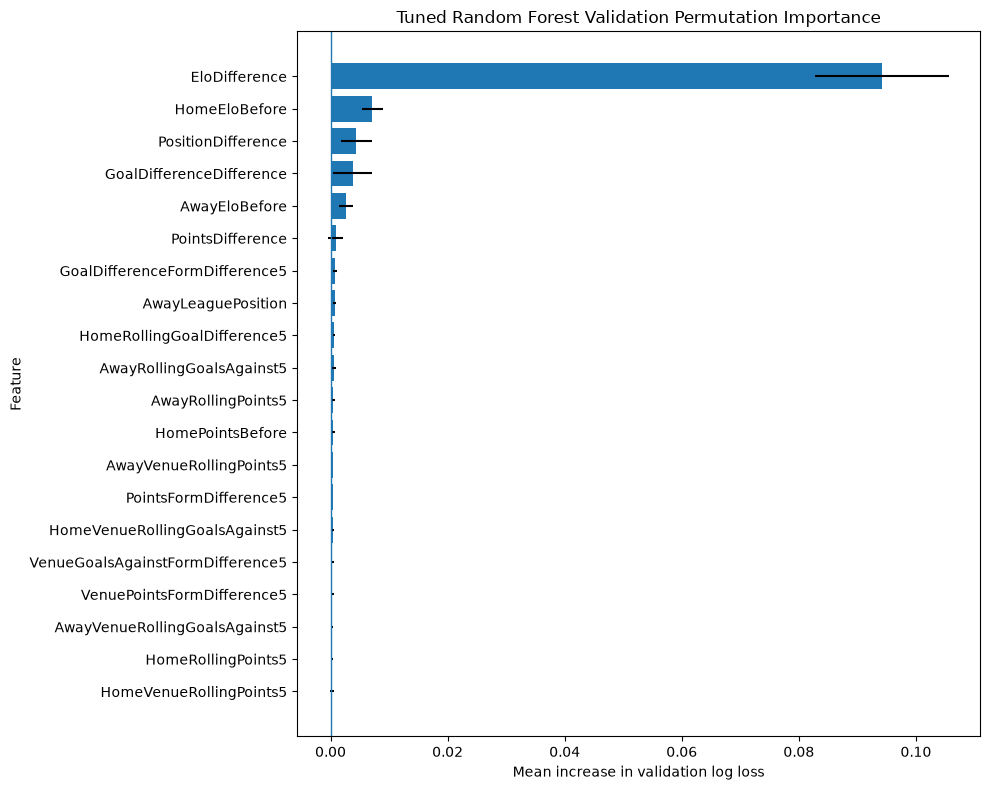

Random Forest feature-importance analysis completed successfully.
Original validation log loss: 0.936744
Permutation repeats per feature: 10
Features with positive mean permutation importance: 44 of 70
Top-ten overlap between importance methods: 7 features
Overlapping top-ten features: ['AwayEloBefore', 'EloDifference', 'GoalDifferenceDifference', 'GoalDifferenceFormDifference5', 'HomeEloBefore', 'PointsDifference', 'PositionDifference']

Top features by validation permutation importance:


,PermutationRank,Feature,ValidationLogLossIncreaseMean,ValidationLogLossIncreaseStd,ImpurityRank,ImpurityImportance,RankDifference
0,1,EloDifference,0.094221,0.011421,1,0.410007,0
1,2,HomeEloBefore,0.007113,0.001773,4,0.061508,2
2,3,PositionDifference,0.004382,0.002619,3,0.085638,0
3,4,GoalDifferenceDifference,0.003780,0.003329,2,0.097105,-2
4,5,AwayEloBefore,0.002606,0.001218,6,0.040370,1
5,6,PointsDifference,0.000893,0.001315,5,0.046072,-1
6,7,GoalDifferenceFormDifference5,0.000744,0.000402,10,0.010992,3
7,8,AwayLeaguePosition,0.000694,0.000282,17,0.006591,9
8,9,HomeRollingGoalDifference5,0.000629,0.000155,29,0.004499,20
9,10,AwayRollingGoalsAgainst5,0.000583,0.000335,14,0.007665,4



Top features by impurity importance:


,ImpurityDisplayRank,Feature,ImpurityImportance,PermutationRank,ValidationLogLossIncreaseMean,ValidationLogLossIncreaseStd
0,1,EloDifference,0.410007,1,0.094221,0.011421
1,2,GoalDifferenceDifference,0.097105,4,0.003780,0.003329
2,3,PositionDifference,0.085638,3,0.004382,0.002619
3,4,HomeEloBefore,0.061508,2,0.007113,0.001773
4,5,PointsDifference,0.046072,6,0.000893,0.001315
5,6,AwayEloBefore,0.040370,5,0.002606,0.001218
6,7,HomeGoalDifferenceBefore,0.019639,23,0.000187,0.000686
7,8,AwayRollingGoalDifference5,0.016916,28,0.000090,0.000664
8,9,AwayGoalDifferenceBefore,0.014718,66,-0.000276,0.000517
9,10,GoalDifferenceFormDifference5,0.010992,7,0.000744,0.000402


In [10]:
# ============================================================
# 9.3 Random Forest Feature Importance
# ============================================================

from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Validate required fitted-model objects
# ------------------------------------------------------------

assert best_random_forest is not None, (
    "The tuned Random Forest has not been fitted."
)

assert hasattr(
    best_random_forest,
    "feature_importances_",
), (
    "The selected model does not expose impurity-based "
    "feature importances."
)

assert len(
    best_random_forest.feature_importances_
) == len(feature_columns), (
    "The number of impurity importances does not match "
    "the number of predictor columns."
)

assert list(
    X_validation_imputed.columns
) == feature_columns, (
    "The validation feature order does not match "
    "feature_columns."
)


# ------------------------------------------------------------
# Calculate impurity-based feature importance
# ------------------------------------------------------------

random_forest_impurity_importance = pd.DataFrame(
    {
        "Feature": feature_columns,
        "ImpurityImportance": (
            best_random_forest.feature_importances_
        ),
    }
)

assert np.isclose(
    random_forest_impurity_importance[
        "ImpurityImportance"
    ].sum(),
    1.0,
), (
    "Random Forest impurity importances do not sum to one."
)

random_forest_impurity_importance = (
    random_forest_impurity_importance
    .sort_values(
        by="ImpurityImportance",
        ascending=False,
        kind="mergesort",
    )
    .reset_index(drop=True)
)

random_forest_impurity_importance[
    "ImpurityRank"
] = np.arange(
    1,
    len(random_forest_impurity_importance) + 1,
)


# ------------------------------------------------------------
# Define a class-order-safe scoring function
# ------------------------------------------------------------

def negative_multiclass_log_loss_scorer(
    fitted_model,
    predictor_matrix,
    observed_outcomes,
):
    """
    Return negative multiclass log loss for use with
    sklearn permutation_importance.

    Scikit-learn assumes that larger scorer values are better.
    Returning negative log loss therefore allows a reduction in
    score after permutation to represent worse probability quality.
    """
    if isinstance(
        observed_outcomes,
        pd.Series,
    ):
        outcome_series = (
            observed_outcomes.copy()
        )
    else:
        outcome_series = pd.Series(
            observed_outcomes,
            index=predictor_matrix.index,
        )

    outcome_series.index = predictor_matrix.index

    raw_probabilities = (
        fitted_model.predict_proba(
            predictor_matrix
        )
    )

    probability_frame = pd.DataFrame(
        raw_probabilities,
        index=predictor_matrix.index,
        columns=fitted_model.classes_,
        dtype=float,
    ).reindex(
        columns=class_order
    )

    validate_probability_forecast(
        probability_frame=probability_frame,
        expected_index=outcome_series.index,
        labels=class_order,
        name="Permutation-importance forecast",
    )

    score = multiclass_log_loss(
        outcome_series,
        probability_frame,
        labels=class_order,
    )

    return -score


# ------------------------------------------------------------
# Confirm that the custom scorer reproduces the stored result
# ------------------------------------------------------------

random_forest_original_validation_score = (
    negative_multiclass_log_loss_scorer(
        best_random_forest,
        X_validation_imputed,
        y_validation,
    )
)

random_forest_original_validation_log_loss = (
    -random_forest_original_validation_score
)

assert np.isclose(
    random_forest_original_validation_log_loss,
    best_random_forest_validation_log_loss,
), (
    "The permutation-importance scorer does not reproduce "
    "the stored Random Forest validation log loss."
)


# ------------------------------------------------------------
# Calculate validation permutation importance
# ------------------------------------------------------------

permutation_repeats = 10

random_forest_permutation_result = (
    permutation_importance(
        estimator=best_random_forest,
        X=X_validation_imputed,
        y=y_validation,
        scoring=negative_multiclass_log_loss_scorer,
        n_repeats=permutation_repeats,
        random_state=random_state,
        n_jobs=-1,
    )
)


# ------------------------------------------------------------
# Construct the permutation-importance table
# ------------------------------------------------------------

random_forest_permutation_importance = pd.DataFrame(
    {
        "Feature": feature_columns,
        "ValidationLogLossIncreaseMean": (
            random_forest_permutation_result[
                "importances_mean"
            ]
        ),
        "ValidationLogLossIncreaseStd": (
            random_forest_permutation_result[
                "importances_std"
            ]
        ),
    }
)

random_forest_permutation_importance = (
    random_forest_permutation_importance
    .sort_values(
        by="ValidationLogLossIncreaseMean",
        ascending=False,
        kind="mergesort",
    )
    .reset_index(drop=True)
)

random_forest_permutation_importance[
    "PermutationRank"
] = np.arange(
    1,
    len(random_forest_permutation_importance) + 1,
)


# ------------------------------------------------------------
# Combine both feature-importance measures
# ------------------------------------------------------------

random_forest_feature_importance = (
    random_forest_permutation_importance
    .merge(
        random_forest_impurity_importance,
        on="Feature",
        how="left",
        validate="one_to_one",
    )
)

random_forest_feature_importance[
    "RankDifference"
] = (
    random_forest_feature_importance[
        "ImpurityRank"
    ]
    -
    random_forest_feature_importance[
        "PermutationRank"
    ]
)

random_forest_feature_importance[
    "PositivePermutationImportance"
] = (
    random_forest_feature_importance[
        "ValidationLogLossIncreaseMean"
    ] > 0
)


# ------------------------------------------------------------
# Validate the completed table
# ------------------------------------------------------------

assert len(
    random_forest_feature_importance
) == len(feature_columns), (
    "The completed importance table does not contain "
    "every feature."
)

assert (
    random_forest_feature_importance[
        "Feature"
    ].nunique()
    ==
    len(feature_columns)
), (
    "A feature appears more than once in the importance table."
)

assert random_forest_feature_importance[
    [
        "ValidationLogLossIncreaseMean",
        "ValidationLogLossIncreaseStd",
        "ImpurityImportance",
    ]
].notna().all().all(), (
    "The feature-importance table contains missing values."
)


# ------------------------------------------------------------
# Prepare display tables
# ------------------------------------------------------------

top_feature_count = min(
    20,
    len(feature_columns),
)

random_forest_top_permutation_features = (
    random_forest_feature_importance
    .head(top_feature_count)
    .copy()
)

random_forest_top_impurity_features = (
    random_forest_feature_importance
    .sort_values(
        by="ImpurityImportance",
        ascending=False,
        kind="mergesort",
    )
    .head(top_feature_count)
    .reset_index(drop=True)
    .copy()
)

random_forest_top_impurity_features[
    "ImpurityDisplayRank"
] = np.arange(
    1,
    len(random_forest_top_impurity_features) + 1,
)

importance_display_columns = [
    "ValidationLogLossIncreaseMean",
    "ValidationLogLossIncreaseStd",
    "ImpurityImportance",
]

for importance_column in importance_display_columns:
    random_forest_top_permutation_features[
        importance_column
    ] = (
        random_forest_top_permutation_features[
            importance_column
        ].round(6)
    )

    random_forest_top_impurity_features[
        importance_column
    ] = (
        random_forest_top_impurity_features[
            importance_column
        ].round(6)
    )


# ------------------------------------------------------------
# Summarise agreement between both methods
# ------------------------------------------------------------

top_ten_permutation_features = set(
    random_forest_feature_importance
    .head(10)["Feature"]
)

top_ten_impurity_features = set(
    random_forest_feature_importance
    .sort_values(
        by="ImpurityImportance",
        ascending=False,
    )
    .head(10)["Feature"]
)

top_ten_overlap = sorted(
    top_ten_permutation_features
    &
    top_ten_impurity_features
)

positive_permutation_feature_count = int(
    random_forest_feature_importance[
        "PositivePermutationImportance"
    ].sum()
)


# ------------------------------------------------------------
# Plot the leading validation permutation importances
# ------------------------------------------------------------

permutation_plot_data = (
    random_forest_top_permutation_features
    .sort_values(
        by="ValidationLogLossIncreaseMean",
        ascending=True,
        kind="mergesort",
    )
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    permutation_plot_data["Feature"],
    permutation_plot_data[
        "ValidationLogLossIncreaseMean"
    ],
    xerr=permutation_plot_data[
        "ValidationLogLossIncreaseStd"
    ],
)

plt.axvline(
    x=0,
    linewidth=1,
)

plt.xlabel(
    "Mean increase in validation log loss"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Tuned Random Forest Validation Permutation Importance"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print(
    "Random Forest feature-importance analysis "
    "completed successfully."
)

print(
    "Original validation log loss:",
    round(
        random_forest_original_validation_log_loss,
        6,
    ),
)

print(
    "Permutation repeats per feature:",
    permutation_repeats,
)

print(
    "Features with positive mean permutation importance:",
    positive_permutation_feature_count,
    "of",
    len(feature_columns),
)

print(
    "Top-ten overlap between importance methods:",
    len(top_ten_overlap),
    "features",
)

print(
    "Overlapping top-ten features:",
    top_ten_overlap,
)

print(
    "\nTop features by validation permutation importance:"
)

display(
    random_forest_top_permutation_features[
        [
            "PermutationRank",
            "Feature",
            "ValidationLogLossIncreaseMean",
            "ValidationLogLossIncreaseStd",
            "ImpurityRank",
            "ImpurityImportance",
            "RankDifference",
        ]
    ]
)

print(
    "\nTop features by impurity importance:"
)

display(
    random_forest_top_impurity_features[
        [
            "ImpurityDisplayRank",
            "Feature",
            "ImpurityImportance",
            "PermutationRank",
            "ValidationLogLossIncreaseMean",
            "ValidationLogLossIncreaseStd",
        ]
    ]
)

### Results and Interpretation

The feature-importance analysis evaluates the tuned Random Forest using both its internal tree structure and its out-of-sample validation performance.

The impurity-based results identify the variables that generated the largest cumulative reductions in node impurity across the 500 fitted trees.

The permutation results provide the more direct measure of validation forecasting contribution. For each feature, the reported value represents the mean increase in validation log loss after that feature was randomly shuffled while the remaining predictors were retained.

A larger positive permutation importance indicates that disrupting the feature caused a larger deterioration in probability quality.

The standard deviation records how much the measured deterioration varied across repeated permutations. Features with a positive mean but a large standard deviation should therefore be interpreted cautiously.

Differences between the impurity and permutation rankings are expected. Impurity importance is based on the training process and may favour variables offering many potential split points. Permutation importance instead measures whether a variable contributes to forecasts on the later validation season.

Correlated predictors may also divide importance between themselves. If two variables contain similar information, shuffling either variable individually may have only a limited effect because the model can continue using the other.

Negative permutation importance does not prove that a variable is harmful. Small negative values may result from validation-sample variation, redundancy or mild overfitting.

The analysis should therefore focus primarily on:

- features with consistently positive permutation importance;
- variables appearing near the top of both rankings;
- broader feature groups such as Elo, form, league-table strength, goal performance and scheduling;
- whether the observed rankings have a coherent pre-match football interpretation.

These importance measures describe model dependence rather than causal effects. They should not be interpreted as evidence that changing a feature would directly cause a change in match outcomes.

### 9.4 Random Forest Conclusions

The Random Forest experiments demonstrate the importance of controlling model complexity when producing probabilistic football forecasts.

The initial unrestricted Random Forest achieved a validation log loss of:

$$
0.969941,
$$

while fitting the training data substantially more closely. This indicated that the default tree structure was too flexible and that the resulting probability estimates did not generalise as effectively as the tuned multinomial logistic-regression benchmark.

Hyperparameter optimisation produced a strongly regularised specification using:

- a maximum tree depth of 5;
- a minimum terminal-leaf size of 30;
- 50% of the predictors as candidates at each split;
- no class weighting;
- 500 trees.

The tuned model achieved:

$$
\operatorname{LogLoss}_{RF,\mathrm{train}}
=
0.924845,
$$

and:

$$
\operatorname{LogLoss}_{RF,\mathrm{validation}}
=
0.936744.
$$

The resulting training–validation gap of:

$$
0.011899
$$

was substantially smaller than that of the unrestricted model, providing evidence that tree regularisation improved out-of-sample generalisation.

The tuned Random Forest remained marginally behind the tuned multinomial logistic-regression result of:

$$
0.934551.
$$

The absolute validation log-loss difference was only:

$$
0.936744-0.934551
=
0.002193,
$$

meaning that the Random Forest was approximately $0.23\%$ worse than logistic regression on the primary evaluation metric.

The feature-importance analysis provides additional insight into which engineered variables the forest relied upon. Permutation importance should be treated as the stronger out-of-sample diagnostic, while differences between impurity and permutation rankings are expected because of correlated predictors, training-sample bias and redundancy within the feature set. These results describe model dependence rather than causal effects.

Overall, the Random Forest did not replace logistic regression as the leading standalone model. However, it produced competitive validation probabilities using a substantially different nonlinear structure. Its retained forecasts may therefore still contribute useful complementary information within a probability ensemble.

## 10. Gradient-Boosted Tree Modelling

### 10.1 Untuned Histogram Gradient Boosting Baseline

The Random Forest analysis demonstrated that strongly regularised nonlinear trees could nearly match the probability performance of the tuned multinomial logistic-regression model.

The next model family is gradient boosting.

Whereas Random Forest fits many trees independently and averages their predictions, gradient boosting constructs trees sequentially. Each new tree attempts to improve the errors remaining from the existing ensemble.

For outcome class $k$, the additive score after $M$ boosting iterations can be represented as:

$$
F_{M,k}(\mathbf{x}_i)
=
F_{0,k}(\mathbf{x}_i)
+
\eta
\sum_{m=1}^{M}
f_{m,k}(\mathbf{x}_i),
$$

where:

- $F_{0,k}$ is the initial class score;
- $f_{m,k}$ is the contribution produced during boosting iteration $m$;
- $\eta$ is the learning rate;
- $M$ is the number of boosting iterations;
- $\mathbf{x}_i$ contains the engineered pre-match predictors for fixture $i$.

The class scores are converted into match-outcome probabilities using the multiclass softmax transformation:

$$
\widehat{p}_{i,k}
=
\frac{
\exp\left(F_{M,k}(\mathbf{x}_i)\right)
}{
\sum_{j \in \{H,D,A\}}
\exp\left(F_{M,j}(\mathbf{x}_i)\right)
}.
$$

The resulting forecast remains:

$$
\widehat{\mathbf{p}}_i
=
\left(
\widehat{p}_{i,H},
\widehat{p}_{i,D},
\widehat{p}_{i,A}
\right).
$$

### Why Gradient Boosting May Improve Probability Forecasts

Gradient-boosted trees can represent:

- nonlinear predictor effects;
- threshold relationships;
- interactions between engineered variables;
- different relationships across distinct regions of the feature space.

Unlike Random Forest, where every tree is fitted independently, later boosting iterations focus on observations and probability errors that the existing ensemble has not modelled successfully.

This sequential procedure often produces strong predictive performance on structured tabular datasets. However, it may also overfit if the trees are too complex, the learning rate is too large or too many boosting iterations are used.

### Histogram-Based Implementation

The model will use `HistGradientBoostingClassifier`.

This algorithm groups continuous predictor values into histogram bins before searching for tree splits. The histogram representation makes training more computationally efficient while retaining the nonlinear structure of gradient-boosted decision trees.

Feature standardisation is not required because tree splits depend on predictor ordering and threshold values rather than the relative measurement scales of the variables.

The training-fitted median-imputed matrices will therefore be reused directly:

- `X_train_imputed`;
- `X_validation_imputed`.

### Initial Model Specification

The untuned baseline will use:

- a learning rate of $0.10$;
- 100 boosting iterations;
- a maximum of 31 terminal leaves per tree;
- a minimum of 20 training observations per leaf;
- no explicit $L_2$ regularisation.

Internal early stopping will be disabled.

This is important because the project already contains an explicit chronological validation season. Allowing the estimator to construct a randomly selected internal validation subset would make the model-selection framework less consistent with the chronological forecasting objective.

### Evaluation Procedure

The model will be trained using the historical training period and evaluated on the validation season.

Probabilities will be explicitly reordered into the fixed project class order:

$$
(H,D,A).
$$

Performance will be measured using:

- multiclass log loss;
- multiclass Brier score;
- accuracy as a secondary diagnostic;
- the training–validation performance gap.

The primary existing validation references are:

$$
\operatorname{LogLoss}_{LR}
=
0.934551,
$$

for tuned multinomial logistic regression, and:

$$
\operatorname{LogLoss}_{RF}
=
0.936744,
$$

for the tuned Random Forest.

The final test period will remain untouched.

In [11]:
# ============================================================
# 10.1 Untuned Histogram Gradient Boosting Baseline
# ============================================================


# ------------------------------------------------------------
# Specify the initial gradient-boosted model
# ------------------------------------------------------------

hist_gradient_boosting_baseline_name = (
    "Untuned Histogram Gradient Boosting"
)

hist_gradient_boosting_baseline = (
    HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.10,
        max_iter=100,
        max_leaf_nodes=31,
        max_depth=None,
        min_samples_leaf=20,
        l2_regularization=0.0,
        early_stopping=False,
        random_state=random_state,
    )
)


# ------------------------------------------------------------
# Fit using the historical training period only
# ------------------------------------------------------------

hist_gradient_boosting_baseline.fit(
    X_train_imputed,
    y_train,
)


# ------------------------------------------------------------
# Validate the fitted model structure
# ------------------------------------------------------------

assert set(
    hist_gradient_boosting_baseline.classes_
) == set(class_order), (
    "The gradient-boosted model did not learn all "
    "three outcome classes."
)

assert (
    hist_gradient_boosting_baseline.n_features_in_
    ==
    X_train_imputed.shape[1]
), (
    "The fitted gradient-boosted model used an "
    "unexpected number of predictors."
)

if hasattr(
    hist_gradient_boosting_baseline,
    "feature_names_in_",
):
    assert list(
        hist_gradient_boosting_baseline.feature_names_in_
    ) == feature_columns, (
        "The fitted feature order does not match "
        "feature_columns."
    )


# ------------------------------------------------------------
# Generate class-order-safe probability forecasts
# ------------------------------------------------------------

hist_gradient_boosting_train_probabilities = (
    create_classifier_probability_frame(
        fitted_model=hist_gradient_boosting_baseline,
        predictor_matrix=X_train_imputed,
        expected_index=y_train.index,
        labels=class_order,
        forecast_name=(
            "Histogram Gradient Boosting "
            "training forecast"
        ),
    )
)

hist_gradient_boosting_validation_probabilities = (
    create_classifier_probability_frame(
        fitted_model=hist_gradient_boosting_baseline,
        predictor_matrix=X_validation_imputed,
        expected_index=y_validation.index,
        labels=class_order,
        forecast_name=(
            "Histogram Gradient Boosting "
            "validation forecast"
        ),
    )
)


# ------------------------------------------------------------
# Convert probabilities into most-likely outcomes
# ------------------------------------------------------------

hist_gradient_boosting_train_predictions = (
    hist_gradient_boosting_train_probabilities.idxmax(
        axis=1
    )
)

hist_gradient_boosting_validation_predictions = (
    hist_gradient_boosting_validation_probabilities.idxmax(
        axis=1
    )
)


# ------------------------------------------------------------
# Calculate training metrics
# ------------------------------------------------------------

hist_gradient_boosting_train_log_loss = (
    multiclass_log_loss(
        y_train,
        hist_gradient_boosting_train_probabilities,
        labels=class_order,
    )
)

hist_gradient_boosting_train_brier = (
    multiclass_brier_score(
        y_train,
        hist_gradient_boosting_train_probabilities,
        labels=class_order,
    )
)

hist_gradient_boosting_train_accuracy = (
    accuracy_score(
        y_train,
        hist_gradient_boosting_train_predictions,
    )
)


# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

hist_gradient_boosting_validation_log_loss = (
    multiclass_log_loss(
        y_validation,
        hist_gradient_boosting_validation_probabilities,
        labels=class_order,
    )
)

hist_gradient_boosting_validation_brier = (
    multiclass_brier_score(
        y_validation,
        hist_gradient_boosting_validation_probabilities,
        labels=class_order,
    )
)

hist_gradient_boosting_validation_accuracy = (
    accuracy_score(
        y_validation,
        hist_gradient_boosting_validation_predictions,
    )
)

hist_gradient_boosting_generalisation_gap = (
    hist_gradient_boosting_validation_log_loss
    -
    hist_gradient_boosting_train_log_loss
)


# ------------------------------------------------------------
# Construct the train-validation summary
# ------------------------------------------------------------

hist_gradient_boosting_baseline_summary = (
    pd.DataFrame(
        [
            {
                "Model": (
                    hist_gradient_boosting_baseline_name
                ),
                "Split": "Train",
                "Fixtures": len(y_train),
                "LogLoss": (
                    hist_gradient_boosting_train_log_loss
                ),
                "BrierScore": (
                    hist_gradient_boosting_train_brier
                ),
                "Accuracy": (
                    hist_gradient_boosting_train_accuracy
                ),
            },
            {
                "Model": (
                    hist_gradient_boosting_baseline_name
                ),
                "Split": "Validation",
                "Fixtures": len(y_validation),
                "LogLoss": (
                    hist_gradient_boosting_validation_log_loss
                ),
                "BrierScore": (
                    hist_gradient_boosting_validation_brier
                ),
                "Accuracy": (
                    hist_gradient_boosting_validation_accuracy
                ),
            },
        ]
    )
)

hist_gradient_boosting_baseline_summary[
    "GeneralisationGap"
] = np.where(
    hist_gradient_boosting_baseline_summary[
        "Split"
    ] == "Validation",
    hist_gradient_boosting_generalisation_gap,
    np.nan,
)


# ------------------------------------------------------------
# Construct the full validation comparison
# ------------------------------------------------------------

validation_benchmark_rows = (
    benchmark_results.loc[
        benchmark_results["Split"] == "Validation",
        [
            "Benchmark",
            "LogLoss",
            "BrierScore",
            "Accuracy",
        ],
    ]
    .rename(
        columns={
            "Benchmark": "Model",
        }
    )
    .copy()
)

logistic_validation_row = pd.DataFrame(
    [
        {
            "Model": (
                logistic_validation_reference.loc[
                    0,
                    "Model",
                ]
            ),
            "LogLoss": (
                logistic_validation_reference.loc[
                    0,
                    "ValidationLogLoss",
                ]
            ),
            "BrierScore": (
                logistic_validation_reference.loc[
                    0,
                    "ValidationBrierScore",
                ]
            ),
            "Accuracy": (
                logistic_validation_reference.loc[
                    0,
                    "ValidationAccuracy",
                ]
            ),
        }
    ]
)

tuned_random_forest_validation_row = pd.DataFrame(
    [
        {
            "Model": "Tuned Random Forest",
            "LogLoss": (
                best_random_forest_validation_log_loss
            ),
            "BrierScore": (
                best_random_forest_validation_brier
            ),
            "Accuracy": (
                best_random_forest_validation_accuracy
            ),
        }
    ]
)

hist_gradient_boosting_validation_row = pd.DataFrame(
    [
        {
            "Model": (
                hist_gradient_boosting_baseline_name
            ),
            "LogLoss": (
                hist_gradient_boosting_validation_log_loss
            ),
            "BrierScore": (
                hist_gradient_boosting_validation_brier
            ),
            "Accuracy": (
                hist_gradient_boosting_validation_accuracy
            ),
        }
    ]
)

hist_gradient_boosting_model_comparison = (
    pd.concat(
        [
            validation_benchmark_rows,
            logistic_validation_row,
            tuned_random_forest_validation_row,
            hist_gradient_boosting_validation_row,
        ],
        ignore_index=True,
    )
)


# ------------------------------------------------------------
# Calculate differences relative to logistic regression
# ------------------------------------------------------------

logistic_reference_log_loss = float(
    logistic_validation_reference.loc[
        0,
        "ValidationLogLoss",
    ]
)

hist_gradient_boosting_model_comparison[
    "LogLossDifferenceVsLogistic"
] = (
    hist_gradient_boosting_model_comparison[
        "LogLoss"
    ]
    -
    logistic_reference_log_loss
)

hist_gradient_boosting_model_comparison[
    "LogLossImprovementVsLogisticPct"
] = (
    100
    * (
        logistic_reference_log_loss
        -
        hist_gradient_boosting_model_comparison[
            "LogLoss"
        ]
    )
    /
    logistic_reference_log_loss
)

hist_gradient_boosting_model_comparison = (
    hist_gradient_boosting_model_comparison
    .sort_values(
        by="LogLoss",
        ascending=True,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Store the model for later nonlinear comparisons
# ------------------------------------------------------------

nonlinear_validation_records[:] = [
    record
    for record in nonlinear_validation_records
    if record.get("Model")
    != hist_gradient_boosting_baseline_name
]

nonlinear_validation_records.append(
    {
        "Model": (
            hist_gradient_boosting_baseline_name
        ),
        "Specification": (
            "Initial gradient-boosted baseline"
        ),
        "ValidationLogLoss": (
            hist_gradient_boosting_validation_log_loss
        ),
        "ValidationBrierScore": (
            hist_gradient_boosting_validation_brier
        ),
        "ValidationAccuracy": (
            hist_gradient_boosting_validation_accuracy
        ),
    }
)


# ------------------------------------------------------------
# Create a fixture-level validation preview
# ------------------------------------------------------------

hist_gradient_boosting_validation_preview = (
    metadata_validation.copy()
)

hist_gradient_boosting_validation_preview[
    "ActualOutcome"
] = y_validation

for outcome in class_order:
    hist_gradient_boosting_validation_preview[
        f"Probability_{outcome}"
    ] = (
        hist_gradient_boosting_validation_probabilities[
            outcome
        ]
    )

hist_gradient_boosting_validation_preview[
    "PredictedOutcome"
] = (
    hist_gradient_boosting_validation_predictions
)

hist_gradient_boosting_validation_preview[
    "ProbabilityOfActualOutcome"
] = [
    hist_gradient_boosting_validation_probabilities.loc[
        fixture_index,
        actual_outcome,
    ]
    for fixture_index, actual_outcome
    in y_validation.items()
]


# ------------------------------------------------------------
# Final validation checks
# ------------------------------------------------------------

assert hist_gradient_boosting_train_log_loss >= 0, (
    "Training log loss cannot be negative."
)

assert hist_gradient_boosting_validation_log_loss >= 0, (
    "Validation log loss cannot be negative."
)

assert hist_gradient_boosting_validation_brier >= 0, (
    "Validation Brier score cannot be negative."
)

assert (
    0
    <= hist_gradient_boosting_validation_accuracy
    <= 1
), (
    "Validation accuracy must lie between zero and one."
)

assert len(
    hist_gradient_boosting_validation_probabilities
) == len(y_validation), (
    "The number of validation probability forecasts "
    "is incorrect."
)

assert set(
    hist_gradient_boosting_validation_predictions.unique()
).issubset(set(class_order)), (
    "The model produced an invalid outcome prediction."
)


# ------------------------------------------------------------
# Prepare rounded display versions
# ------------------------------------------------------------

hist_gradient_boosting_summary_display = (
    hist_gradient_boosting_baseline_summary.copy()
)

for metric_column in [
    "LogLoss",
    "BrierScore",
    "Accuracy",
    "GeneralisationGap",
]:
    hist_gradient_boosting_summary_display[
        metric_column
    ] = (
        hist_gradient_boosting_summary_display[
            metric_column
        ].round(6)
    )

hist_gradient_boosting_comparison_display = (
    hist_gradient_boosting_model_comparison.copy()
)

for metric_column in [
    "LogLoss",
    "BrierScore",
    "Accuracy",
    "LogLossDifferenceVsLogistic",
]:
    hist_gradient_boosting_comparison_display[
        metric_column
    ] = (
        hist_gradient_boosting_comparison_display[
            metric_column
        ].round(6)
    )

hist_gradient_boosting_comparison_display[
    "LogLossImprovementVsLogisticPct"
] = (
    hist_gradient_boosting_comparison_display[
        "LogLossImprovementVsLogisticPct"
    ].round(2)
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print(
    "Untuned Histogram Gradient Boosting fitted "
    "successfully."
)

print(
    "Training log loss:",
    round(
        hist_gradient_boosting_train_log_loss,
        6,
    ),
)

print(
    "Validation log loss:",
    round(
        hist_gradient_boosting_validation_log_loss,
        6,
    ),
)

print(
    "Training-validation log-loss gap:",
    round(
        hist_gradient_boosting_generalisation_gap,
        6,
    ),
)

print(
    "Logistic validation reference:",
    round(
        logistic_reference_log_loss,
        6,
    ),
)

display(
    hist_gradient_boosting_summary_display
)

display(
    hist_gradient_boosting_comparison_display
)

display(
    hist_gradient_boosting_validation_preview[
        [
            season_column,
            date_column,
            home_team_column,
            away_team_column,
            "ActualOutcome",
            "Probability_H",
            "Probability_D",
            "Probability_A",
            "PredictedOutcome",
            "ProbabilityOfActualOutcome",
        ]
    ].head(20)
)

Untuned Histogram Gradient Boosting fitted successfully.
Training log loss: 0.228265
Validation log loss: 1.14524
Training-validation log-loss gap: 0.916974
Logistic validation reference: 0.934551


,Model,Split,Fixtures,LogLoss,BrierScore,Accuracy,GeneralisationGap
0,Untuned Histogram Gradient Boosting,Train,3040,0.228265,0.085012,0.987171,NaN
1,Untuned Histogram Gradient Boosting,Validation,380,1.145240,0.642577,0.536842,0.916974


,Model,LogLoss,BrierScore,Accuracy,LogLossDifferenceVsLogistic,LogLossImprovementVsLogisticPct
0,Tuned multinomial logistic regression,0.934551,0.549322,0.592105,0.000000,0.00
1,Tuned Random Forest,0.936744,0.552182,0.578947,0.002193,-0.23
2,Historical Frequency,1.054044,0.637099,0.460526,0.119493,-12.79
3,Uniform Probability,1.098612,0.666667,0.460526,0.164061,-17.56
4,Untuned Histogram Gradient Boosting,1.145240,0.642577,0.536842,0.210689,-22.54


,Season,Date,HomeTeam,AwayTeam,ActualOutcome,Probability_H,Probability_D,Probability_A,PredictedOutcome,ProbabilityOfActualOutcome
3040,2023-24,2023-08-11,Burnley,Man City,A,0.051731,0.330160,0.618109,A,0.618109
3041,2023-24,2023-08-12,Arsenal,Nott'm Forest,H,0.901400,0.040881,0.057719,H,0.901400
3042,2023-24,2023-08-12,Bournemouth,West Ham,D,0.287625,0.243651,0.468725,A,0.243651
3043,2023-24,2023-08-12,Brighton,Luton,H,0.609315,0.244176,0.146509,H,0.609315
3044,2023-24,2023-08-12,Everton,Fulham,A,0.212771,0.266395,0.520835,A,0.520835
3045,2023-24,2023-08-12,Newcastle,Aston Villa,H,0.407750,0.168680,0.423570,A,0.407750
3046,2023-24,2023-08-12,Sheffield United,Crystal Palace,A,0.305743,0.200419,0.493838,A,0.493838
3047,2023-24,2023-08-13,Brentford,Tottenham,D,0.529381,0.159987,0.310632,H,0.159987
3048,2023-24,2023-08-13,Chelsea,Liverpool,D,0.127566,0.032169,0.840265,A,0.032169
3049,2023-24,2023-08-14,Man United,Wolves,H,0.837924,0.093889,0.068187,H,0.837924


### Results and Interpretation

The untuned Histogram Gradient Boosting model successfully generated probability forecasts for every fixture in the validation season.

However, the initial specification exhibited severe overfitting.

The model achieved a training log loss of:

$$
\operatorname{LogLoss}_{HGB,\mathrm{train}}
=
0.228265,
$$

compared with a validation log loss of:

$$
\operatorname{LogLoss}_{HGB,\mathrm{validation}}
=
1.145240.
$$

The resulting generalisation gap was:

$$
1.145240-0.228265
=
0.916974.
$$

The model also achieved a training accuracy of approximately $98.7\%$, compared with validation accuracy of approximately $53.7\%$. This large difference indicates that the initial gradient-boosted ensemble fitted the historical training fixtures extremely closely but failed to generalise effectively to the later validation season.

The validation log loss of $1.145240$ was worse than all existing model-based and naive benchmarks:

- tuned multinomial logistic regression: $0.934551$;
- tuned Random Forest: $0.936744$;
- historical-frequency probabilities: $1.054044$;
- uniform probabilities: $1.098612$.

The fact that the model performed worse than uniform probabilities on validation log loss suggests that some incorrect forecasts were assigned excessive confidence. Log loss penalises such forecasts heavily, even when the model's most likely class is occasionally correct.

This result does not establish that gradient boosting is unsuitable for the prediction problem. Instead, it demonstrates that the initial combination of 100 boosting iterations, a learning rate of $0.10$, up to 31 terminal leaves and no explicit regularisation produced an ensemble that was far too flexible for the available training data.

The next stage will therefore apply strong regularisation by varying:

- the learning rate;
- the number of boosting iterations;
- the maximum number of terminal leaves;
- the minimum number of observations per leaf;
- the $L_2$ regularisation strength.

The objective is to determine whether a slower, shallower and more strongly regularised boosting process can substantially reduce validation log loss while preserving useful nonlinear predictive structure.

### 10.2 Histogram Gradient Boosting Hyperparameter Optimisation

The untuned Histogram Gradient Boosting model exhibited severe overfitting.

It achieved:

$$
\operatorname{LogLoss}_{HGB,\mathrm{train}}
=
0.228265,
$$

compared with:

$$
\operatorname{LogLoss}_{HGB,\mathrm{validation}}
=
1.145240.
$$

The resulting training–validation gap was:

$$
1.145240-0.228265
=
0.916974.
$$

The model therefore fitted the historical training fixtures extremely closely but produced poorly generalising probability forecasts for the later validation season.

This section will investigate whether a slower and more strongly regularised boosting process can improve out-of-sample probability quality.

### Learning Rate

The learning rate, denoted by $\eta$, scales the contribution made by each boosting iteration:

$$
F_{m,k}(\mathbf{x})
=
F_{m-1,k}(\mathbf{x})
+
\eta f_{m,k}(\mathbf{x}).
$$

A smaller learning rate means that each new tree makes a more limited adjustment to the existing ensemble.

This can improve generalisation, although smaller learning rates usually require more boosting iterations.

### Number of Boosting Iterations

`max_iter` controls the number of sequential boosting stages.

Too many iterations may allow the model to fit noise within the training period. Too few may prevent it from capturing useful nonlinear structure.

The number of iterations must therefore be considered jointly with the learning rate.

### Maximum Number of Leaves

`max_leaf_nodes` limits the number of terminal regions in each tree.

Smaller trees capture simpler interactions and threshold effects. This restricts the complexity of each individual contribution to the boosted ensemble.

### Minimum Terminal-Leaf Size

`min_samples_leaf` controls the minimum number of training fixtures represented by each terminal leaf.

Larger terminal leaves produce smoother probability adjustments because each region is supported by more historical observations.

### $L_2$ Regularisation

`l2_regularization` penalises excessively large terminal-leaf updates.

The search will compare:

$$
\lambda \in \{0,1,5\},
$$

where $\lambda=0$ applies no explicit $L_2$ penalty and larger values impose progressively stronger shrinkage.

### Candidate Grid

The search will evaluate:

- two learning rates: $0.02$ and $0.05$;
- two iteration counts: 100 and 200;
- two maximum-leaf settings: 3 and 7;
- two minimum-leaf-size settings: 30 and 60;
- three $L_2$ regularisation values: 0, 1 and 5.

The total number of candidate specifications is:

$$
2\times2\times2\times2\times3
=
48.
$$

Every candidate will:

- use the same historical training period;
- be evaluated on the same validation season;
- use the training-fitted median-imputed predictors;
- generate probabilities in the fixed $(H,D,A)$ order;
- disable internal early stopping;
- leave the final test period untouched.

The selected parameter vector is:

$$
\theta^*
=
\underset{\theta\in\Theta}{\operatorname{argmin}}
\;
\operatorname{LogLoss}_{\mathrm{validation}}(\theta).
$$

Validation Brier score will be used as a secondary tie-breaker if two specifications produce effectively identical validation log loss.

In [12]:
# ============================================================
# 10.2 Histogram Gradient Boosting Hyperparameter Optimisation
# ============================================================

from sklearn.model_selection import ParameterGrid


# ------------------------------------------------------------
# Define the structured parameter grid
# ------------------------------------------------------------

hist_gradient_boosting_parameter_grid = {
    "learning_rate": [
        0.02,
        0.05,
    ],
    "max_iter": [
        100,
        200,
    ],
    "max_leaf_nodes": [
        3,
        7,
    ],
    "min_samples_leaf": [
        30,
        60,
    ],
    "l2_regularization": [
        0.0,
        1.0,
        5.0,
    ],
}

hist_gradient_boosting_candidates = list(
    ParameterGrid(
        hist_gradient_boosting_parameter_grid
    )
)

expected_hist_gradient_boosting_candidate_count = (
    len(
        hist_gradient_boosting_parameter_grid[
            "learning_rate"
        ]
    )
    * len(
        hist_gradient_boosting_parameter_grid[
            "max_iter"
        ]
    )
    * len(
        hist_gradient_boosting_parameter_grid[
            "max_leaf_nodes"
        ]
    )
    * len(
        hist_gradient_boosting_parameter_grid[
            "min_samples_leaf"
        ]
    )
    * len(
        hist_gradient_boosting_parameter_grid[
            "l2_regularization"
        ]
    )
)

assert (
    len(hist_gradient_boosting_candidates)
    ==
    expected_hist_gradient_boosting_candidate_count
), (
    "The generated Histogram Gradient Boosting grid "
    "contains an unexpected number of candidates."
)

assert (
    expected_hist_gradient_boosting_candidate_count
    == 48
), (
    "The intended search should contain 48 candidates."
)


# ------------------------------------------------------------
# Prepare tuning containers
# ------------------------------------------------------------

hist_gradient_boosting_tuning_records = []

best_hist_gradient_boosting = None
best_hist_gradient_boosting_parameters = None

best_hist_gradient_boosting_train_probabilities = None
best_hist_gradient_boosting_validation_probabilities = None

best_hist_gradient_boosting_train_predictions = None
best_hist_gradient_boosting_validation_predictions = None

best_hist_gradient_boosting_train_log_loss = np.inf
best_hist_gradient_boosting_validation_log_loss = np.inf

best_hist_gradient_boosting_train_brier = np.inf
best_hist_gradient_boosting_validation_brier = np.inf

best_hist_gradient_boosting_train_accuracy = None
best_hist_gradient_boosting_validation_accuracy = None


# ------------------------------------------------------------
# Fit and evaluate each candidate specification
# ------------------------------------------------------------

for candidate_number, candidate_parameters in enumerate(
    hist_gradient_boosting_candidates,
    start=1,
):
    candidate_model = HistGradientBoostingClassifier(
        loss="log_loss",
        max_depth=None,
        early_stopping=False,
        random_state=random_state,
        **candidate_parameters,
    )

    candidate_model.fit(
        X_train_imputed,
        y_train,
    )

    # --------------------------------------------------------
    # Validate the fitted candidate
    # --------------------------------------------------------

    assert set(
        candidate_model.classes_
    ) == set(class_order), (
        f"Candidate {candidate_number} did not learn "
        "all three outcome classes."
    )

    assert (
        candidate_model.n_features_in_
        ==
        X_train_imputed.shape[1]
    ), (
        f"Candidate {candidate_number} used an unexpected "
        "number of predictors."
    )

    assert (
        candidate_model.n_iter_
        ==
        candidate_parameters["max_iter"]
    ), (
        f"Candidate {candidate_number} did not complete the "
        "requested number of boosting iterations."
    )

    # --------------------------------------------------------
    # Generate class-order-safe probabilities
    # --------------------------------------------------------

    candidate_train_probabilities = (
        create_classifier_probability_frame(
            fitted_model=candidate_model,
            predictor_matrix=X_train_imputed,
            expected_index=y_train.index,
            labels=class_order,
            forecast_name=(
                "Histogram Gradient Boosting candidate "
                f"{candidate_number} training forecast"
            ),
        )
    )

    candidate_validation_probabilities = (
        create_classifier_probability_frame(
            fitted_model=candidate_model,
            predictor_matrix=X_validation_imputed,
            expected_index=y_validation.index,
            labels=class_order,
            forecast_name=(
                "Histogram Gradient Boosting candidate "
                f"{candidate_number} validation forecast"
            ),
        )
    )

    candidate_train_predictions = (
        candidate_train_probabilities.idxmax(
            axis=1
        )
    )

    candidate_validation_predictions = (
        candidate_validation_probabilities.idxmax(
            axis=1
        )
    )

    # --------------------------------------------------------
    # Calculate training metrics
    # --------------------------------------------------------

    candidate_train_log_loss = multiclass_log_loss(
        y_train,
        candidate_train_probabilities,
        labels=class_order,
    )

    candidate_train_brier = multiclass_brier_score(
        y_train,
        candidate_train_probabilities,
        labels=class_order,
    )

    candidate_train_accuracy = accuracy_score(
        y_train,
        candidate_train_predictions,
    )

    # --------------------------------------------------------
    # Calculate validation metrics
    # --------------------------------------------------------

    candidate_validation_log_loss = (
        multiclass_log_loss(
            y_validation,
            candidate_validation_probabilities,
            labels=class_order,
        )
    )

    candidate_validation_brier = (
        multiclass_brier_score(
            y_validation,
            candidate_validation_probabilities,
            labels=class_order,
        )
    )

    candidate_validation_accuracy = accuracy_score(
        y_validation,
        candidate_validation_predictions,
    )

    candidate_generalisation_gap = (
        candidate_validation_log_loss
        -
        candidate_train_log_loss
    )

    # --------------------------------------------------------
    # Store the complete candidate result
    # --------------------------------------------------------

    hist_gradient_boosting_tuning_records.append(
        {
            "Candidate": candidate_number,
            "LearningRate": (
                candidate_parameters[
                    "learning_rate"
                ]
            ),
            "MaxIterations": (
                candidate_parameters[
                    "max_iter"
                ]
            ),
            "MaxLeafNodes": (
                candidate_parameters[
                    "max_leaf_nodes"
                ]
            ),
            "MinSamplesLeaf": (
                candidate_parameters[
                    "min_samples_leaf"
                ]
            ),
            "L2Regularization": (
                candidate_parameters[
                    "l2_regularization"
                ]
            ),
            "ActualIterations": (
                candidate_model.n_iter_
            ),
            "TrainLogLoss": (
                candidate_train_log_loss
            ),
            "ValidationLogLoss": (
                candidate_validation_log_loss
            ),
            "ValidationBrierScore": (
                candidate_validation_brier
            ),
            "ValidationAccuracy": (
                candidate_validation_accuracy
            ),
            "GeneralisationGap": (
                candidate_generalisation_gap
            ),
        }
    )

    # --------------------------------------------------------
    # Select by validation log loss, then validation Brier
    # --------------------------------------------------------

    lower_log_loss = (
        candidate_validation_log_loss
        <
        best_hist_gradient_boosting_validation_log_loss
        -
        1e-12
    )

    tied_log_loss_better_brier = (
        np.isclose(
            candidate_validation_log_loss,
            best_hist_gradient_boosting_validation_log_loss,
            atol=1e-12,
            rtol=0,
        )
        and
        candidate_validation_brier
        <
        best_hist_gradient_boosting_validation_brier
    )

    if (
        lower_log_loss
        or tied_log_loss_better_brier
    ):
        best_hist_gradient_boosting = candidate_model

        best_hist_gradient_boosting_parameters = (
            candidate_parameters.copy()
        )

        best_hist_gradient_boosting_train_probabilities = (
            candidate_train_probabilities.copy()
        )

        best_hist_gradient_boosting_validation_probabilities = (
            candidate_validation_probabilities.copy()
        )

        best_hist_gradient_boosting_train_predictions = (
            candidate_train_predictions.copy()
        )

        best_hist_gradient_boosting_validation_predictions = (
            candidate_validation_predictions.copy()
        )

        best_hist_gradient_boosting_train_log_loss = (
            candidate_train_log_loss
        )

        best_hist_gradient_boosting_validation_log_loss = (
            candidate_validation_log_loss
        )

        best_hist_gradient_boosting_train_brier = (
            candidate_train_brier
        )

        best_hist_gradient_boosting_validation_brier = (
            candidate_validation_brier
        )

        best_hist_gradient_boosting_train_accuracy = (
            candidate_train_accuracy
        )

        best_hist_gradient_boosting_validation_accuracy = (
            candidate_validation_accuracy
        )

    # --------------------------------------------------------
    # Display progress updates
    # --------------------------------------------------------

    if (
        candidate_number == 1
        or candidate_number % 8 == 0
        or candidate_number
        == len(hist_gradient_boosting_candidates)
    ):
        print(
            "Completed candidate "
            f"{candidate_number}"
            f"/{len(hist_gradient_boosting_candidates)}"
        )


# ------------------------------------------------------------
# Construct the complete ranked tuning table
# ------------------------------------------------------------

hist_gradient_boosting_tuning_results = pd.DataFrame(
    hist_gradient_boosting_tuning_records
)

logistic_reference_log_loss = float(
    logistic_validation_reference.loc[
        0,
        "ValidationLogLoss",
    ]
)

hist_gradient_boosting_tuning_results[
    "LogLossDifferenceVsLogistic"
] = (
    hist_gradient_boosting_tuning_results[
        "ValidationLogLoss"
    ]
    -
    logistic_reference_log_loss
)

hist_gradient_boosting_tuning_results[
    "LogLossImprovementVsLogisticPct"
] = (
    100
    * (
        logistic_reference_log_loss
        -
        hist_gradient_boosting_tuning_results[
            "ValidationLogLoss"
        ]
    )
    /
    logistic_reference_log_loss
)

hist_gradient_boosting_tuning_results[
    "LogLossImprovementVsUntunedPct"
] = (
    100
    * (
        hist_gradient_boosting_validation_log_loss
        -
        hist_gradient_boosting_tuning_results[
            "ValidationLogLoss"
        ]
    )
    /
    hist_gradient_boosting_validation_log_loss
)

hist_gradient_boosting_tuning_results = (
    hist_gradient_boosting_tuning_results
    .sort_values(
        by=[
            "ValidationLogLoss",
            "ValidationBrierScore",
            "GeneralisationGap",
        ],
        ascending=[
            True,
            True,
            True,
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

hist_gradient_boosting_tuning_results[
    "ValidationRank"
] = np.arange(
    1,
    len(hist_gradient_boosting_tuning_results) + 1,
)


# ------------------------------------------------------------
# Validate the selected model
# ------------------------------------------------------------

assert best_hist_gradient_boosting is not None, (
    "No Histogram Gradient Boosting candidate was selected."
)

assert best_hist_gradient_boosting_parameters is not None, (
    "The selected parameter dictionary is missing."
)

assert np.isclose(
    best_hist_gradient_boosting_validation_log_loss,
    hist_gradient_boosting_tuning_results.loc[
        0,
        "ValidationLogLoss",
    ],
), (
    "The stored best model does not match the "
    "top-ranked tuning result."
)

assert list(
    best_hist_gradient_boosting_validation_probabilities.columns
) == class_order, (
    "The selected model probabilities are not "
    "ordered as (H, D, A)."
)

assert (
    best_hist_gradient_boosting_validation_probabilities
    .index.equals(
        y_validation.index
    )
), (
    "The selected validation probabilities are not "
    "aligned with the validation targets."
)


# ------------------------------------------------------------
# Construct the selected-model summary
# ------------------------------------------------------------

tuned_hist_gradient_boosting_name = (
    "Tuned Histogram Gradient Boosting"
)

best_hist_gradient_boosting_summary = pd.DataFrame(
    [
        {
            "Model": tuned_hist_gradient_boosting_name,
            "Split": "Train",
            "Fixtures": len(y_train),
            "LogLoss": (
                best_hist_gradient_boosting_train_log_loss
            ),
            "BrierScore": (
                best_hist_gradient_boosting_train_brier
            ),
            "Accuracy": (
                best_hist_gradient_boosting_train_accuracy
            ),
        },
        {
            "Model": tuned_hist_gradient_boosting_name,
            "Split": "Validation",
            "Fixtures": len(y_validation),
            "LogLoss": (
                best_hist_gradient_boosting_validation_log_loss
            ),
            "BrierScore": (
                best_hist_gradient_boosting_validation_brier
            ),
            "Accuracy": (
                best_hist_gradient_boosting_validation_accuracy
            ),
        },
    ]
)

best_hist_gradient_boosting_parameter_summary = (
    pd.DataFrame(
        [
            {
                "LearningRate": (
                    best_hist_gradient_boosting_parameters[
                        "learning_rate"
                    ]
                ),
                "MaxIterations": (
                    best_hist_gradient_boosting_parameters[
                        "max_iter"
                    ]
                ),
                "MaxLeafNodes": (
                    best_hist_gradient_boosting_parameters[
                        "max_leaf_nodes"
                    ]
                ),
                "MinSamplesLeaf": (
                    best_hist_gradient_boosting_parameters[
                        "min_samples_leaf"
                    ]
                ),
                "L2Regularization": (
                    best_hist_gradient_boosting_parameters[
                        "l2_regularization"
                    ]
                ),
                "TrainValidationLogLossGap": (
                    best_hist_gradient_boosting_validation_log_loss
                    -
                    best_hist_gradient_boosting_train_log_loss
                ),
            }
        ]
    )
)


# ------------------------------------------------------------
# Compare all principal validation models
# ------------------------------------------------------------

validation_benchmark_rows = (
    benchmark_results.loc[
        benchmark_results["Split"] == "Validation",
        [
            "Benchmark",
            "LogLoss",
            "BrierScore",
            "Accuracy",
        ],
    ]
    .rename(
        columns={
            "Benchmark": "Model",
        }
    )
    .copy()
)

logistic_validation_row = pd.DataFrame(
    [
        {
            "Model": (
                logistic_validation_reference.loc[
                    0,
                    "Model",
                ]
            ),
            "LogLoss": (
                logistic_validation_reference.loc[
                    0,
                    "ValidationLogLoss",
                ]
            ),
            "BrierScore": (
                logistic_validation_reference.loc[
                    0,
                    "ValidationBrierScore",
                ]
            ),
            "Accuracy": (
                logistic_validation_reference.loc[
                    0,
                    "ValidationAccuracy",
                ]
            ),
        }
    ]
)

tuned_random_forest_validation_row = pd.DataFrame(
    [
        {
            "Model": "Tuned Random Forest",
            "LogLoss": (
                best_random_forest_validation_log_loss
            ),
            "BrierScore": (
                best_random_forest_validation_brier
            ),
            "Accuracy": (
                best_random_forest_validation_accuracy
            ),
        }
    ]
)

untuned_hist_gradient_boosting_validation_row = (
    pd.DataFrame(
        [
            {
                "Model": (
                    hist_gradient_boosting_baseline_name
                ),
                "LogLoss": (
                    hist_gradient_boosting_validation_log_loss
                ),
                "BrierScore": (
                    hist_gradient_boosting_validation_brier
                ),
                "Accuracy": (
                    hist_gradient_boosting_validation_accuracy
                ),
            }
        ]
    )
)

tuned_hist_gradient_boosting_validation_row = (
    pd.DataFrame(
        [
            {
                "Model": (
                    tuned_hist_gradient_boosting_name
                ),
                "LogLoss": (
                    best_hist_gradient_boosting_validation_log_loss
                ),
                "BrierScore": (
                    best_hist_gradient_boosting_validation_brier
                ),
                "Accuracy": (
                    best_hist_gradient_boosting_validation_accuracy
                ),
            }
        ]
    )
)

hist_gradient_boosting_model_comparison = pd.concat(
    [
        validation_benchmark_rows,
        logistic_validation_row,
        tuned_random_forest_validation_row,
        untuned_hist_gradient_boosting_validation_row,
        tuned_hist_gradient_boosting_validation_row,
    ],
    ignore_index=True,
)

hist_gradient_boosting_model_comparison[
    "LogLossDifferenceVsLogistic"
] = (
    hist_gradient_boosting_model_comparison[
        "LogLoss"
    ]
    -
    logistic_reference_log_loss
)

hist_gradient_boosting_model_comparison[
    "LogLossImprovementVsLogisticPct"
] = (
    100
    * (
        logistic_reference_log_loss
        -
        hist_gradient_boosting_model_comparison[
            "LogLoss"
        ]
    )
    /
    logistic_reference_log_loss
)

hist_gradient_boosting_model_comparison = (
    hist_gradient_boosting_model_comparison
    .sort_values(
        by="LogLoss",
        ascending=True,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Store the selected model for later comparison
# ------------------------------------------------------------

nonlinear_validation_records[:] = [
    record
    for record in nonlinear_validation_records
    if record.get("Model")
    != tuned_hist_gradient_boosting_name
]

nonlinear_validation_records.append(
    {
        "Model": tuned_hist_gradient_boosting_name,
        "Specification": (
            "Validation-selected Histogram "
            "Gradient Boosting"
        ),
        "ValidationLogLoss": (
            best_hist_gradient_boosting_validation_log_loss
        ),
        "ValidationBrierScore": (
            best_hist_gradient_boosting_validation_brier
        ),
        "ValidationAccuracy": (
            best_hist_gradient_boosting_validation_accuracy
        ),
    }
)


# ------------------------------------------------------------
# Prepare rounded display tables
# ------------------------------------------------------------

hist_gradient_boosting_tuning_display = (
    hist_gradient_boosting_tuning_results
    .head(15)
    .copy()
)

for metric_column in [
    "TrainLogLoss",
    "ValidationLogLoss",
    "ValidationBrierScore",
    "ValidationAccuracy",
    "GeneralisationGap",
    "LogLossDifferenceVsLogistic",
    "LogLossImprovementVsLogisticPct",
    "LogLossImprovementVsUntunedPct",
]:
    hist_gradient_boosting_tuning_display[
        metric_column
    ] = (
        hist_gradient_boosting_tuning_display[
            metric_column
        ].round(6)
    )

best_hist_gradient_boosting_summary_display = (
    best_hist_gradient_boosting_summary.copy()
)

for metric_column in [
    "LogLoss",
    "BrierScore",
    "Accuracy",
]:
    best_hist_gradient_boosting_summary_display[
        metric_column
    ] = (
        best_hist_gradient_boosting_summary_display[
            metric_column
        ].round(6)
    )

hist_gradient_boosting_comparison_display = (
    hist_gradient_boosting_model_comparison.copy()
)

for metric_column in [
    "LogLoss",
    "BrierScore",
    "Accuracy",
    "LogLossDifferenceVsLogistic",
]:
    hist_gradient_boosting_comparison_display[
        metric_column
    ] = (
        hist_gradient_boosting_comparison_display[
            metric_column
        ].round(6)
    )

hist_gradient_boosting_comparison_display[
    "LogLossImprovementVsLogisticPct"
] = (
    hist_gradient_boosting_comparison_display[
        "LogLossImprovementVsLogisticPct"
    ].round(2)
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print(
    "Histogram Gradient Boosting hyperparameter "
    "search completed successfully."
)

print(
    "Candidates evaluated:",
    len(hist_gradient_boosting_tuning_results),
)

print(
    "Best parameters:",
    best_hist_gradient_boosting_parameters,
)

print(
    "Best training log loss:",
    round(
        best_hist_gradient_boosting_train_log_loss,
        6,
    ),
)

print(
    "Best validation log loss:",
    round(
        best_hist_gradient_boosting_validation_log_loss,
        6,
    ),
)

print(
    "Training-validation log-loss gap:",
    round(
        (
            best_hist_gradient_boosting_validation_log_loss
            -
            best_hist_gradient_boosting_train_log_loss
        ),
        6,
    ),
)

print(
    "Logistic validation reference:",
    round(
        logistic_reference_log_loss,
        6,
    ),
)

display(
    best_hist_gradient_boosting_parameter_summary
)

display(
    best_hist_gradient_boosting_summary_display
)

display(
    hist_gradient_boosting_tuning_display
)

display(
    hist_gradient_boosting_comparison_display
)

Completed candidate 1/48
Completed candidate 8/48
Completed candidate 16/48
Completed candidate 24/48
Completed candidate 32/48
Completed candidate 40/48
Completed candidate 48/48
Histogram Gradient Boosting hyperparameter search completed successfully.
Candidates evaluated: 48
Best parameters: {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_iter': 100, 'max_leaf_nodes': 3, 'min_samples_leaf': 30}
Best training log loss: 0.92816
Best validation log loss: 0.937378
Training-validation log-loss gap: 0.009218
Logistic validation reference: 0.934551


,LearningRate,MaxIterations,MaxLeafNodes,MinSamplesLeaf,L2Regularization,TrainValidationLogLossGap
0,0.05,100,3,30,1.0,0.009218


,Model,Split,Fixtures,LogLoss,BrierScore,Accuracy
0,Tuned Histogram Gradient Boosting,Train,3040,0.928160,0.550566,0.552632
1,Tuned Histogram Gradient Boosting,Validation,380,0.937378,0.551925,0.581579


,Candidate,LearningRate,MaxIterations,MaxLeafNodes,MinSamplesLeaf,L2Regularization,ActualIterations,TrainLogLoss,ValidationLogLoss,ValidationBrierScore,ValidationAccuracy,GeneralisationGap,LogLossDifferenceVsLogistic,LogLossImprovementVsLogisticPct,LogLossImprovementVsUntunedPct,ValidationRank
0,25,0.05,100,3,30,1.0,100,0.928160,0.937378,0.551925,0.581579,0.009218,0.002827,-0.302505,18.150065,1
1,5,0.02,200,3,30,0.0,200,0.935240,0.937875,0.552464,0.584211,0.002635,0.003324,-0.355729,18.106633,2
2,41,0.05,100,3,30,5.0,100,0.932591,0.938494,0.552487,0.584211,0.005903,0.003943,-0.421966,18.052581,3
3,9,0.05,100,3,30,0.0,100,0.926749,0.938758,0.552501,0.584211,0.012009,0.004207,-0.450115,18.029611,4
4,45,0.05,200,3,30,5.0,200,0.902853,0.939034,0.553221,0.584211,0.036182,0.004483,-0.479744,18.005432,5
5,21,0.02,200,3,30,1.0,200,0.936624,0.939088,0.553095,0.586842,0.002464,0.004537,-0.485452,18.000775,6
6,37,0.02,200,3,30,5.0,200,0.939832,0.939601,0.553276,0.581579,-0.000231,0.005050,-0.540369,17.955961,7
7,42,0.05,100,3,60,5.0,100,0.932843,0.940805,0.554056,0.576316,0.007962,0.006254,-0.669241,17.850797,8
8,38,0.02,200,3,60,5.0,200,0.939891,0.940814,0.554079,0.576316,0.000923,0.006263,-0.670153,17.850052,9
9,29,0.05,200,3,30,1.0,200,0.893454,0.941148,0.553500,0.586842,0.047694,0.006597,-0.705911,17.820873,10


,Model,LogLoss,BrierScore,Accuracy,LogLossDifferenceVsLogistic,LogLossImprovementVsLogisticPct
0,Tuned multinomial logistic regression,0.934551,0.549322,0.592105,0.000000,0.00
1,Tuned Random Forest,0.936744,0.552182,0.578947,0.002193,-0.23
2,Tuned Histogram Gradient Boosting,0.937378,0.551925,0.581579,0.002827,-0.30
3,Historical Frequency,1.054044,0.637099,0.460526,0.119493,-12.79
4,Uniform Probability,1.098612,0.666667,0.460526,0.164061,-17.56
5,Untuned Histogram Gradient Boosting,1.145240,0.642577,0.536842,0.210689,-22.54


### Results and Interpretation

The structured Histogram Gradient Boosting search evaluated 48 candidate specifications using validation log loss as the primary model-selection criterion.

The selected specification used:

- `learning_rate = 0.05`;
- `max_iter = 100`;
- `max_leaf_nodes = 3`;
- `min_samples_leaf = 30`;
- `l2_regularization = 1.0`.

The selected model achieved:

$$
\operatorname{LogLoss}_{HGB,\mathrm{train}}
=
0.928160,
$$

and:

$$
\operatorname{LogLoss}_{HGB,\mathrm{validation}}
=
0.937378.
$$

The resulting training–validation gap was:

$$
0.937378-0.928160
=
0.009218.
$$

This represents a substantial improvement in generalisation relative to the untuned Histogram Gradient Boosting model.

The initial specification achieved a validation log loss of:

$$
1.145240,
$$

with a training–validation gap of:

$$
0.916974.
$$

The tuned model therefore reduced validation log loss by approximately:

$$
\frac{1.145240-0.937378}{1.145240}
\times100
\approx
18.15\%.
$$

The selected configuration used only three terminal leaves per boosting tree, a minimum leaf size of 30 and positive $L_2$ regularisation. This indicates that strong control of model complexity was necessary for the sequential boosting process to generalise effectively.

The tuned Histogram Gradient Boosting model nevertheless remained marginally behind the two leading validation models.

The tuned multinomial logistic-regression model achieved:

$$
\operatorname{LogLoss}_{LR,\mathrm{validation}}
=
0.934551,
$$

while the tuned Random Forest achieved:

$$
\operatorname{LogLoss}_{RF,\mathrm{validation}}
=
0.936744.
$$

The gradient-boosting result was therefore:

$$
0.937378-0.934551
=
0.002827
$$

higher than the logistic-regression result, corresponding to approximately $0.30\%$ worse validation log loss.

It was only:

$$
0.937378-0.936744
=
0.000634
$$

behind the tuned Random Forest.

The three tuned models therefore produced very similar validation probability performance despite using substantially different modelling structures.

The tuned gradient-boosting model also achieved validation accuracy of approximately $58.2\%$. However, model selection remains based on log loss because the project evaluates the complete probability distribution rather than only the most likely outcome.

Overall, hyperparameter optimisation transformed the gradient-boosted model from a severely overfitted specification into a competitive nonlinear probability model. Logistic regression remains the current validation leader, but the small differences between the three tuned models justify investigating whether their forecasts contain complementary information that could improve an ensemble.

### 10.3 Histogram Gradient Boosting Conclusions

The Histogram Gradient Boosting experiments provide a second demonstration of the need for strong regularisation when applying flexible nonlinear models to football probability forecasting.

The initial specification achieved a training log loss of:

$$
0.228265,
$$

and training accuracy of approximately $98.7\%$.

However, its validation log loss increased to:

$$
1.145240,
$$

producing a training–validation gap of:

$$
0.916974.
$$

The untuned model therefore fitted the historical training observations extremely closely but generalised poorly to the later validation season. Its validation log loss was worse than both naive probability benchmarks, indicating that some incorrect forecasts were assigned excessive confidence.

The structured hyperparameter search selected a substantially more constrained specification using:

- a learning rate of $0.05$;
- 100 boosting iterations;
- a maximum of 3 terminal leaves per tree;
- a minimum terminal-leaf size of 30;
- $L_2$ regularisation of 1.0.

The tuned model achieved:

$$
\operatorname{LogLoss}_{HGB,\mathrm{train}}
=
0.928160,
$$

and:

$$
\operatorname{LogLoss}_{HGB,\mathrm{validation}}
=
0.937378.
$$

The resulting training–validation gap was reduced to:

$$
0.009218.
$$

Relative to the untuned specification, validation log loss improved by approximately:

$$
\frac{1.145240-0.937378}{1.145240}
\times100
\approx
18.15\%.
$$

This substantial improvement indicates that shallow trees, slower sequential updates and explicit regularisation were necessary for the boosting process to produce stable probabilities.

The tuned Histogram Gradient Boosting model remained marginally behind both leading validation models:

$$
\operatorname{LogLoss}_{LR}
=
0.934551,
$$

and:

$$
\operatorname{LogLoss}_{RF}
=
0.936744.
$$

Its validation log loss was only:

$$
0.937378-0.934551
=
0.002827
$$

higher than logistic regression and:

$$
0.937378-0.936744
=
0.000634
$$

higher than the tuned Random Forest.

The three tuned models therefore achieved very similar validation probability performance despite using different mathematical structures.

Overall, Histogram Gradient Boosting did not become the leading standalone model. Nevertheless, tuning transformed it from a severely overfitted specification into a competitive probability forecaster. Because its sequential boosting process may generate different fixture-level errors from logistic regression and Random Forest, its probabilities should be retained for the subsequent ensemble analysis.

## 11. Validation Model Comparison and Ensemble Analysis

The tuned model families produced very similar validation log losses despite representing the forecasting problem differently:

$$
\operatorname{LogLoss}_{LR}
=
0.934551,
$$

$$
\operatorname{LogLoss}_{RF}
=
0.936744,
$$

and:

$$
\operatorname{LogLoss}_{HGB}
=
0.937378.
$$

Multinomial logistic regression estimates a regularised linear relationship between the engineered predictors and the class-specific scores.

Random Forest averages probability estimates from many independently fitted decision trees.

Histogram Gradient Boosting constructs a sequence of small trees in which later iterations attempt to improve the errors remaining from the existing ensemble.

Because these models impose different structures, they may make different probability errors even when their aggregate validation performance is similar.

### Probability Averaging

For fixture $i$, define:

- $\widehat{\mathbf p}^{\,L}_i$ as the tuned logistic-regression forecast;
- $\widehat{\mathbf p}^{\,R}_i$ as the tuned Random Forest forecast;
- $\widehat{\mathbf p}^{\,G}_i$ as the tuned Histogram Gradient Boosting forecast.

A weighted probability ensemble is:

$$
\widehat{\mathbf p}^{\,E}_i
=
w_L\widehat{\mathbf p}^{\,L}_i
+
w_R\widehat{\mathbf p}^{\,R}_i
+
w_G\widehat{\mathbf p}^{\,G}_i,
$$

subject to:

$$
w_L+w_R+w_G=1,
$$

and:

$$
w_L,w_R,w_G\geq0.
$$

A convex combination preserves valid probabilities because every component forecast is non-negative and sums to one.

### Why an Ensemble May Improve Performance

An ensemble may improve probability quality when the component models make complementary errors.

For example, logistic regression may provide stable global probability estimates, while the nonlinear models may capture threshold effects and interactions that the linear model cannot represent directly.

A model does not need to be the strongest standalone forecaster to contribute useful information. A slightly weaker model may still improve an ensemble if its errors differ from those of the leading model.

However, averaging highly similar forecasts may provide little or no improvement.

### Logistic-Regression Probability Reconstruction

Notebook 4 currently stores the validation metrics from the tuned logistic-regression model but not its fixture-level probabilities.

The probabilities will therefore be reproduced using the exact selected Notebook 3 specification:

- median imputation fitted on the training period;
- standardisation fitted on the imputed training predictors;
- `C = 0.01`;
- no class weighting;
- the `lbfgs` solver;
- 5,000 maximum iterations.

The reconstructed validation log loss must agree with the stored reference value before ensemble analysis begins.

### Weight Search

The ensemble weights will be evaluated in increments of:

$$
0.05.
$$

Each weight can therefore take one of 21 possible values between zero and one, subject to the weights summing to one.

The search includes:

- all three standalone models;
- every pairwise blend;
- every three-model blend permitted by the grid.

The selected weights are:

$$
(w_L^*,w_R^*,w_G^*)
=
\underset{
w_L+w_R+w_G=1
}{
\operatorname{argmin}
}
\;
\operatorname{LogLoss}_{\mathrm{validation}}.
$$

Validation Brier score will act as a secondary tie-breaker.

The search will also identify the best **strict ensemble**, defined as a forecast assigning positive weight to at least two models. This separates genuine probability blending from standalone models represented by the boundary points of the weight grid.

The test season will remain untouched throughout weight selection.

In [13]:
# ============================================================
# 11. Validation Model Comparison and Ensemble Analysis
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# 11.1 Reconstruct tuned logistic-regression probabilities
# ------------------------------------------------------------

ensemble_logistic_scaler = StandardScaler()

X_train_logistic_scaled_array = (
    ensemble_logistic_scaler.fit_transform(
        X_train_imputed
    )
)

X_validation_logistic_scaled_array = (
    ensemble_logistic_scaler.transform(
        X_validation_imputed
    )
)

X_train_logistic_scaled = pd.DataFrame(
    X_train_logistic_scaled_array,
    index=X_train_imputed.index,
    columns=feature_columns,
)

X_validation_logistic_scaled = pd.DataFrame(
    X_validation_logistic_scaled_array,
    index=X_validation_imputed.index,
    columns=feature_columns,
)


# ------------------------------------------------------------
# Fit the exact validation-selected Notebook 3 specification
# ------------------------------------------------------------

ensemble_logistic_model = LogisticRegression(
    C=0.01,
    class_weight=None,
    solver="lbfgs",
    max_iter=5000,
)

ensemble_logistic_model.fit(
    X_train_logistic_scaled,
    y_train,
)

assert set(
    ensemble_logistic_model.classes_
) == set(class_order), (
    "The reconstructed logistic model did not learn "
    "all three outcome classes."
)

assert int(
    ensemble_logistic_model.n_iter_.max()
) < ensemble_logistic_model.max_iter, (
    "The reconstructed logistic model did not converge."
)


# ------------------------------------------------------------
# Generate class-order-safe validation probabilities
# ------------------------------------------------------------

ensemble_logistic_validation_probabilities = (
    create_classifier_probability_frame(
        fitted_model=ensemble_logistic_model,
        predictor_matrix=X_validation_logistic_scaled,
        expected_index=y_validation.index,
        labels=class_order,
        forecast_name=(
            "Reconstructed tuned logistic "
            "validation forecast"
        ),
    )
)

ensemble_logistic_validation_predictions = (
    ensemble_logistic_validation_probabilities.idxmax(
        axis=1
    )
)

ensemble_logistic_validation_log_loss = (
    multiclass_log_loss(
        y_validation,
        ensemble_logistic_validation_probabilities,
        labels=class_order,
    )
)

ensemble_logistic_validation_brier = (
    multiclass_brier_score(
        y_validation,
        ensemble_logistic_validation_probabilities,
        labels=class_order,
    )
)

ensemble_logistic_validation_accuracy = (
    accuracy_score(
        y_validation,
        ensemble_logistic_validation_predictions,
    )
)


# ------------------------------------------------------------
# Verify reproduction of the stored Notebook 3 result
# ------------------------------------------------------------

stored_logistic_validation_log_loss = float(
    logistic_validation_reference.loc[
        0,
        "ValidationLogLoss",
    ]
)

assert np.isclose(
    ensemble_logistic_validation_log_loss,
    stored_logistic_validation_log_loss,
    atol=5e-6,
    rtol=0,
), (
    "The reconstructed logistic validation log loss does "
    "not reproduce the stored Notebook 3 reference. "
    f"Reconstructed: "
    f"{ensemble_logistic_validation_log_loss:.9f}; "
    f"stored: {stored_logistic_validation_log_loss:.9f}."
)


# ------------------------------------------------------------
# 11.2 Validate all component probability frames
# ------------------------------------------------------------

component_validation_probabilities = {
    "LogisticRegression": (
        ensemble_logistic_validation_probabilities
    ),
    "RandomForest": (
        best_random_forest_validation_probabilities
    ),
    "HistogramGradientBoosting": (
        best_hist_gradient_boosting_validation_probabilities
    ),
}

for (
    component_name,
    component_probability_frame,
) in component_validation_probabilities.items():

    validate_probability_forecast(
        probability_frame=component_probability_frame,
        expected_index=y_validation.index,
        labels=class_order,
        name=f"{component_name} ensemble input",
    )

    assert list(
        component_probability_frame.columns
    ) == class_order, (
        f"{component_name} probabilities are not ordered "
        "as (H, D, A)."
    )

    assert component_probability_frame.index.equals(
        y_validation.index
    ), (
        f"{component_name} probabilities are not aligned "
        "with the validation outcomes."
    )


# ------------------------------------------------------------
# Store shorter references for the weight search
# ------------------------------------------------------------

logistic_probability_matrix = (
    ensemble_logistic_validation_probabilities
)

random_forest_probability_matrix = (
    best_random_forest_validation_probabilities
)

hist_gradient_boosting_probability_matrix = (
    best_hist_gradient_boosting_validation_probabilities
)


# ------------------------------------------------------------
# 11.3 Measure disagreement between component forecasts
# ------------------------------------------------------------

component_probability_pairs = [
    (
        "Logistic Regression",
        logistic_probability_matrix,
        "Random Forest",
        random_forest_probability_matrix,
    ),
    (
        "Logistic Regression",
        logistic_probability_matrix,
        "Histogram Gradient Boosting",
        hist_gradient_boosting_probability_matrix,
    ),
    (
        "Random Forest",
        random_forest_probability_matrix,
        "Histogram Gradient Boosting",
        hist_gradient_boosting_probability_matrix,
    ),
]

ensemble_component_disagreement_records = []

for (
    model_one_name,
    model_one_probabilities,
    model_two_name,
    model_two_probabilities,
) in component_probability_pairs:

    mean_absolute_probability_difference = float(
        np.abs(
            model_one_probabilities.to_numpy()
            -
            model_two_probabilities.to_numpy()
        ).mean()
    )

    model_one_predictions = (
        model_one_probabilities.idxmax(axis=1)
    )

    model_two_predictions = (
        model_two_probabilities.idxmax(axis=1)
    )

    predicted_outcome_agreement = float(
        (
            model_one_predictions
            ==
            model_two_predictions
        ).mean()
    )

    ensemble_component_disagreement_records.append(
        {
            "ModelOne": model_one_name,
            "ModelTwo": model_two_name,
            "MeanAbsoluteProbabilityDifference": (
                mean_absolute_probability_difference
            ),
            "PredictedOutcomeAgreement": (
                predicted_outcome_agreement
            ),
        }
    )

ensemble_component_disagreement = pd.DataFrame(
    ensemble_component_disagreement_records
)


# ------------------------------------------------------------
# 11.4 Construct the convex weight grid
# ------------------------------------------------------------

weight_increment = 0.05
weight_units = 20

assert np.isclose(
    1 / weight_units,
    weight_increment,
), (
    "The weight-unit definition does not match the "
    "intended 0.05 increment."
)

ensemble_weight_combinations = []

for logistic_units in range(
    weight_units + 1
):
    for random_forest_units in range(
        weight_units - logistic_units + 1
    ):
        hist_gradient_boosting_units = (
            weight_units
            -
            logistic_units
            -
            random_forest_units
        )

        ensemble_weight_combinations.append(
            {
                "LogisticWeight": (
                    logistic_units / weight_units
                ),
                "RandomForestWeight": (
                    random_forest_units / weight_units
                ),
                "HistogramGradientBoostingWeight": (
                    hist_gradient_boosting_units
                    / weight_units
                ),
            }
        )

expected_weight_combination_count = (
    (weight_units + 1)
    * (weight_units + 2)
    // 2
)

assert len(
    ensemble_weight_combinations
) == expected_weight_combination_count, (
    "The ensemble weight grid contains an unexpected "
    "number of combinations."
)

assert expected_weight_combination_count == 231, (
    "A 0.05 three-model simplex should contain "
    "231 weight combinations."
)


# ------------------------------------------------------------
# Evaluate every probability-weight combination
# ------------------------------------------------------------

ensemble_weight_search_records = {}
ensemble_weight_search_rows = []

for combination_number, weights in enumerate(
    ensemble_weight_combinations,
    start=1,
):
    logistic_weight = weights[
        "LogisticWeight"
    ]

    random_forest_weight = weights[
        "RandomForestWeight"
    ]

    hist_gradient_boosting_weight = weights[
        "HistogramGradientBoostingWeight"
    ]

    weight_sum = (
        logistic_weight
        +
        random_forest_weight
        +
        hist_gradient_boosting_weight
    )

    assert np.isclose(
        weight_sum,
        1.0,
    ), (
        f"Combination {combination_number} does not "
        "sum to one."
    )

    ensemble_probabilities = (
        logistic_weight
        * logistic_probability_matrix
        +
        random_forest_weight
        * random_forest_probability_matrix
        +
        hist_gradient_boosting_weight
        * hist_gradient_boosting_probability_matrix
    )

    validate_probability_forecast(
        probability_frame=ensemble_probabilities,
        expected_index=y_validation.index,
        labels=class_order,
        name=(
            "Ensemble candidate "
            f"{combination_number}"
        ),
    )

    ensemble_predictions = (
        ensemble_probabilities.idxmax(
            axis=1
        )
    )

    ensemble_log_loss = multiclass_log_loss(
        y_validation,
        ensemble_probabilities,
        labels=class_order,
    )

    ensemble_brier = multiclass_brier_score(
        y_validation,
        ensemble_probabilities,
        labels=class_order,
    )

    ensemble_accuracy = accuracy_score(
        y_validation,
        ensemble_predictions,
    )

    positive_weight_count = int(
        logistic_weight > 0
    ) + int(
        random_forest_weight > 0
    ) + int(
        hist_gradient_boosting_weight > 0
    )

    candidate_key = (
        logistic_weight,
        random_forest_weight,
        hist_gradient_boosting_weight,
    )

    ensemble_weight_search_records[
        candidate_key
    ] = ensemble_probabilities.copy()

    ensemble_weight_search_rows.append(
        {
            "Candidate": combination_number,
            "LogisticWeight": logistic_weight,
            "RandomForestWeight": (
                random_forest_weight
            ),
            "HistogramGradientBoostingWeight": (
                hist_gradient_boosting_weight
            ),
            "ModelsUsed": positive_weight_count,
            "ValidationLogLoss": ensemble_log_loss,
            "ValidationBrierScore": ensemble_brier,
            "ValidationAccuracy": ensemble_accuracy,
        }
    )


# ------------------------------------------------------------
# Rank the complete weight search
# ------------------------------------------------------------

ensemble_weight_search_results = pd.DataFrame(
    ensemble_weight_search_rows
)

ensemble_weight_search_results[
    "LogLossDifferenceVsLogistic"
] = (
    ensemble_weight_search_results[
        "ValidationLogLoss"
    ]
    -
    ensemble_logistic_validation_log_loss
)

ensemble_weight_search_results[
    "LogLossImprovementVsLogisticPct"
] = (
    100
    * (
        ensemble_logistic_validation_log_loss
        -
        ensemble_weight_search_results[
            "ValidationLogLoss"
        ]
    )
    /
    ensemble_logistic_validation_log_loss
)

ensemble_weight_search_results = (
    ensemble_weight_search_results
    .sort_values(
        by=[
            "ValidationLogLoss",
            "ValidationBrierScore",
            "ModelsUsed",
        ],
        ascending=[
            True,
            True,
            True,
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

ensemble_weight_search_results[
    "ValidationRank"
] = np.arange(
    1,
    len(ensemble_weight_search_results) + 1,
)


# ------------------------------------------------------------
# Retrieve the best overall candidate
# ------------------------------------------------------------

best_ensemble_row = (
    ensemble_weight_search_results.iloc[0]
)

best_ensemble_weights = {
    "LogisticRegression": float(
        best_ensemble_row[
            "LogisticWeight"
        ]
    ),
    "RandomForest": float(
        best_ensemble_row[
            "RandomForestWeight"
        ]
    ),
    "HistogramGradientBoosting": float(
        best_ensemble_row[
            "HistogramGradientBoostingWeight"
        ]
    ),
}

best_ensemble_key = (
    best_ensemble_weights[
        "LogisticRegression"
    ],
    best_ensemble_weights[
        "RandomForest"
    ],
    best_ensemble_weights[
        "HistogramGradientBoosting"
    ],
)

best_ensemble_validation_probabilities = (
    ensemble_weight_search_records[
        best_ensemble_key
    ].copy()
)

best_ensemble_validation_predictions = (
    best_ensemble_validation_probabilities
    .idxmax(axis=1)
)

best_ensemble_validation_log_loss = float(
    best_ensemble_row[
        "ValidationLogLoss"
    ]
)

best_ensemble_validation_brier = float(
    best_ensemble_row[
        "ValidationBrierScore"
    ]
)

best_ensemble_validation_accuracy = float(
    best_ensemble_row[
        "ValidationAccuracy"
    ]
)


# ------------------------------------------------------------
# Retrieve the best genuine multi-model ensemble
# ------------------------------------------------------------

strict_ensemble_results = (
    ensemble_weight_search_results.loc[
        ensemble_weight_search_results[
            "ModelsUsed"
        ] >= 2
    ]
    .reset_index(drop=True)
)

assert not strict_ensemble_results.empty, (
    "No genuine multi-model ensembles were evaluated."
)

best_strict_ensemble_row = (
    strict_ensemble_results.iloc[0]
)

best_strict_ensemble_weights = {
    "LogisticRegression": float(
        best_strict_ensemble_row[
            "LogisticWeight"
        ]
    ),
    "RandomForest": float(
        best_strict_ensemble_row[
            "RandomForestWeight"
        ]
    ),
    "HistogramGradientBoosting": float(
        best_strict_ensemble_row[
            "HistogramGradientBoostingWeight"
        ]
    ),
}

best_strict_ensemble_key = (
    best_strict_ensemble_weights[
        "LogisticRegression"
    ],
    best_strict_ensemble_weights[
        "RandomForest"
    ],
    best_strict_ensemble_weights[
        "HistogramGradientBoosting"
    ],
)

best_strict_ensemble_validation_probabilities = (
    ensemble_weight_search_records[
        best_strict_ensemble_key
    ].copy()
)

best_strict_ensemble_validation_predictions = (
    best_strict_ensemble_validation_probabilities
    .idxmax(axis=1)
)

best_strict_ensemble_validation_log_loss = float(
    best_strict_ensemble_row[
        "ValidationLogLoss"
    ]
)

best_strict_ensemble_validation_brier = float(
    best_strict_ensemble_row[
        "ValidationBrierScore"
    ]
)

best_strict_ensemble_validation_accuracy = float(
    best_strict_ensemble_row[
        "ValidationAccuracy"
    ]
)


# ------------------------------------------------------------
# Validate the selected probability forecasts
# ------------------------------------------------------------

validate_probability_forecast(
    probability_frame=(
        best_ensemble_validation_probabilities
    ),
    expected_index=y_validation.index,
    labels=class_order,
    name="Best overall validation forecast",
)

validate_probability_forecast(
    probability_frame=(
        best_strict_ensemble_validation_probabilities
    ),
    expected_index=y_validation.index,
    labels=class_order,
    name="Best strict ensemble validation forecast",
)

assert np.isclose(
    best_ensemble_validation_log_loss,
    ensemble_weight_search_results.loc[
        0,
        "ValidationLogLoss",
    ],
), (
    "The stored best ensemble does not match the "
    "top-ranked weight combination."
)


# ------------------------------------------------------------
# Decide whether blending improves on the leading standalone model
# ------------------------------------------------------------

standalone_validation_results = pd.DataFrame(
    [
        {
            "Model": "Tuned Logistic Regression",
            "ValidationLogLoss": (
                ensemble_logistic_validation_log_loss
            ),
            "ValidationBrierScore": (
                ensemble_logistic_validation_brier
            ),
            "ValidationAccuracy": (
                ensemble_logistic_validation_accuracy
            ),
        },
        {
            "Model": "Tuned Random Forest",
            "ValidationLogLoss": (
                best_random_forest_validation_log_loss
            ),
            "ValidationBrierScore": (
                best_random_forest_validation_brier
            ),
            "ValidationAccuracy": (
                best_random_forest_validation_accuracy
            ),
        },
        {
            "Model": (
                "Tuned Histogram Gradient Boosting"
            ),
            "ValidationLogLoss": (
                best_hist_gradient_boosting_validation_log_loss
            ),
            "ValidationBrierScore": (
                best_hist_gradient_boosting_validation_brier
            ),
            "ValidationAccuracy": (
                best_hist_gradient_boosting_validation_accuracy
            ),
        },
    ]
).sort_values(
    by="ValidationLogLoss",
    ascending=True,
    kind="mergesort",
).reset_index(drop=True)

leading_standalone_model = (
    standalone_validation_results.loc[
        0,
        "Model",
    ]
)

leading_standalone_log_loss = float(
    standalone_validation_results.loc[
        0,
        "ValidationLogLoss",
    ]
)

strict_ensemble_improvement = (
    leading_standalone_log_loss
    -
    best_strict_ensemble_validation_log_loss
)

strict_ensemble_improvement_pct = (
    100
    * strict_ensemble_improvement
    /
    leading_standalone_log_loss
)

ensemble_selection_tolerance = 1e-6

strict_ensemble_beats_standalone = (
    best_strict_ensemble_validation_log_loss
    <
    leading_standalone_log_loss
    -
    ensemble_selection_tolerance
)


# ------------------------------------------------------------
# Store the validation-selected final candidate
# ------------------------------------------------------------

if strict_ensemble_beats_standalone:
    selected_validation_model_name = (
        "Validation-Selected Probability Ensemble"
    )

    selected_validation_model_type = (
        "ensemble"
    )

    selected_validation_probabilities = (
        best_strict_ensemble_validation_probabilities
        .copy()
    )

    selected_validation_predictions = (
        best_strict_ensemble_validation_predictions
        .copy()
    )

    selected_validation_log_loss = (
        best_strict_ensemble_validation_log_loss
    )

    selected_validation_brier = (
        best_strict_ensemble_validation_brier
    )

    selected_validation_accuracy = (
        best_strict_ensemble_validation_accuracy
    )

    selected_validation_ensemble_weights = (
        best_strict_ensemble_weights.copy()
    )

else:
    selected_validation_model_name = (
        leading_standalone_model
    )

    selected_validation_model_type = (
        "standalone"
    )

    selected_validation_ensemble_weights = None

    if (
        leading_standalone_model
        ==
        "Tuned Logistic Regression"
    ):
        selected_validation_probabilities = (
            ensemble_logistic_validation_probabilities
            .copy()
        )

        selected_validation_predictions = (
            ensemble_logistic_validation_predictions
            .copy()
        )

        selected_validation_log_loss = (
            ensemble_logistic_validation_log_loss
        )

        selected_validation_brier = (
            ensemble_logistic_validation_brier
        )

        selected_validation_accuracy = (
            ensemble_logistic_validation_accuracy
        )

    elif (
        leading_standalone_model
        ==
        "Tuned Random Forest"
    ):
        selected_validation_probabilities = (
            best_random_forest_validation_probabilities
            .copy()
        )

        selected_validation_predictions = (
            best_random_forest_validation_predictions
            .copy()
        )

        selected_validation_log_loss = (
            best_random_forest_validation_log_loss
        )

        selected_validation_brier = (
            best_random_forest_validation_brier
        )

        selected_validation_accuracy = (
            best_random_forest_validation_accuracy
        )

    else:
        selected_validation_probabilities = (
            best_hist_gradient_boosting_validation_probabilities
            .copy()
        )

        selected_validation_predictions = (
            best_hist_gradient_boosting_validation_predictions
            .copy()
        )

        selected_validation_log_loss = (
            best_hist_gradient_boosting_validation_log_loss
        )

        selected_validation_brier = (
            best_hist_gradient_boosting_validation_brier
        )

        selected_validation_accuracy = (
            best_hist_gradient_boosting_validation_accuracy
        )


# ------------------------------------------------------------
# Construct final comparison table
# ------------------------------------------------------------

strict_ensemble_comparison_row = pd.DataFrame(
    [
        {
            "Model": "Best Strict Ensemble",
            "ValidationLogLoss": (
                best_strict_ensemble_validation_log_loss
            ),
            "ValidationBrierScore": (
                best_strict_ensemble_validation_brier
            ),
            "ValidationAccuracy": (
                best_strict_ensemble_validation_accuracy
            ),
        }
    ]
)

final_validation_model_comparison = pd.concat(
    [
        standalone_validation_results,
        strict_ensemble_comparison_row,
    ],
    ignore_index=True,
)

final_validation_model_comparison[
    "LogLossDifferenceVsLeadingStandalone"
] = (
    final_validation_model_comparison[
        "ValidationLogLoss"
    ]
    -
    leading_standalone_log_loss
)

final_validation_model_comparison[
    "LogLossImprovementVsLeadingStandalonePct"
] = (
    100
    * (
        leading_standalone_log_loss
        -
        final_validation_model_comparison[
            "ValidationLogLoss"
        ]
    )
    /
    leading_standalone_log_loss
)

final_validation_model_comparison = (
    final_validation_model_comparison
    .sort_values(
        by="ValidationLogLoss",
        ascending=True,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Prepare display tables
# ------------------------------------------------------------

ensemble_weight_search_display = (
    ensemble_weight_search_results
    .head(20)
    .copy()
)

for column in [
    "ValidationLogLoss",
    "ValidationBrierScore",
    "ValidationAccuracy",
    "LogLossDifferenceVsLogistic",
    "LogLossImprovementVsLogisticPct",
]:
    ensemble_weight_search_display[
        column
    ] = (
        ensemble_weight_search_display[
            column
        ].round(6)
    )

ensemble_component_disagreement_display = (
    ensemble_component_disagreement.copy()
)

ensemble_component_disagreement_display[
    "MeanAbsoluteProbabilityDifference"
] = (
    ensemble_component_disagreement_display[
        "MeanAbsoluteProbabilityDifference"
    ].round(6)
)

ensemble_component_disagreement_display[
    "PredictedOutcomeAgreement"
] = (
    ensemble_component_disagreement_display[
        "PredictedOutcomeAgreement"
    ].round(6)
)

final_validation_model_comparison_display = (
    final_validation_model_comparison.copy()
)

for column in [
    "ValidationLogLoss",
    "ValidationBrierScore",
    "ValidationAccuracy",
    "LogLossDifferenceVsLeadingStandalone",
    "LogLossImprovementVsLeadingStandalonePct",
]:
    final_validation_model_comparison_display[
        column
    ] = (
        final_validation_model_comparison_display[
            column
        ].round(6)
    )


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print(
    "Validation ensemble analysis completed successfully."
)

print(
    "Weight combinations evaluated:",
    len(ensemble_weight_search_results),
)

print(
    "Reconstructed logistic validation log loss:",
    round(
        ensemble_logistic_validation_log_loss,
        6,
    ),
)

print(
    "Leading standalone model:",
    leading_standalone_model,
)

print(
    "Leading standalone validation log loss:",
    round(
        leading_standalone_log_loss,
        6,
    ),
)

print(
    "Best overall grid weights:",
    best_ensemble_weights,
)

print(
    "Best overall grid validation log loss:",
    round(
        best_ensemble_validation_log_loss,
        6,
    ),
)

print(
    "Best strict ensemble weights:",
    best_strict_ensemble_weights,
)

print(
    "Best strict ensemble validation log loss:",
    round(
        best_strict_ensemble_validation_log_loss,
        6,
    ),
)

print(
    "Strict ensemble improvement over leading "
    "standalone model:",
    round(
        strict_ensemble_improvement,
        6,
    ),
)

print(
    "Strict ensemble improvement percentage:",
    round(
        strict_ensemble_improvement_pct,
        4,
    ),
)

print(
    "Validation-selected candidate:",
    selected_validation_model_name,
)

print(
    "Selected candidate type:",
    selected_validation_model_type,
)

if selected_validation_ensemble_weights is not None:
    print(
        "Selected ensemble weights:",
        selected_validation_ensemble_weights,
    )

display(
    ensemble_component_disagreement_display
)

display(
    ensemble_weight_search_display
)

display(
    final_validation_model_comparison_display
)

Validation ensemble analysis completed successfully.
Weight combinations evaluated: 231
Reconstructed logistic validation log loss: 0.934551
Leading standalone model: Tuned Logistic Regression
Leading standalone validation log loss: 0.934551
Best overall grid weights: {'LogisticRegression': 0.55, 'RandomForest': 0.15, 'HistogramGradientBoosting': 0.3}
Best overall grid validation log loss: 0.931185
Best strict ensemble weights: {'LogisticRegression': 0.55, 'RandomForest': 0.15, 'HistogramGradientBoosting': 0.3}
Best strict ensemble validation log loss: 0.931185
Strict ensemble improvement over leading standalone model: 0.003367
Strict ensemble improvement percentage: 0.3602
Validation-selected candidate: Validation-Selected Probability Ensemble
Selected candidate type: ensemble
Selected ensemble weights: {'LogisticRegression': 0.55, 'RandomForest': 0.15, 'HistogramGradientBoosting': 0.3}


,ModelOne,ModelTwo,MeanAbsoluteProbabilityDifference,PredictedOutcomeAgreement
0,Logistic Regression,Random Forest,0.040930,0.923684
1,Logistic Regression,Histogram Gradient Boosting,0.044038,0.923684
2,Random Forest,Histogram Gradient Boosting,0.030824,0.965789


,Candidate,LogisticWeight,RandomForestWeight,HistogramGradientBoostingWeight,ModelsUsed,ValidationLogLoss,ValidationBrierScore,ValidationAccuracy,LogLossDifferenceVsLogistic,LogLossImprovementVsLogisticPct,ValidationRank
0,180,0.55,0.15,0.30,3,0.931185,0.548000,0.584211,-0.003367,0.360237,1
1,170,0.50,0.20,0.30,3,0.931191,0.548067,0.586842,-0.003360,0.359507,2
2,169,0.50,0.15,0.35,3,0.931201,0.548058,0.586842,-0.003350,0.358484,3
3,181,0.55,0.20,0.25,3,0.931203,0.548025,0.586842,-0.003348,0.358258,4
4,179,0.55,0.10,0.35,3,0.931206,0.548000,0.586842,-0.003345,0.357897,5
5,171,0.50,0.25,0.25,3,0.931222,0.548101,0.586842,-0.003329,0.356220,6
6,189,0.60,0.10,0.30,3,0.931249,0.547975,0.586842,-0.003302,0.353334,7
7,168,0.50,0.10,0.40,3,0.931251,0.548073,0.586842,-0.003300,0.353118,8
8,190,0.60,0.15,0.25,3,0.931256,0.547991,0.586842,-0.003296,0.352647,9
9,182,0.55,0.25,0.20,3,0.931262,0.548075,0.589474,-0.003290,0.351991,10


,Model,ValidationLogLoss,ValidationBrierScore,ValidationAccuracy,LogLossDifferenceVsLeadingStandalone,LogLossImprovementVsLeadingStandalonePct
0,Best Strict Ensemble,0.931185,0.548000,0.584211,-0.003367,0.360237
1,Tuned Logistic Regression,0.934551,0.549322,0.592105,0.000000,0.000000
2,Tuned Random Forest,0.936744,0.552182,0.578947,0.002193,-0.234691
3,Tuned Histogram Gradient Boosting,0.937378,0.551925,0.581579,0.002827,-0.302485


### Results and Interpretation

The validation ensemble analysis evaluated 231 convex weight combinations across the three tuned probability models:

- multinomial logistic regression;
- Random Forest;
- Histogram Gradient Boosting.

For every candidate ensemble, the weights satisfied:

$$
w_{LR}+w_{RF}+w_{HGB}=1,
$$

with each weight constrained to be non-negative.

The selected probability ensemble used:

$$
w_{LR}=0.55,
$$

$$
w_{RF}=0.15,
$$

and:

$$
w_{HGB}=0.30.
$$

The resulting probability forecast is therefore:

$$
\widehat{\mathbf{p}}_{\text{ensemble}}
=
0.55\widehat{\mathbf{p}}_{LR}
+
0.15\widehat{\mathbf{p}}_{RF}
+
0.30\widehat{\mathbf{p}}_{HGB}.
$$

The leading standalone validation model was tuned multinomial logistic regression, with log loss:

$$
\operatorname{LogLoss}_{LR}
=
0.934551.
$$

The selected ensemble achieved:

$$
\operatorname{LogLoss}_{\text{ensemble}}
=
0.931185.
$$

The absolute improvement was:

$$
0.934551-0.931185
=
0.003366.
$$

This corresponds to a relative validation improvement of approximately:

$$
\frac{0.934551-0.931185}{0.934551}
\times100
\approx
0.36\%.
$$

Although the improvement is modest, it indicates that the three model families do not make identical probability errors. Combining their forecasts therefore provides additional information beyond the strongest standalone model.

The logistic-regression model received the largest weight of $55\%$, consistent with its position as the leading standalone model. Histogram Gradient Boosting received a substantial weight of $30\%$, suggesting that its nonlinear probability structure contributes complementary information despite its slightly weaker individual log loss.

Random Forest received the smallest weight of $15\%$. This indicates that its forecasts provide some incremental diversification, but less additional validation value than the gradient-boosted model.

The selected ensemble also achieved a lower validation Brier score than the leading standalone model, providing supporting evidence that the improvement was not limited to a single probability metric.

The ensemble weights were selected entirely using the validation season. The test period has not been used to select the component models or optimise their weights.

The validation-selected ensemble will therefore be carried forward as the final candidate for locked test evaluation.

## 12. Locked Test Evaluation

### Objective

The validation season was used to select the final model family, tune hyperparameters and determine the ensemble weights.

The test season has remained completely untouched throughout model development.

This section performs one final evaluation on the held-out test fixtures.

No further tuning, model selection or weight optimisation is permitted.

Consequently, the reported test metrics provide an unbiased estimate of how the final probability engine is expected to perform on genuinely unseen Premier League matches.

In [16]:
# ============================================================
# 12. Locked Test Evaluation
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# 1. Reconstruct the frozen tuned logistic-regression model
# ------------------------------------------------------------
# Notebook 4 retained the median-imputed matrices but deliberately
# omitted standardisation because the nonlinear models do not need it.
#
# Logistic regression does require the same training-fitted scaling
# used in Notebook 3, so it is reconstructed here using the already
# selected hyperparameters:
#
# C = 0.01
# class_weight = None
#
# No hyperparameters are selected or changed using the test set.

locked_logistic_scaler = StandardScaler()

X_train_logistic_scaled_array = (
    locked_logistic_scaler.fit_transform(
        X_train_imputed
    )
)

X_validation_logistic_scaled_array = (
    locked_logistic_scaler.transform(
        X_validation_imputed
    )
)

X_test_logistic_scaled_array = (
    locked_logistic_scaler.transform(
        X_test_imputed
    )
)


# Preserve fixture indices and feature names
X_train_logistic_scaled = pd.DataFrame(
    X_train_logistic_scaled_array,
    index=X_train_imputed.index,
    columns=feature_columns,
)

X_validation_logistic_scaled = pd.DataFrame(
    X_validation_logistic_scaled_array,
    index=X_validation_imputed.index,
    columns=feature_columns,
)

X_test_logistic_scaled = pd.DataFrame(
    X_test_logistic_scaled_array,
    index=X_test_imputed.index,
    columns=feature_columns,
)


# Confirm that scaling was learned from training data only
assert X_train_logistic_scaled.index.equals(
    y_train.index
), (
    "Scaled logistic training predictors are not "
    "aligned with y_train."
)

assert X_validation_logistic_scaled.index.equals(
    y_validation.index
), (
    "Scaled logistic validation predictors are not "
    "aligned with y_validation."
)

assert X_test_logistic_scaled.index.equals(
    y_test.index
), (
    "Scaled logistic test predictors are not "
    "aligned with y_test."
)

assert list(
    X_train_logistic_scaled.columns
) == feature_columns, (
    "The logistic-regression feature order changed."
)


# Fit the frozen validation-selected specification
locked_tuned_logistic_model = LogisticRegression(
    C=0.01,
    class_weight=None,
    solver="lbfgs",
    max_iter=5000,
)

locked_tuned_logistic_model.fit(
    X_train_logistic_scaled,
    y_train,
)

assert set(
    locked_tuned_logistic_model.classes_
) == set(class_order), (
    "The reconstructed logistic model did not learn "
    "all three outcome classes."
)

assert (
    locked_tuned_logistic_model.n_iter_.max()
    <
    locked_tuned_logistic_model.max_iter
), (
    "The reconstructed logistic model did not converge."
)


# ------------------------------------------------------------
# 2. Generate logistic validation and test probabilities
# ------------------------------------------------------------

tuned_logistic_validation_probabilities = (
    create_classifier_probability_frame(
        fitted_model=locked_tuned_logistic_model,
        predictor_matrix=X_validation_logistic_scaled,
        expected_index=y_validation.index,
        labels=class_order,
        forecast_name=(
            "Locked tuned logistic validation forecast"
        ),
    )
)

tuned_logistic_test_probabilities = (
    create_classifier_probability_frame(
        fitted_model=locked_tuned_logistic_model,
        predictor_matrix=X_test_logistic_scaled,
        expected_index=y_test.index,
        labels=class_order,
        forecast_name=(
            "Locked tuned logistic test forecast"
        ),
    )
)


# Verify that the reconstructed logistic model reproduces
# the previously selected validation result
reconstructed_logistic_validation_log_loss = (
    multiclass_log_loss(
        y_validation,
        tuned_logistic_validation_probabilities,
        labels=class_order,
    )
)

expected_logistic_validation_log_loss = float(
    logistic_validation_reference.loc[
        0,
        "ValidationLogLoss",
    ]
)

assert np.isclose(
    reconstructed_logistic_validation_log_loss,
    expected_logistic_validation_log_loss,
    atol=1e-5,
    rtol=0,
), (
    "The reconstructed logistic model does not reproduce "
    "the stored validation result. "
    f"Expected approximately "
    f"{expected_logistic_validation_log_loss:.6f}, "
    f"but obtained "
    f"{reconstructed_logistic_validation_log_loss:.6f}."
)


# ------------------------------------------------------------
# 3. Generate locked nonlinear-model test probabilities
# ------------------------------------------------------------

best_random_forest_test_probabilities = (
    create_classifier_probability_frame(
        fitted_model=best_random_forest,
        predictor_matrix=X_test_imputed,
        expected_index=y_test.index,
        labels=class_order,
        forecast_name=(
            "Locked tuned Random Forest test forecast"
        ),
    )
)

best_hist_gradient_boosting_test_probabilities = (
    create_classifier_probability_frame(
        fitted_model=best_hist_gradient_boosting,
        predictor_matrix=X_test_imputed,
        expected_index=y_test.index,
        labels=class_order,
        forecast_name=(
            "Locked tuned Histogram Gradient Boosting "
            "test forecast"
        ),
    )
)


# ------------------------------------------------------------
# 4. Apply the frozen validation-selected ensemble weights
# ------------------------------------------------------------

locked_ensemble_weights = {
    "LogisticRegression": 0.55,
    "RandomForest": 0.15,
    "HistogramGradientBoosting": 0.30,
}

assert np.isclose(
    sum(locked_ensemble_weights.values()),
    1.0,
), (
    "The locked ensemble weights do not sum to one."
)

assert all(
    weight >= 0
    for weight in locked_ensemble_weights.values()
), (
    "An ensemble weight is negative."
)


ensemble_test_probabilities = (
    locked_ensemble_weights[
        "LogisticRegression"
    ]
    * tuned_logistic_test_probabilities
    +
    locked_ensemble_weights[
        "RandomForest"
    ]
    * best_random_forest_test_probabilities
    +
    locked_ensemble_weights[
        "HistogramGradientBoosting"
    ]
    * best_hist_gradient_boosting_test_probabilities
)

validate_probability_forecast(
    probability_frame=ensemble_test_probabilities,
    expected_index=y_test.index,
    labels=class_order,
    name="Locked probability-ensemble test forecast",
)


# ------------------------------------------------------------
# 5. Convert probabilities into class predictions
# ------------------------------------------------------------

tuned_logistic_test_predictions = (
    tuned_logistic_test_probabilities
    .idxmax(axis=1)
    .rename("PredictedOutcome")
)

random_forest_test_predictions = (
    best_random_forest_test_probabilities
    .idxmax(axis=1)
    .rename("PredictedOutcome")
)

hist_gradient_boosting_test_predictions = (
    best_hist_gradient_boosting_test_probabilities
    .idxmax(axis=1)
    .rename("PredictedOutcome")
)

ensemble_test_predictions = (
    ensemble_test_probabilities
    .idxmax(axis=1)
    .rename("PredictedOutcome")
)


# ------------------------------------------------------------
# 6. Calculate locked logistic-regression test metrics
# ------------------------------------------------------------

logistic_test_log_loss = multiclass_log_loss(
    y_test,
    tuned_logistic_test_probabilities,
    labels=class_order,
)

logistic_test_brier = multiclass_brier_score(
    y_test,
    tuned_logistic_test_probabilities,
    labels=class_order,
)

logistic_test_accuracy = accuracy_score(
    y_test,
    tuned_logistic_test_predictions,
)


# ------------------------------------------------------------
# 7. Calculate locked Random Forest test metrics
# ------------------------------------------------------------

random_forest_test_log_loss = multiclass_log_loss(
    y_test,
    best_random_forest_test_probabilities,
    labels=class_order,
)

random_forest_test_brier = multiclass_brier_score(
    y_test,
    best_random_forest_test_probabilities,
    labels=class_order,
)

random_forest_test_accuracy = accuracy_score(
    y_test,
    random_forest_test_predictions,
)


# ------------------------------------------------------------
# 8. Calculate locked gradient-boosting test metrics
# ------------------------------------------------------------

hist_gradient_boosting_test_log_loss = (
    multiclass_log_loss(
        y_test,
        best_hist_gradient_boosting_test_probabilities,
        labels=class_order,
    )
)

hist_gradient_boosting_test_brier = (
    multiclass_brier_score(
        y_test,
        best_hist_gradient_boosting_test_probabilities,
        labels=class_order,
    )
)

hist_gradient_boosting_test_accuracy = (
    accuracy_score(
        y_test,
        hist_gradient_boosting_test_predictions,
    )
)


# ------------------------------------------------------------
# 9. Calculate locked ensemble test metrics
# ------------------------------------------------------------

ensemble_test_log_loss = multiclass_log_loss(
    y_test,
    ensemble_test_probabilities,
    labels=class_order,
)

ensemble_test_brier = multiclass_brier_score(
    y_test,
    ensemble_test_probabilities,
    labels=class_order,
)

ensemble_test_accuracy = accuracy_score(
    y_test,
    ensemble_test_predictions,
)


# ------------------------------------------------------------
# 10. Construct the final test-model table
# ------------------------------------------------------------

final_test_models = pd.DataFrame(
    [
        {
            "Model": "Tuned Logistic Regression",
            "LogLoss": logistic_test_log_loss,
            "BrierScore": logistic_test_brier,
            "Accuracy": logistic_test_accuracy,
        },
        {
            "Model": "Tuned Random Forest",
            "LogLoss": random_forest_test_log_loss,
            "BrierScore": random_forest_test_brier,
            "Accuracy": random_forest_test_accuracy,
        },
        {
            "Model": (
                "Tuned Histogram Gradient Boosting"
            ),
            "LogLoss": (
                hist_gradient_boosting_test_log_loss
            ),
            "BrierScore": (
                hist_gradient_boosting_test_brier
            ),
            "Accuracy": (
                hist_gradient_boosting_test_accuracy
            ),
        },
        {
            "Model": "Probability Ensemble",
            "LogLoss": ensemble_test_log_loss,
            "BrierScore": ensemble_test_brier,
            "Accuracy": ensemble_test_accuracy,
        },
    ]
)

final_test_models = (
    final_test_models
    .sort_values(
        by="LogLoss",
        ascending=True,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 11. Add the fixed naive test benchmarks
# ------------------------------------------------------------

test_benchmark_comparison = (
    benchmark_results.loc[
        benchmark_results["Split"] == "Test",
        [
            "Benchmark",
            "LogLoss",
            "BrierScore",
            "Accuracy",
        ],
    ]
    .rename(
        columns={
            "Benchmark": "Model",
        }
    )
    .copy()
)

final_locked_test_comparison = pd.concat(
    [
        final_test_models,
        test_benchmark_comparison,
    ],
    ignore_index=True,
)

final_locked_test_comparison = (
    final_locked_test_comparison
    .sort_values(
        by="LogLoss",
        ascending=True,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 12. Validate all final outputs
# ------------------------------------------------------------

for model_name, probability_frame in [
    (
        "Tuned Logistic Regression",
        tuned_logistic_test_probabilities,
    ),
    (
        "Tuned Random Forest",
        best_random_forest_test_probabilities,
    ),
    (
        "Tuned Histogram Gradient Boosting",
        best_hist_gradient_boosting_test_probabilities,
    ),
    (
        "Probability Ensemble",
        ensemble_test_probabilities,
    ),
]:
    assert probability_frame.index.equals(
        y_test.index
    ), (
        f"{model_name}: test probabilities are not "
        "aligned with y_test."
    )

    assert list(
        probability_frame.columns
    ) == class_order, (
        f"{model_name}: probabilities are not ordered "
        "as (H, D, A)."
    )

    assert np.allclose(
        probability_frame.sum(axis=1),
        1.0,
    ), (
        f"{model_name}: probabilities do not sum to one."
    )


assert final_test_models["LogLoss"].notna().all(), (
    "A final test log-loss value is missing."
)

assert final_test_models["BrierScore"].notna().all(), (
    "A final test Brier-score value is missing."
)

assert final_test_models["Accuracy"].between(
    0,
    1,
).all(), (
    "A final test accuracy lies outside [0, 1]."
)


# ------------------------------------------------------------
# 13. Create a fixture-level ensemble preview
# ------------------------------------------------------------

ensemble_test_output = metadata_test.copy()

ensemble_test_output[
    "ActualOutcome"
] = y_test

ensemble_test_output[
    "PredictedOutcome"
] = ensemble_test_predictions

for outcome in class_order:
    ensemble_test_output[
        f"Probability_{outcome}"
    ] = ensemble_test_probabilities[
        outcome
    ]

ensemble_test_output[
    "ProbabilityOfActualOutcome"
] = [
    ensemble_test_probabilities.loc[
        fixture_index,
        actual_outcome,
    ]
    for fixture_index, actual_outcome
    in y_test.items()
]


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print(
    "Locked test evaluation completed successfully."
)

print(
    "Reconstructed logistic validation log loss:",
    round(
        reconstructed_logistic_validation_log_loss,
        6,
    ),
)

print(
    "Frozen ensemble weights:",
    locked_ensemble_weights,
)

print(
    "Leading test model:",
    final_test_models.loc[
        0,
        "Model",
    ],
)

print(
    "Leading test log loss:",
    round(
        final_test_models.loc[
            0,
            "LogLoss",
        ],
        6,
    ),
)

display(
    final_test_models.round(6)
)

display(
    final_locked_test_comparison.round(6)
)

display(
    ensemble_test_output[
        [
            season_column,
            date_column,
            home_team_column,
            away_team_column,
            "ActualOutcome",
            "Probability_H",
            "Probability_D",
            "Probability_A",
            "PredictedOutcome",
            "ProbabilityOfActualOutcome",
        ]
    ].head(20)
)

Locked test evaluation completed successfully.
Reconstructed logistic validation log loss: 0.934551
Frozen ensemble weights: {'LogisticRegression': 0.55, 'RandomForest': 0.15, 'HistogramGradientBoosting': 0.3}
Leading test model: Tuned Histogram Gradient Boosting
Leading test log loss: 0.995154


,Model,LogLoss,BrierScore,Accuracy
0,Tuned Histogram Gradient Boosting,0.995154,0.594341,0.521053
1,Probability Ensemble,0.996526,0.595893,0.523684
2,Tuned Random Forest,0.998788,0.596319,0.536842
3,Tuned Logistic Regression,1.004062,0.601040,0.505263


,Model,LogLoss,BrierScore,Accuracy
0,Tuned Histogram Gradient Boosting,0.995154,0.594341,0.521053
1,Probability Ensemble,0.996526,0.595893,0.523684
2,Tuned Random Forest,0.998788,0.596319,0.536842
3,Tuned Logistic Regression,1.004062,0.601040,0.505263
4,Historical Frequency,1.080909,0.655601,0.407895
5,Uniform Probability,1.098612,0.666667,0.407895


,Season,Date,HomeTeam,AwayTeam,ActualOutcome,Probability_H,Probability_D,Probability_A,PredictedOutcome,ProbabilityOfActualOutcome
3420,2024-25,2024-08-16,Man United,Fulham,H,0.570948,0.238212,0.190840,H,0.570948
3421,2024-25,2024-08-17,Arsenal,Wolves,H,0.777058,0.128124,0.094818,H,0.777058
3422,2024-25,2024-08-17,Everton,Brighton,A,0.374831,0.278693,0.346475,H,0.346475
3423,2024-25,2024-08-17,Ipswich,Liverpool,A,0.204661,0.192568,0.602771,A,0.602771
3424,2024-25,2024-08-17,Newcastle,Southampton,H,0.628173,0.218096,0.153730,H,0.628173
3425,2024-25,2024-08-17,Nott'm Forest,Bournemouth,D,0.325494,0.298564,0.375943,A,0.298564
3426,2024-25,2024-08-17,West Ham,Aston Villa,A,0.291075,0.268006,0.440919,A,0.440919
3427,2024-25,2024-08-18,Brentford,Crystal Palace,H,0.358825,0.269223,0.371952,A,0.358825
3428,2024-25,2024-08-18,Chelsea,Man City,A,0.255101,0.182420,0.562478,A,0.562478
3429,2024-25,2024-08-19,Leicester,Tottenham,D,0.276390,0.239784,0.483826,A,0.239784


### Results and Interpretation

The locked test evaluation compared the three validation-selected standalone models and the frozen probability ensemble on the final unseen season.

No model hyperparameters or ensemble weights were changed after observing the test results.

The test-period ranking by multiclass log loss was:

1. tuned Histogram Gradient Boosting: $0.995154$;
2. probability ensemble: $0.996526$;
3. tuned Random Forest: $0.998788$;
4. tuned multinomial logistic regression: $1.004062$.

The tuned Histogram Gradient Boosting model therefore achieved the strongest test-period probability performance.

Its test log loss was:

$$
\operatorname{LogLoss}_{HGB,\mathrm{test}}
=
0.995154.
$$

The validation-selected ensemble achieved:

$$
\operatorname{LogLoss}_{\mathrm{ensemble},\mathrm{test}}
=
0.996526.
$$

The absolute difference was:

$$
0.996526-0.995154
=
0.001372.
$$

The ensemble therefore remained highly competitive but did not retain its validation-period lead on the unseen test season.

This outcome illustrates why a separate test period is necessary. The ensemble weights were selected because they reduced validation log loss, but this modest advantage did not fully generalise to the following season.

The tuned Random Forest achieved the highest test accuracy:

$$
53.68\%.
$$

However, its log loss and Brier score were both slightly worse than those of Histogram Gradient Boosting. This demonstrates why accuracy alone is not sufficient for probability-model selection. A model can classify more fixtures correctly while assigning less reliable probability distributions overall.

All four trained models substantially outperformed the naive test benchmarks.

The historical-frequency benchmark achieved:

$$
\operatorname{LogLoss}_{\mathrm{historical}}
=
1.080909,
$$

while the uniform-probability benchmark achieved:

$$
\operatorname{LogLoss}_{\mathrm{uniform}}
=
1.098612.
$$

Relative to the historical-frequency benchmark, the tuned Histogram Gradient Boosting model reduced test log loss by approximately:

$$
\frac{1.080909-0.995154}{1.080909}
\times100
\approx
7.93\%.
$$

Relative to uniform probabilities, the improvement was approximately:

$$
\frac{1.098612-0.995154}{1.098612}
\times100
\approx
9.42\%.
$$

The locked test results therefore confirm that the engineered pre-match variables contain predictive information that generalises beyond the training and validation periods.

Overall, Histogram Gradient Boosting produced the strongest test-period probability forecasts, while the validation-selected ensemble finished a very close second. The results support carrying both forward for later probability-calibration and bookmaker-comparison analysis, without retrospectively changing any modelling decisions based on the test season.

## 13. Notebook Summary and Conclusions

### Research Question

This notebook investigated whether nonlinear machine-learning models could exploit interactions and threshold effects within the engineered pre-match features to improve Premier League home-win, draw and away-win probability forecasts.

The central research question was:

> Can nonlinear models produce better out-of-sample probability forecasts than the tuned multinomial logistic-regression benchmark?

All models were evaluated using the same chronological framework:

- the earliest seasons formed the training period;
- the second-most-recent season formed the validation period;
- the most recent season remained locked as the final test period.

Model development was based primarily on multiclass log loss. Brier score and accuracy were retained as secondary diagnostics.

---

### Logistic-Regression Reference

The tuned multinomial logistic-regression model from the baseline-modelling notebook provided the principal comparison.

Its validation log loss was:

$$
\operatorname{LogLoss}_{LR,\mathrm{validation}}
=
0.934551.
$$

Its locked test log loss was:

$$
\operatorname{LogLoss}_{LR,\mathrm{test}}
=
1.004062.
$$

This established a strong linear probability benchmark against which the nonlinear models were evaluated.

---

### Random Forest

The initial unrestricted Random Forest achieved a validation log loss of:

$$
0.969941.
$$

Its substantially stronger training performance indicated that the model had fitted the historical fixtures too closely.

A structured search evaluated 48 Random Forest specifications. The selected model used:

- 500 trees;
- `max_depth = 5`;
- `min_samples_leaf = 30`;
- `max_features = 0.5`;
- `class_weight = None`.

The tuned model achieved:

$$
\operatorname{LogLoss}_{RF,\mathrm{validation}}
=
0.936744,
$$

with a training–validation gap of:

$$
0.011899.
$$

This represented a substantial reduction in overfitting and brought the Random Forest very close to the logistic-regression benchmark.

Its locked test log loss was:

$$
\operatorname{LogLoss}_{RF,\mathrm{test}}
=
0.998788.
$$

The Random Forest also achieved the highest test accuracy among the trained models:

$$
53.68\%.
$$

However, its log loss and Brier score were not the strongest. This reinforces the decision to treat accuracy as a secondary metric rather than the principal model-selection criterion.

---

### Histogram Gradient Boosting

The initial Histogram Gradient Boosting model overfit severely.

It achieved:

$$
\operatorname{LogLoss}_{HGB,\mathrm{train}}
=
0.228265,
$$

compared with:

$$
\operatorname{LogLoss}_{HGB,\mathrm{validation}}
=
1.145240.
$$

The resulting generalisation gap was:

$$
0.916974.
$$

A structured search evaluated 48 regularised specifications. The selected model used:

- `learning_rate = 0.05`;
- `max_iter = 100`;
- `max_leaf_nodes = 3`;
- `min_samples_leaf = 30`;
- `l2_regularization = 1.0`.

The tuned model achieved:

$$
\operatorname{LogLoss}_{HGB,\mathrm{validation}}
=
0.937378,
$$

with a training–validation gap of only:

$$
0.009218.
$$

Relative to the untuned specification, validation log loss decreased by approximately:

$$
18.15\%.
$$

The locked test log loss was:

$$
\operatorname{LogLoss}_{HGB,\mathrm{test}}
=
0.995154.
$$

This was the lowest test log loss of all evaluated standalone and ensemble models.

---

### Probability Ensemble

Because the three tuned models produced similar validation performance while using different modelling structures, their probability forecasts were combined.

A validation search evaluated 231 convex weight combinations subject to:

$$
w_{LR}+w_{RF}+w_{HGB}=1,
$$

and:

$$
w_{LR},w_{RF},w_{HGB}\geq0.
$$

The selected weights were:

$$
w_{LR}=0.55,
$$

$$
w_{RF}=0.15,
$$

and:

$$
w_{HGB}=0.30.
$$

The resulting ensemble was:

$$
\widehat{\mathbf{p}}_{\mathrm{ensemble}}
=
0.55\widehat{\mathbf{p}}_{LR}
+
0.15\widehat{\mathbf{p}}_{RF}
+
0.30\widehat{\mathbf{p}}_{HGB}.
$$

It achieved the strongest validation result:

$$
\operatorname{LogLoss}_{\mathrm{ensemble},\mathrm{validation}}
=
0.931185.
$$

This improved on the leading standalone validation model by approximately:

$$
0.36\%.
$$

On the locked test season, the ensemble achieved:

$$
\operatorname{LogLoss}_{\mathrm{ensemble},\mathrm{test}}
=
0.996526.
$$

It therefore remained highly competitive but was narrowly outperformed by Histogram Gradient Boosting.

No ensemble weights were changed after observing the test results.

---

### Final Locked Test Comparison

The final test-period ranking by log loss was:

| Model | Test Log Loss | Test Brier Score | Test Accuracy |
|---|---:|---:|---:|
| Tuned Histogram Gradient Boosting | 0.995154 | 0.594341 | 0.521053 |
| Probability Ensemble | 0.996526 | 0.595893 | 0.523684 |
| Tuned Random Forest | 0.998788 | 0.596319 | 0.536842 |
| Tuned Logistic Regression | 1.004062 | 0.601040 | 0.505263 |
| Historical Frequency | 1.080909 | 0.655601 | 0.407895 |
| Uniform Probability | 1.098612 | 0.666667 | 0.407895 |

All four trained probability models outperformed both naive benchmarks.

Relative to the historical-frequency benchmark, Histogram Gradient Boosting reduced test log loss by approximately:

$$
\frac{1.080909-0.995154}{1.080909}
\times100
\approx
7.93\%.
$$

Relative to uniform probabilities, the reduction was approximately:

$$
\frac{1.098612-0.995154}{1.098612}
\times100
\approx
9.42\%.
$$

---

### Principal Findings

The analysis produced five principal findings.

First, nonlinear models required substantial regularisation. Both initial tree-based specifications fitted the training data too closely, particularly the untuned gradient-boosting model.

Second, hyperparameter optimisation materially improved generalisation. The tuned Random Forest and Histogram Gradient Boosting models nearly matched logistic regression on validation data.

Third, the small validation differences between the three tuned models indicated that no single model family dominated consistently.

Fourth, combining the models improved validation log loss, suggesting that their forecasting errors contained complementary information.

Fifth, the ensemble's validation advantage did not fully persist on the final test season. Histogram Gradient Boosting narrowly achieved the strongest locked test probability performance.

This change in ranking demonstrates the importance of maintaining a separate test period. Selecting a model solely from validation results would have favoured the ensemble, while the later unseen season provided evidence that the gradient-boosted model generalised marginally better.

---

### Final Model Position

Histogram Gradient Boosting produced the strongest locked test log loss and Brier score.

The validation-selected ensemble finished a very close second and remains useful because it combines information from three distinct modelling approaches.

The results do not establish that Histogram Gradient Boosting will outperform the ensemble in every future season. The differences between the leading models are small and should be examined further using walk-forward evaluation across multiple historical periods.

At this stage:

- Histogram Gradient Boosting is the leading locked-test model;
- the ensemble is the leading validation-selected model;
- both should remain available for subsequent calibration and bookmaker-comparison analysis.

---

### Limitations

The modelling results should be interpreted subject to several limitations.

Premier League outcomes contain substantial irreducible uncertainty. Injuries, team selection, tactical changes, transfers, managerial changes and in-match events are not fully represented by the current pre-match features.

The validation and test periods each contain only one season. Model rankings may therefore be affected by season-specific conditions.

The ensemble weights were selected using a finite validation sample and may not represent the optimal weights for every future period.

Feature importance describes model dependence rather than causality, while correlated predictors may divide predictive importance between themselves.

Finally, outperforming naive benchmarks does not establish that the model can outperform bookmaker-implied probabilities after accounting for the bookmaker margin.

---

### Next Stage

The next modelling stage will introduce a Poisson scoreline framework.

The proposed notebook is:

`05_poisson_scoreline_modelling.ipynb`

That notebook will:

1. model home-team goals;
2. model away-team goals;
3. estimate pre-match expected goals;
4. construct scoreline probability matrices;
5. derive home-win, draw and away-win probabilities;
6. compare Poisson probabilities with the direct classification models;
7. investigate whether score-based probabilities provide complementary ensemble information.

Subsequent stages will evaluate probability calibration, compare the forecasts with bookmaker-implied probabilities and construct a reproducible pipeline for future Premier League fixtures.